# 2022 International RSE Survey: Discovering Novel Insights

This notebook downloads, combines, and analyses the responses from the **2022 International Research Software Engineering (RSE) Community Survey**, conducted by the Software Sustainability Institute.

**Goal:** Uncover previously unnoticed patterns in career trajectories, satisfaction, diversity, skills gaps, community clustering, and burnout indicators across the global RSE community.

**Data source:** https://github.com/softwaresaved/international-survey-2022

**Licence:** Data is CC BY 2.5 Scotland; code is BSD 3-Clause.

## 1. Import Required Libraries

In [18]:
import os
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="colorblind", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 150
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 80)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Download and Load Survey Data

The data lives in the `data/` directory of the GitHub repository. We download:
- **`2022.csv`** — Main survey responses (with sensitive columns like salary/ethnicity/disability/gender removed)
- **`2022_salary.csv`** — Salary data
- **`2022_gender.csv`** — Gender data
- **`2022_ethnicity.csv`** — Ethnicity data
- **`2022_disability.csv`** — Disability data
- **`2022_remuneration.csv`** — Remuneration data
- **`2018.csv`** and related files — Previous year for comparison

In [19]:
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

BASE_RAW = "https://raw.githubusercontent.com/softwaresaved/international-survey-2022/master/data"

FILES = [
    "2022.csv",
    "2022_salary.csv",
    "2022_gender.csv",
    "2022_ethnicity.csv",
    "2022_disability.csv",
    "2022_remuneration.csv",
    "2018.csv",
    "2018_salary.csv",
    "2018_gender.csv",
    "2018_ethnicity.csv",
    "2018_disability.csv",
    "2018_full.csv",
]

for fname in FILES:
    dest = os.path.join(DATA_DIR, fname)
    if not os.path.exists(dest):
        url = f"{BASE_RAW}/{fname}"
        print(f"Downloading {url} ...")
        r = requests.get(url, timeout=60)
        r.raise_for_status()
        with open(dest, "wb") as f:
            f.write(r.content)
        print(f"  -> saved {dest} ({len(r.content):,} bytes)")
    else:
        print(f"  [cached] {dest}")

print("\nAll data files downloaded.")

  [cached] data/2022.csv
  [cached] data/2022_salary.csv
  [cached] data/2022_gender.csv
  [cached] data/2022_ethnicity.csv
  [cached] data/2022_disability.csv
  [cached] data/2022_remuneration.csv
  [cached] data/2018.csv
  [cached] data/2018_salary.csv
  [cached] data/2018_gender.csv
  [cached] data/2018_ethnicity.csv
  [cached] data/2018_disability.csv
  [cached] data/2018_full.csv

All data files downloaded.


In [20]:
# Load main 2022 data files
df_main = pd.read_csv(os.path.join(DATA_DIR, "2022.csv"))
df_salary = pd.read_csv(os.path.join(DATA_DIR, "2022_salary.csv"))
df_gender = pd.read_csv(os.path.join(DATA_DIR, "2022_gender.csv"))
df_ethnicity = pd.read_csv(os.path.join(DATA_DIR, "2022_ethnicity.csv"))
df_disability = pd.read_csv(os.path.join(DATA_DIR, "2022_disability.csv"))
df_remuneration = pd.read_csv(os.path.join(DATA_DIR, "2022_remuneration.csv"))

# Load 2018 data for longitudinal comparison
df_2018 = pd.read_csv(os.path.join(DATA_DIR, "2018.csv"))
df_2018_salary = pd.read_csv(os.path.join(DATA_DIR, "2018_salary.csv"))

print(f"2022 main responses:      {df_main.shape[0]:>5} rows × {df_main.shape[1]:>4} columns")
print(f"2022 salary:              {df_salary.shape[0]:>5} rows × {df_salary.shape[1]:>4} columns")
print(f"2022 gender:              {df_gender.shape[0]:>5} rows × {df_gender.shape[1]:>4} columns")
print(f"2022 ethnicity:           {df_ethnicity.shape[0]:>5} rows × {df_ethnicity.shape[1]:>4} columns")
print(f"2022 disability:          {df_disability.shape[0]:>5} rows × {df_disability.shape[1]:>4} columns")
print(f"2022 remuneration:        {df_remuneration.shape[0]:>5} rows × {df_remuneration.shape[1]:>4} columns")
print(f"2018 main responses:      {df_2018.shape[0]:>5} rows × {df_2018.shape[1]:>4} columns")
print(f"\n--- First 5 column names from 2022 main ---")
for c in df_main.columns[:20]:
    print(f"  {c}")

2022 main responses:       1324 rows ×  303 columns
2022 salary:               1002 rows ×    8 columns
2022 gender:               1002 rows ×    3 columns
2022 ethnicity:            1324 rows ×   39 columns
2022 disability:           1324 rows ×    2 columns
2022 remuneration:         1002 rows ×    2 columns
2018 main responses:        997 rows ×  332 columns

--- First 5 column names from 2022 main ---
  submitdate. Date submitted
  lastpage. Last page
  startlanguage. Start language
  startdate. Date started
  socio1. In which country do you work?
  rse1. Do you write software for academic research as part of your job
  edu1qde. What is the highest level of education you have attained?
  edu1qnl. What is the highest level of education you have attained?
  edu1qus. What is the highest level of education you have attained?
  edu1quk. What is the highest level of education you have attained?
  edu1qnzl. What is the highest level of education you have attained?
  edu1qcan. What is the 

## 3. Explore and Combine Response Datasets

The survey data is split across multiple files for privacy. We merge the supplementary files (salary, gender, ethnicity, disability, remuneration) back into the main dataset on the row index, creating a single unified DataFrame. We also add country labels derived from the `socio1` question.

In [21]:
# All supplementary files share the same row index as df_main — merge on index
df = df_main.copy()

# Merge supplementary data (they have the same row count and order as the main file)
for supp, label in [
    (df_salary, "salary"),
    (df_gender, "gender"),
    (df_ethnicity, "ethnicity"),
    (df_disability, "disability"),
    (df_remuneration, "remuneration"),
]:
    # Avoid duplicate columns
    new_cols = [c for c in supp.columns if c not in df.columns]
    if new_cols:
        df = pd.concat([df, supp[new_cols]], axis=1)
        print(f"Merged {label}: +{len(new_cols)} columns")
    else:
        print(f"Merged {label}: no new columns (all already present)")

print(f"\nCombined 2022 dataset: {df.shape[0]} rows × {df.shape[1]} columns")

# ---- Derive country column ----
PARTICIPATING_COUNTRIES = [
    "Australia", "Canada", "Germany", "Netherlands",
    "New Zealand", "South Africa", "United Kingdom", "United States",
]

country_col = [c for c in df.columns if "country" in c.lower() and "work" in c.lower()]
if country_col:
    country_col = country_col[0]
else:
    country_col = "socio1. In which country do you work?"

# Standardise country names
df[country_col] = df[country_col].replace({
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "United States of America": "United States",
})

df["Country"] = df[country_col].apply(
    lambda x: x if x in PARTICIPATING_COUNTRIES else "World"
)

# Add survey year tag
df["Year"] = 2022

print(f"\n--- Respondent distribution by country ---")
print(df["Country"].value_counts().to_string())

Merged salary: +8 columns
Merged gender: +2 columns
Merged ethnicity: +38 columns
Merged disability: +1 columns
Merged remuneration: +1 columns

Combined 2022 dataset: 1324 rows × 353 columns

--- Respondent distribution by country ---
Country
World             589
Germany           258
United Kingdom    176
United States     161
Netherlands        66
Australia          33
New Zealand        28
Canada             11
South Africa        2


## 4. Data Cleaning and Preprocessing

We standardise column references, build helper dictionaries, convert Likert scales to numeric, and create derived features for analysis.

In [22]:
# ---------- Build a column lookup helper ----------
# Column names are verbose; build a helper dict mapping short keys to actual column names

def find_cols(pattern, columns=df.columns):
    """Return list of columns matching a case-insensitive substring."""
    return [c for c in columns if pattern.lower() in c.lower()]

# Key column groups (adapt based on what we find in the data)
col = {}

# --- Demographics ---
col["country_work"] = find_cols("socio1")[0] if find_cols("socio1") else None
col["age"] = find_cols("socio3")[0] if find_cols("socio3") else None
col["gender"] = find_cols("gender")[0] if find_cols("gender") else None
col["ethnicity"] = [c for c in find_cols("ethnicity") if "please" not in c.lower()]
col["disability"] = find_cols("disability")
col["education_level"] = find_cols("edu1") or None  # Multiple country-specific columns — will combine
col["education_discipline"] = find_cols("edu2")[0] if find_cols("edu2") else None

# --- RSE identity ---
col["write_software"] = find_cols("rse1")[0] if find_cols("rse1") else None
col["lead_group"] = find_cols("rse4de")[0] if find_cols("rse4de") else None

# --- Job satisfaction ---
col["satis_position"] = find_cols("satisgen1")[0] if find_cols("satisgen1") else None
col["satis_career"] = find_cols("satisgen2")[0] if find_cols("satisgen2") else None

# --- Recognition ---
col["recog_supervisor"] = find_cols("recog1")[0] if find_cols("recog1") else None
col["recog_researchers"] = find_cols("recog2")[0] if find_cols("recog2") else None
col["recog_institution"] = find_cols("recog3")[0] if find_cols("recog3") else None

# --- Turnover ---
col["turnover_consider"] = find_cols("turnover3")[0] if find_cols("turnover3") else None
col["turnover_accept"]   = find_cols("turnover6")[0] if find_cols("turnover6") else None

# --- Perceived employability ---
col["perc_emp_easy"]    = find_cols("percemp1")[0] if find_cols("percemp1") else None
col["perc_emp_demand"]  = find_cols("percemp3")[0] if find_cols("percemp3") else None

# --- Career progression ---
col["prog_promotion"]    = find_cols("progrse1")[0] if find_cols("progrse1") else None
col["prog_process_clear"] = find_cols("progrse2")[0] if find_cols("progrse2") else None
col["prog_opportunities"] = find_cols("progrse3")[0] if find_cols("progrse3") else None
col["prog_next_rse"]     = find_cols("progrse5")[0] if find_cols("progrse5") else None

# --- Current employment ---
col["contract_type"] = find_cols("currentemp10")[0] if find_cols("currentemp10") else None
col["funding_origin"] = find_cols("currentemp2")[0] if find_cols("currentemp2") else None
col["job_title"] = find_cols("currentemp5")[0] if find_cols("currentemp5") else None
col["years_current"] = find_cols("currentemp9")[0] if find_cols("currentemp9") else None

# --- Time spent ---
col["time_research"] = find_cols("time1can")[0] if find_cols("time1can") else None
col["time_software"] = find_cols("time2can")[0] if find_cols("time2can") else None
col["time_management"] = find_cols("time3can")[0] if find_cols("time3can") else None
col["time_other"] = find_cols("time4can")[0] if find_cols("time4can") else None

# --- Programming languages (multi-select boolean columns) ---
col["prog_langs"] = find_cols("tool4can")

# --- Previous employment ---
col["prev_emp_field"] = find_cols("prevemp1")[0] if find_cols("prevemp1") else None

# --- Collaboration ---
col["collab_researchers"] = find_cols("collab1can")[0] if find_cols("collab1can") else None

# --- Salary ---
col["salary"] = find_cols("salary")[0] if find_cols("salary") else None

# --- Good practices (version control, testing, docs) ---
col["version_control"] = find_cols("proj5zaf") if find_cols("proj5zaf") else []

# Print summary of found columns
found = {k: v for k, v in col.items() if v}
missing = {k: v for k, v in col.items() if not v}
print(f"Mapped {len(found)} column groups, {len(missing)} not found.")
if missing:
    print(f"Missing: {list(missing.keys())}")

Mapped 33 column groups, 2 not found.
Missing: ['ethnicity', 'collab_researchers']


In [23]:
# ---------- Likert / ordinal mappings ----------
AGREE_MAP = {
    "Strongly disagree": 1, "Disagree": 2,
    "Neither agree or disagree": 3, "Neither agree nor disagree": 3,
    "Agree": 4, "Strongly Agree": 5, "Strongly agree": 5,
}
FREQUENCY_MAP = {
    "Never": 1, "Rarely": 2, "Sometimes": 3,
    "Often": 4, "Very often": 5, "Always": 5,
}

# Convert agree-scale columns to numeric where possible
agree_cols = []
for key in ["recog_supervisor", "recog_researchers", "recog_institution",
            "turnover_accept", "perc_emp_easy", "perc_emp_demand",
            "prog_promotion", "prog_process_clear", "prog_opportunities", "prog_next_rse"]:
    c = col.get(key)
    if c and c in df.columns:
        agree_cols.append(c)
        numeric_name = f"{key}_num"
        df[numeric_name] = df[c].map(AGREE_MAP)

# Satisfaction columns are already 1-10 scale, coerce to numeric
for key in ["satis_position", "satis_career"]:
    c = col.get(key)
    if c and c in df.columns:
        df[f"{key}_num"] = pd.to_numeric(df[c], errors="coerce")

# Turnover consideration — map to numeric
c_turn = col.get("turnover_consider")
if c_turn and c_turn in df.columns:
    df["turnover_consider_num"] = pd.to_numeric(df[c_turn], errors="coerce")

# ---------- Filter to valid RSE respondents ----------
# Keep only people who write software or lead a software group
rse1 = col.get("write_software")
rse4 = col.get("lead_group")

if rse1 and rse4:
    df["is_rse"] = ((df[rse1] == "Yes") | (df[rse4] == "Yes"))
    n_before = len(df)
    df = df[df["is_rse"]].copy()
    print(f"Filtered to valid RSE respondents: {n_before} -> {len(df)} ({n_before - len(df)} removed)")
else:
    print("Could not find RSE filter columns — keeping all rows")

# ---------- Derived features ----------
# Contract permanence
if col.get("contract_type"):
    df["is_permanent"] = df[col["contract_type"]].str.lower().str.contains("permanent", na=False)

# ---------- Combine country-specific education columns ----------
edu1_cols = col.get("education_level")
if edu1_cols and isinstance(edu1_cols, list):
    # Coalesce: take first non-null value across country-specific edu1 columns
    df["education_level_combined"] = df[edu1_cols].bfill(axis=1).iloc[:, 0]
    col["education_level"] = "education_level_combined"
    print(f"Combined {len(edu1_cols)} education columns -> education_level_combined "
          f"({df['education_level_combined'].notna().sum()} non-null)")

# Similarly for edu2 (discipline) — check if there are country variants
edu2_cols = find_cols("edu2")
if len(edu2_cols) > 1:
    df["education_discipline_combined"] = df[edu2_cols].bfill(axis=1).iloc[:, 0]
    col["education_discipline"] = "education_discipline_combined"
    print(f"Combined {len(edu2_cols)} discipline columns -> education_discipline_combined "
          f"({df['education_discipline_combined'].notna().sum()} non-null)")

# Education level ordinal
EDU_ORDER = {
    "Doctorate": 6, "PhD": 6,
    "Master degree": 5, "Masters": 5, "Master": 5,
    "Undergraduate degree": 4, "Bachelor": 4,
    "Final secondary": 3,
    "GSE": 2, "Other": 1,
}
if col.get("education_level") and isinstance(col["education_level"], str):
    df["edu_level_num"] = df[col["education_level"]].map(
        lambda x: next((v for k, v in EDU_ORDER.items() if k.lower() in str(x).lower()), np.nan)
    )

# Numeric time-spend
for tkey in ["time_research", "time_software", "time_management", "time_other"]:
    c = col.get(tkey)
    if c:
        df[f"{tkey}_num"] = pd.to_numeric(df[c], errors="coerce")

print(f"\nDataframe shape after cleaning: {df.shape}")
print(f"Missingness summary (top 10 most-missing columns):")
miss = df.isnull().mean().sort_values(ascending=False).head(10)
for c, pct in miss.items():
    print(f"  {c[:70]:70s}  {pct:.1%}")

Filtered to valid RSE respondents: 1324 -> 957 (367 removed)
Combined 9 education columns -> education_level_combined (925 non-null)
Combined 2 discipline columns -> education_discipline_combined (939 non-null)

Dataframe shape after cleaning: (957, 376)
Missingness summary (top 10 most-missing columns):
  currentEmp22deqde[other]. Which Leibniz institute do you work for? [Ot  100.0%
  socio4qzaf._.Please select the range of your (gross) salary             100.0%
  socio14ausnzlqnzl. What is your government pay-level?                   100.0%
  socio12ausnzlqnzl[other]. What is your academic pay-level? [Other]      100.0%
  socio5quk[other]._.How would you describe your ethnic origin?  This re  100.0%
  socio5qus[other]._. How would you describe your ethnic origin? This re  100.0%
  currentEmp21deqde[other]. Which Helmholtz institute do you work for? [  100.0%
  socio12ausnzlqaus[other]. What is your academic pay-level? [Other]      100.0%
  currentEmp24deqde[other]. Which University o

## 5. Demographic Overview and Cross-Country Comparisons

Let's look at the breakdown of respondents by country, age, gender, and education level to understand who participated and where the data is richest.

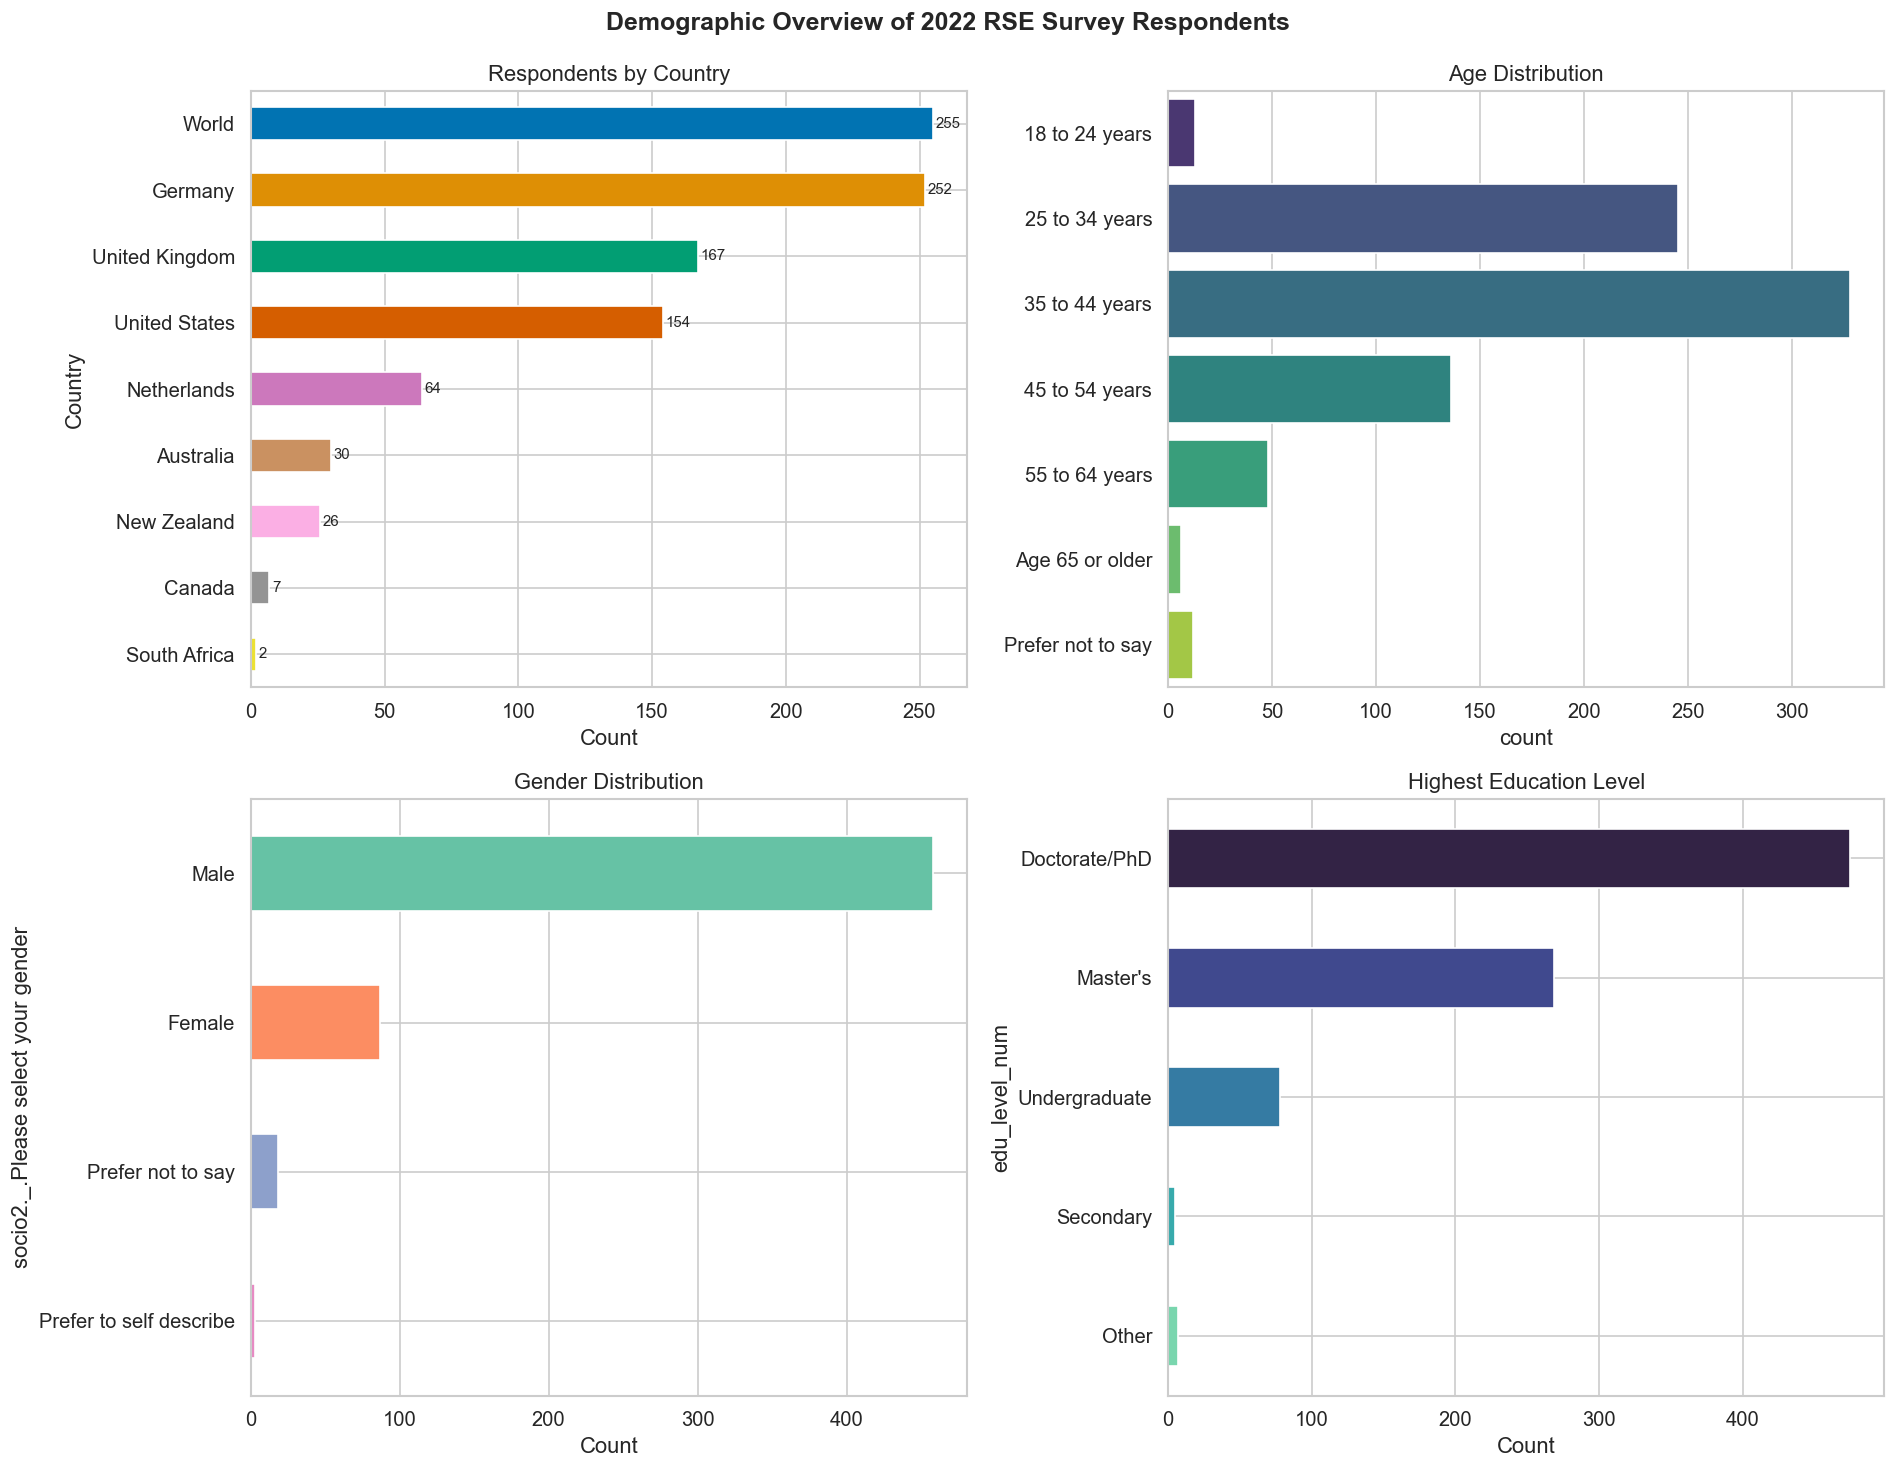

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- 5a. Country distribution ---
ax = axes[0, 0]
country_counts = df["Country"].value_counts()
country_counts.plot.barh(ax=ax, color=sns.color_palette("colorblind", len(country_counts)))
ax.set_title("Respondents by Country")
ax.set_xlabel("Count")
ax.invert_yaxis()
for i, v in enumerate(country_counts.values):
    ax.text(v + 1, i, str(v), va="center", fontsize=9)

# --- 5b. Age distribution ---
ax = axes[0, 1]
if col.get("age") and col["age"] in df.columns:
    age_order = sorted(df[col["age"]].dropna().unique(), key=lambda x: str(x))
    sns.countplot(y=df[col["age"]], order=age_order, ax=ax, palette="viridis")
    ax.set_title("Age Distribution")
    ax.set_ylabel("")
else:
    ax.text(0.5, 0.5, "Age column not found", transform=ax.transAxes, ha="center")

# --- 5c. Gender distribution ---
ax = axes[1, 0]
gender_col_name = col.get("gender")
if gender_col_name and gender_col_name in df.columns:
    gender_counts = df[gender_col_name].value_counts().head(6)
    gender_counts.plot.barh(ax=ax, color=sns.color_palette("Set2", len(gender_counts)))
    ax.set_title("Gender Distribution")
    ax.set_xlabel("Count")
    ax.invert_yaxis()
else:
    ax.text(0.5, 0.5, "Gender column not found", transform=ax.transAxes, ha="center")

# --- 5d. Education level ---
ax = axes[1, 1]
# Use the normalised ordinal education level for a cleaner chart
if "edu_level_num" in df.columns:
    edu_label_map = {6: "Doctorate/PhD", 5: "Master's", 4: "Undergraduate", 3: "Secondary", 2: "GSE", 1: "Other"}
    edu_series = df["edu_level_num"].map(edu_label_map).dropna()
    edu_order = ["Doctorate/PhD", "Master's", "Undergraduate", "Secondary", "GSE", "Other"]
    edu_order = [e for e in edu_order if e in edu_series.values]
    edu_counts = edu_series.value_counts().reindex(edu_order).dropna()
    edu_counts.plot.barh(ax=ax, color=sns.color_palette("mako", len(edu_counts)))
    ax.set_title("Highest Education Level")
    ax.set_xlabel("Count")
    ax.invert_yaxis()
else:
    ax.text(0.5, 0.5, "Education column not found", transform=ax.transAxes, ha="center")

plt.tight_layout()
plt.suptitle("Demographic Overview of 2022 RSE Survey Respondents", y=1.02, fontsize=15, fontweight="bold")
plt.show()

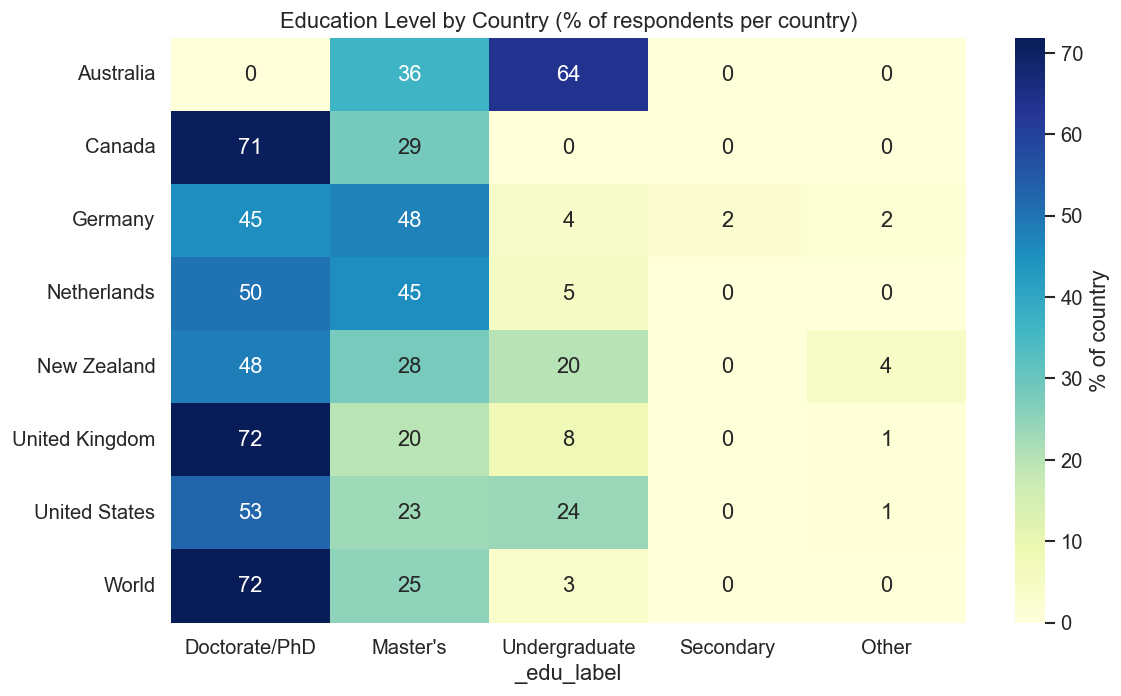

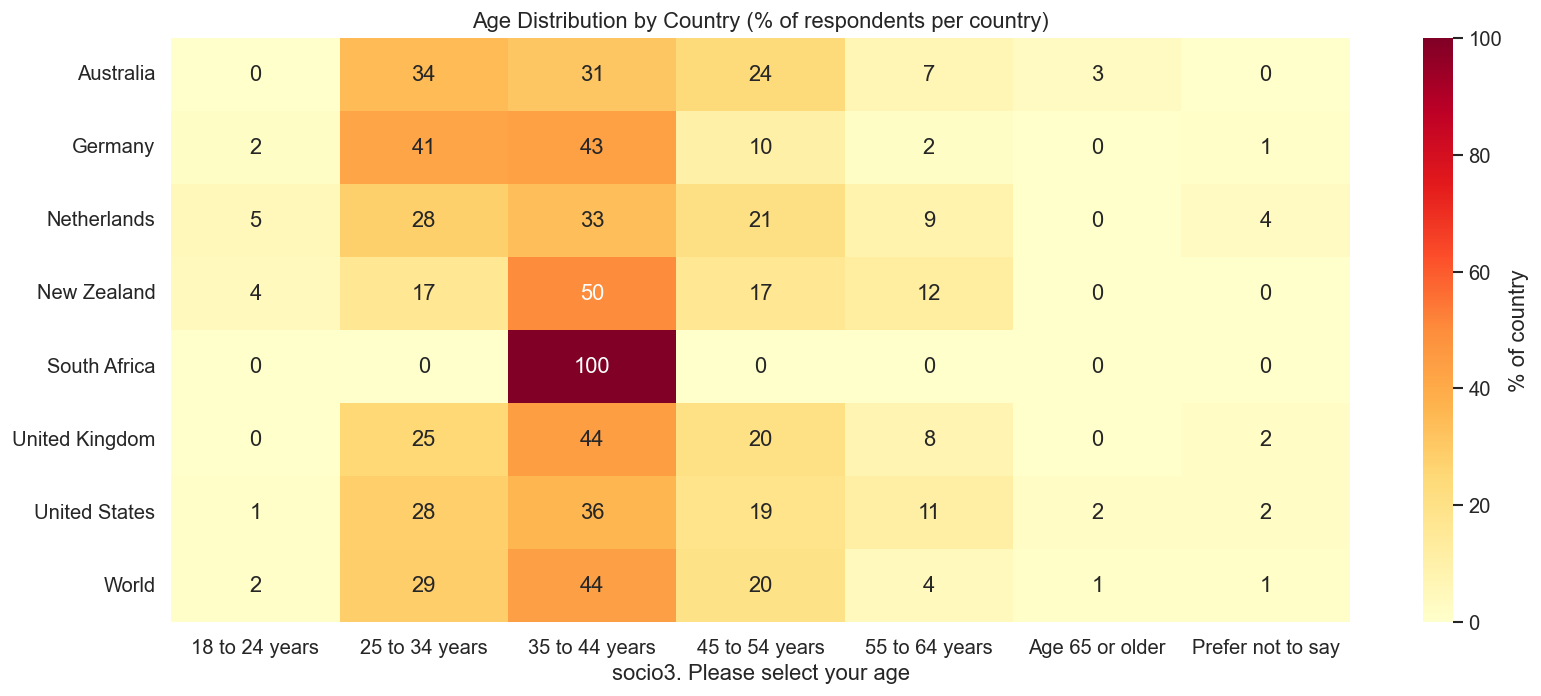

In [25]:
# --- 5e. Cross-country education heatmap ---
# Use the normalised ordinal education level for a clean cross-country comparison
if "edu_level_num" in df.columns:
    edu_label_map = {6: "Doctorate/PhD", 5: "Master's", 4: "Undergraduate", 3: "Secondary", 2: "GSE", 1: "Other"}
    df["_edu_label"] = df["edu_level_num"].map(edu_label_map)
    ct = pd.crosstab(df["Country"], df["_edu_label"], normalize="index") * 100
    # Reorder columns
    col_order = [c for c in ["Doctorate/PhD", "Master's", "Undergraduate", "Secondary", "Other"] if c in ct.columns]
    ct = ct[col_order]
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(ct, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "% of country"})
    ax.set_title("Education Level by Country (% of respondents per country)")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()
    df.drop(columns=["_edu_label"], inplace=True)

# --- 5f. Cross-country age heatmap ---
if col.get("age"):
    ct_age = pd.crosstab(df["Country"], df[col["age"]], normalize="index") * 100
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(ct_age, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax, cbar_kws={"label": "% of country"})
    ax.set_title("Age Distribution by Country (% of respondents per country)")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

## 6. Career Trajectory Analysis: Pathways into RSE

**Hypothesis:** RSEs come from diverse disciplinary backgrounds, but certain pathways (e.g., Physics → RSE, Computer Science → RSE) are associated with different satisfaction levels and tool preferences. We map discipline-of-degree to current RSE role to identify the most common career flows and test whether "native" CS graduates differ from "converted" domain scientists.

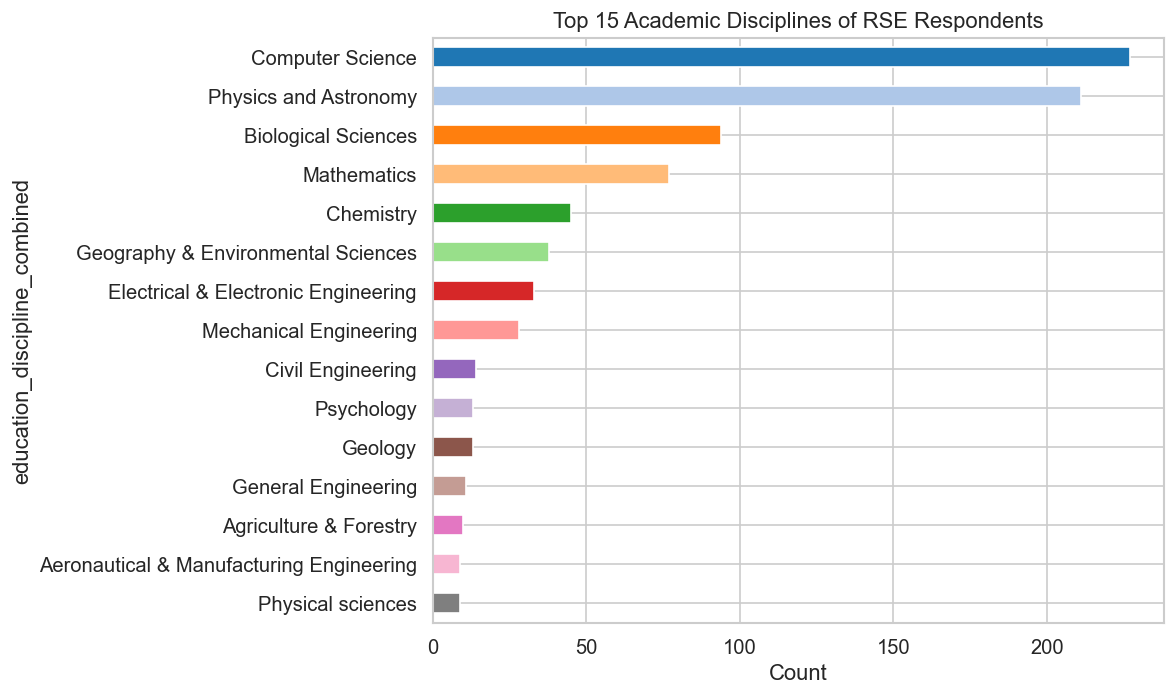

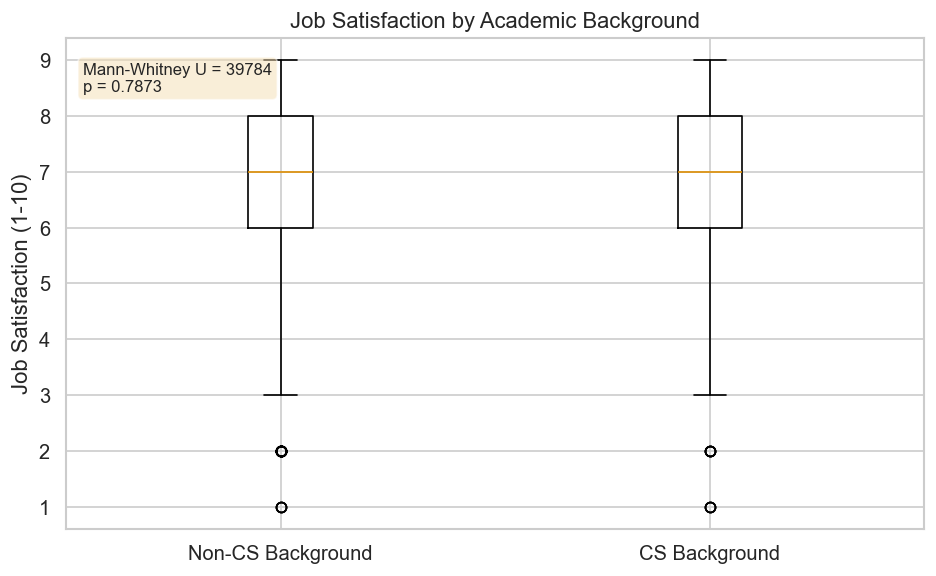

CS background: mean satisfaction = 6.64 (n=154)
Non-CS background: mean satisfaction = 6.71 (n=524)


In [26]:
# --- 6a. Top disciplines feeding into RSE ---
if col.get("education_discipline"):
    disc = df[col["education_discipline"]].dropna()
    disc_counts = disc.value_counts().head(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    disc_counts.plot.barh(ax=ax, color=sns.color_palette("tab20", len(disc_counts)))
    ax.set_title("Top 15 Academic Disciplines of RSE Respondents")
    ax.set_xlabel("Count")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    # --- 6b. CS vs Non-CS background: satisfaction comparison ---
    df["is_cs_background"] = df[col["education_discipline"]].str.lower().str.contains(
        "computer", na=False
    )

    if "satis_position_num" in df.columns:
        fig, ax = plt.subplots(figsize=(8, 5))
        groups = df.groupby("is_cs_background")["satis_position_num"].apply(list)
        cs_satis = df.loc[df["is_cs_background"], "satis_position_num"].dropna()
        non_cs_satis = df.loc[~df["is_cs_background"], "satis_position_num"].dropna()

        ax.boxplot([non_cs_satis, cs_satis], labels=["Non-CS Background", "CS Background"])
        ax.set_ylabel("Job Satisfaction (1-10)")
        ax.set_title("Job Satisfaction by Academic Background")

        # Mann-Whitney U test
        stat, pval = stats.mannwhitneyu(cs_satis, non_cs_satis, alternative="two-sided")
        ax.annotate(f"Mann-Whitney U = {stat:.0f}\np = {pval:.4f}",
                    xy=(0.02, 0.95), xycoords="axes fraction", va="top",
                    fontsize=10, bbox=dict(boxstyle="round", fc="wheat", alpha=0.5))
        plt.tight_layout()
        plt.show()

        print(f"CS background: mean satisfaction = {cs_satis.mean():.2f} (n={len(cs_satis)})")
        print(f"Non-CS background: mean satisfaction = {non_cs_satis.mean():.2f} (n={len(non_cs_satis)})")
else:
    print("Education discipline column not found")

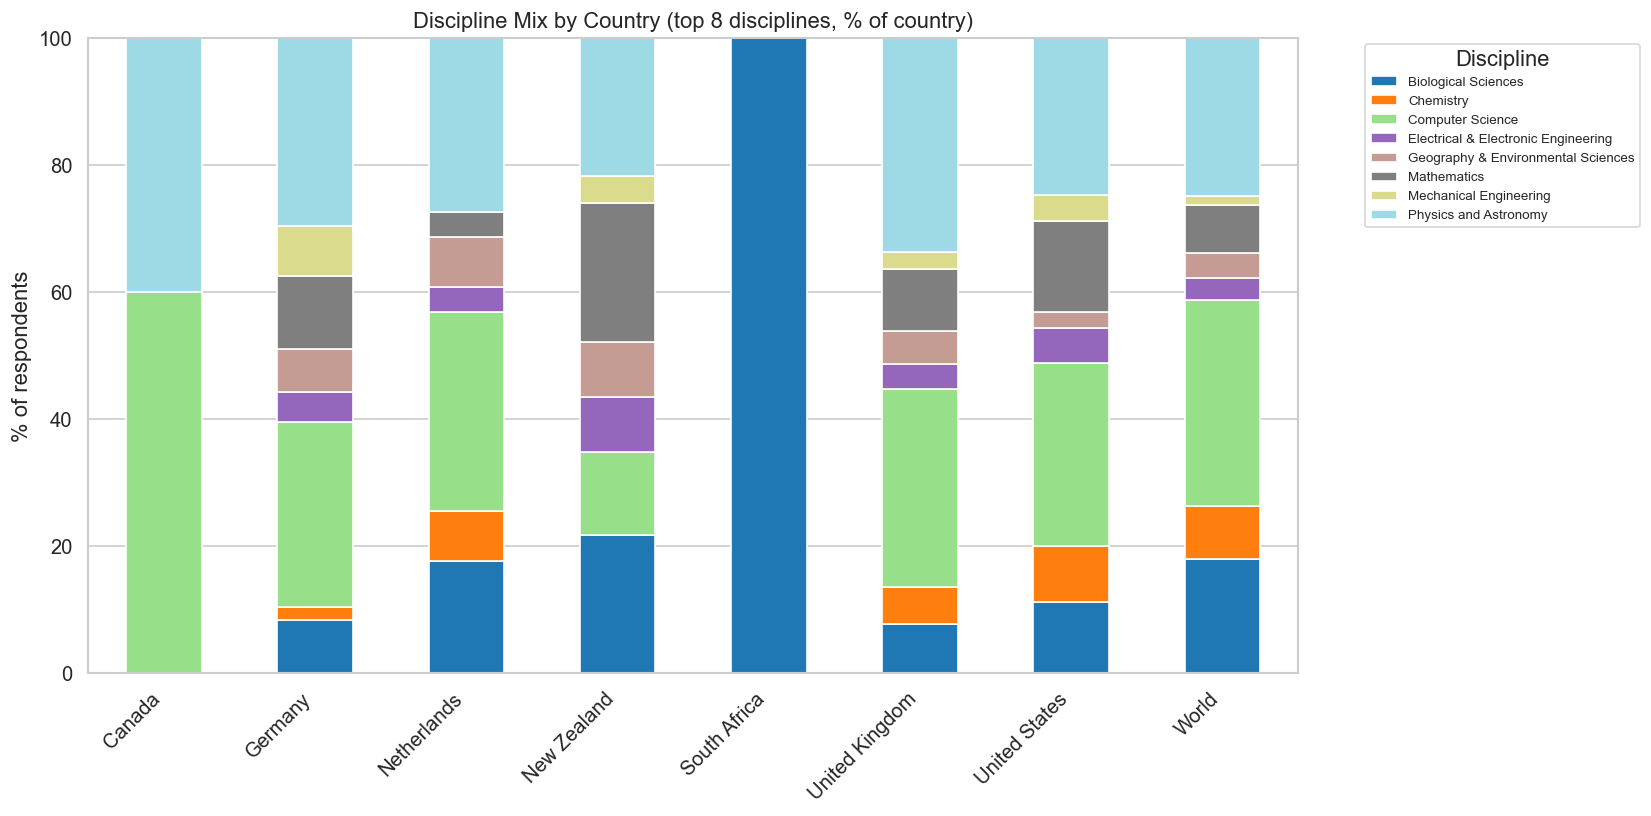

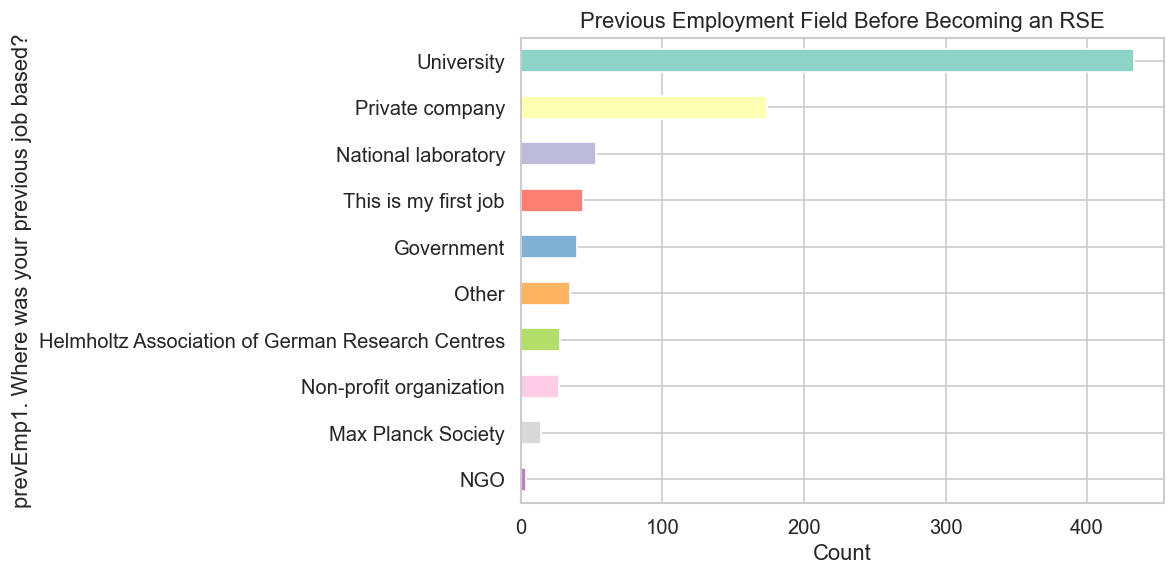

In [27]:
# --- 6c. Discipline → Country flow (top disciplines per country) ---
if col.get("education_discipline"):
    # Cross-tab of discipline by country
    top_discs = df[col["education_discipline"]].value_counts().head(8).index
    df_flow = df[df[col["education_discipline"]].isin(top_discs)].copy()

    ct = pd.crosstab(df_flow["Country"], df_flow[col["education_discipline"]], normalize="index") * 100

    fig, ax = plt.subplots(figsize=(14, 7))
    ct.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
    ax.set_title("Discipline Mix by Country (top 8 disciplines, % of country)")
    ax.set_ylabel("% of respondents")
    ax.set_xlabel("")
    ax.legend(title="Discipline", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # --- 6d. Previous employment sector ---
    if col.get("prev_emp_field"):
        prev = df[col["prev_emp_field"]].dropna().value_counts().head(10)
        fig, ax = plt.subplots(figsize=(10, 5))
        prev.plot.barh(ax=ax, color=sns.color_palette("Set3", len(prev)))
        ax.set_title("Previous Employment Field Before Becoming an RSE")
        ax.set_xlabel("Count")
        ax.invert_yaxis()
        plt.tight_layout()
        plt.show()

## 7. Job Satisfaction vs. Recognition and Funding Security

**Hypothesis:** Recognition by supervisors and peers is a stronger predictor of job satisfaction than contract type or salary level. We test this using correlation analysis and grouped comparisons.

The existing survey analysis reports satisfaction by country but does not deeply explore the *drivers* of satisfaction. Here we look at the interplay between recognition, contract permanence, and satisfaction.

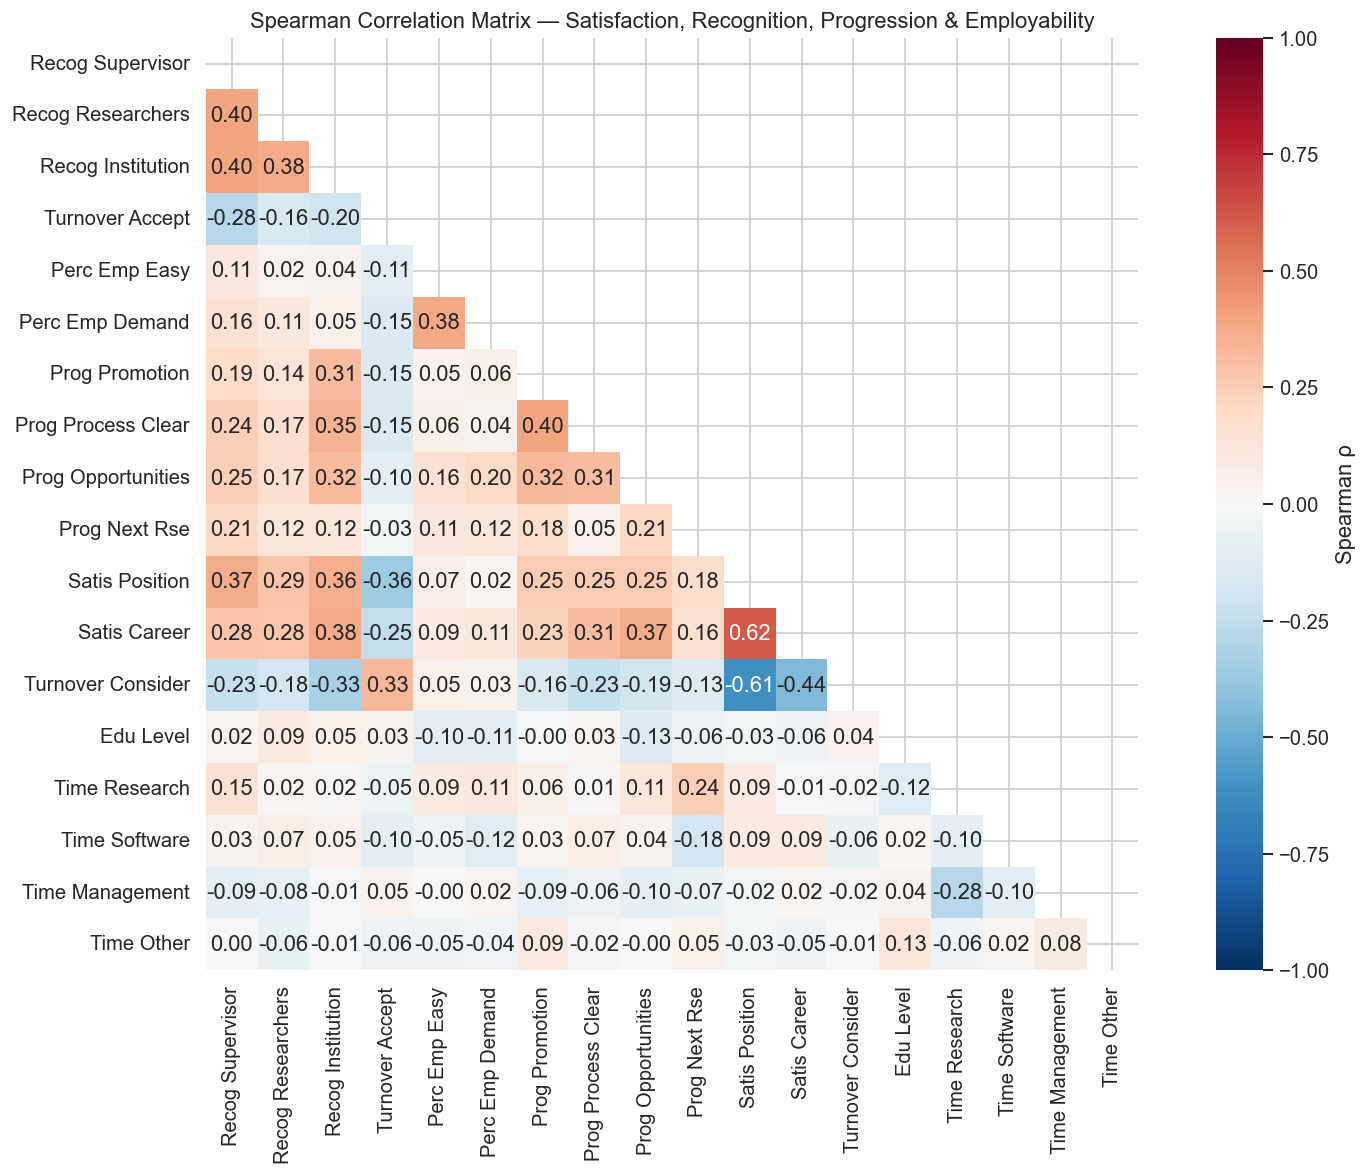

Strongest correlates of Job Satisfaction (position):
  Satis Career                         ρ = +0.616
  Turnover Consider                    ρ = -0.610
  Recog Supervisor                     ρ = +0.372
  Recog Institution                    ρ = +0.363
  Turnover Accept                      ρ = -0.362
  Recog Researchers                    ρ = +0.288


In [28]:
# --- 7a. Correlation matrix: satisfaction, recognition, progression, employability ---
numeric_cols_for_corr = [c for c in df.columns if c.endswith("_num") and df[c].notna().sum() > 50]

if len(numeric_cols_for_corr) >= 3:
    # Build a shorter label map for readability
    short_labels = {}
    for c in numeric_cols_for_corr:
        short = c.replace("_num", "").replace("_", " ").title()
        short_labels[c] = short[:30]

    corr_df = df[numeric_cols_for_corr].rename(columns=short_labels)
    corr_matrix = corr_df.corr(method="spearman")

    fig, ax = plt.subplots(figsize=(14, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
                center=0, vmin=-1, vmax=1, ax=ax, square=True,
                cbar_kws={"label": "Spearman ρ"})
    ax.set_title("Spearman Correlation Matrix — Satisfaction, Recognition, Progression & Employability")
    plt.tight_layout()
    plt.show()

    # Identify strongest correlates of satisfaction
    if "Satis Position" in corr_matrix.columns:
        satis_corrs = corr_matrix["Satis Position"].drop("Satis Position").sort_values(key=abs, ascending=False)
        print("Strongest correlates of Job Satisfaction (position):")
        for name, rho in satis_corrs.head(6).items():
            print(f"  {name:35s}  ρ = {rho:+.3f}")
else:
    print(f"Only {len(numeric_cols_for_corr)} numeric columns available — skipping correlation")

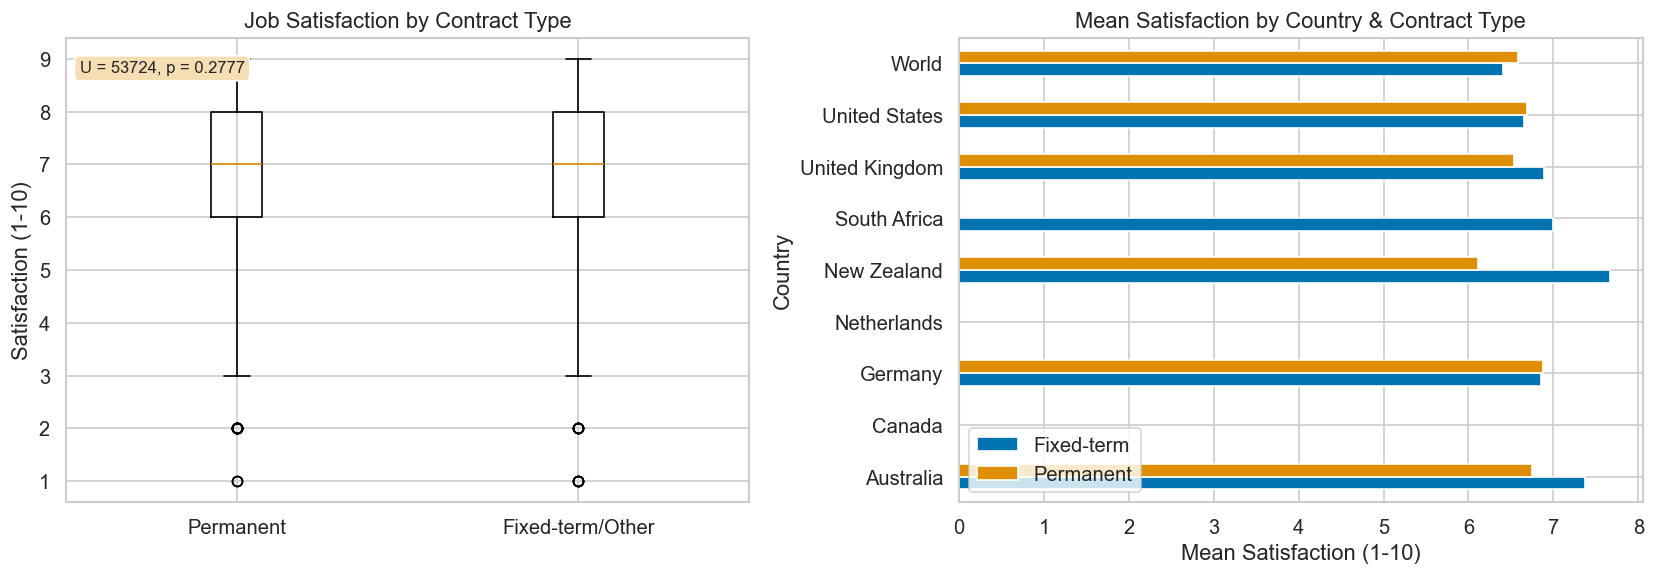

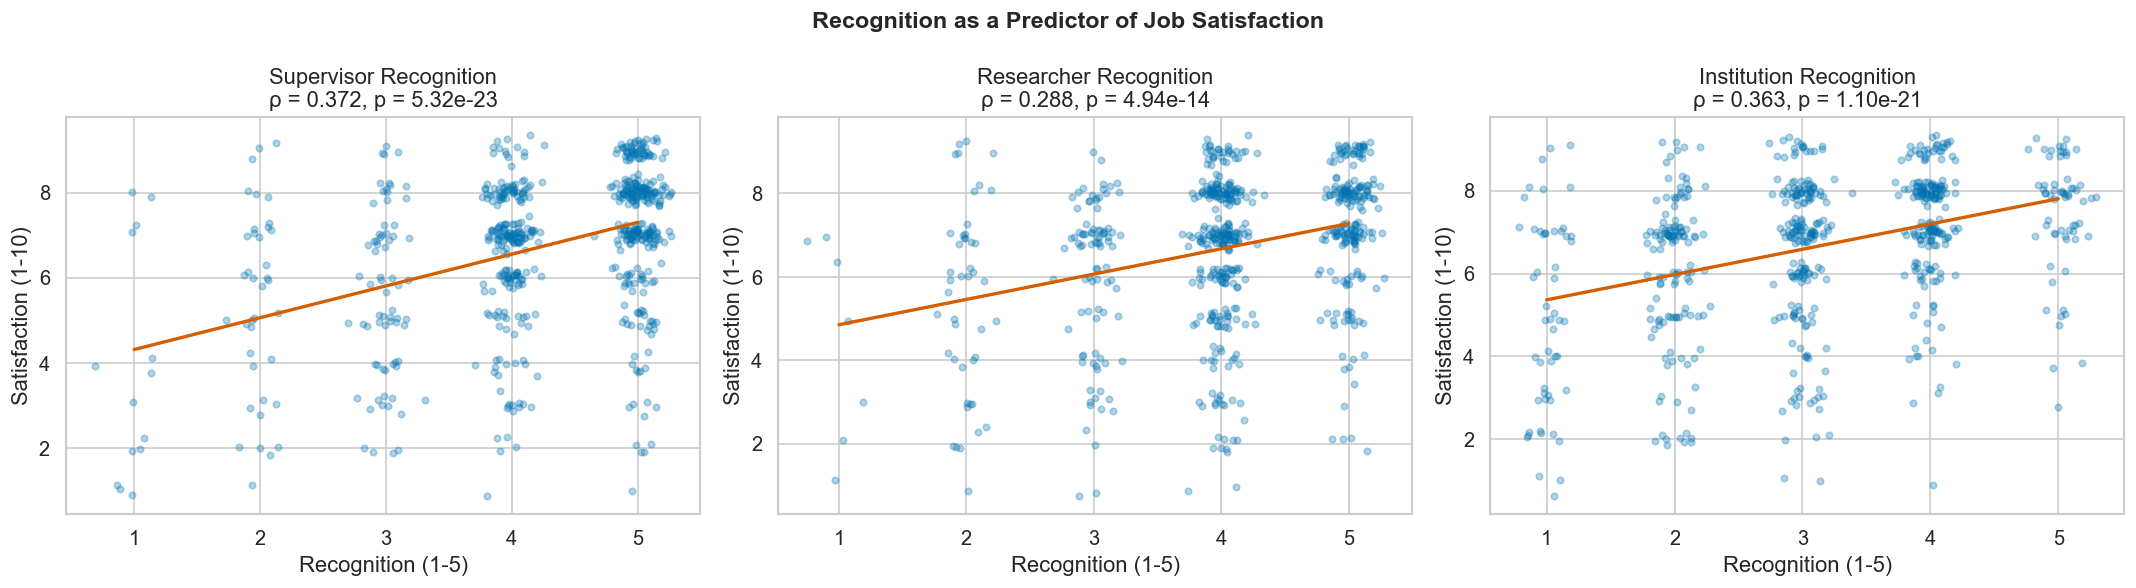

In [29]:
# --- 7b. Satisfaction by contract type (permanent vs fixed-term) ---
if "is_permanent" in df.columns and "satis_position_num" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Box plot
    ax = axes[0]
    perm_satis = df.loc[df["is_permanent"] == True, "satis_position_num"].dropna()
    fixed_satis = df.loc[df["is_permanent"] == False, "satis_position_num"].dropna()
    ax.boxplot([perm_satis, fixed_satis], labels=["Permanent", "Fixed-term/Other"])
    ax.set_ylabel("Satisfaction (1-10)")
    ax.set_title("Job Satisfaction by Contract Type")
    stat, pval = stats.mannwhitneyu(perm_satis, fixed_satis, alternative="two-sided")
    ax.annotate(f"U = {stat:.0f}, p = {pval:.4f}", xy=(0.02, 0.95),
                xycoords="axes fraction", va="top", fontsize=10,
                bbox=dict(boxstyle="round", fc="wheat"))

    # Satisfaction by country and contract type
    ax = axes[1]
    if "is_permanent" in df.columns:
        grp = df.groupby(["Country", "is_permanent"])["satis_position_num"].mean().unstack()
        grp.columns = ["Fixed-term", "Permanent"]
        grp.plot(kind="barh", ax=ax)
        ax.set_title("Mean Satisfaction by Country & Contract Type")
        ax.set_xlabel("Mean Satisfaction (1-10)")

    plt.tight_layout()
    plt.show()

# --- 7c. Recognition vs satisfaction scatter ---
if "recog_supervisor_num" in df.columns and "satis_position_num" in df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for i, (rcol, title) in enumerate([
        ("recog_supervisor_num", "Supervisor Recognition"),
        ("recog_researchers_num", "Researcher Recognition"),
        ("recog_institution_num", "Institution Recognition"),
    ]):
        if rcol in df.columns:
            ax = axes[i]
            subset = df[[rcol, "satis_position_num"]].dropna()
            # Jitter for visibility
            jittered_x = subset[rcol] + np.random.normal(0, 0.1, len(subset))
            jittered_y = subset["satis_position_num"] + np.random.normal(0, 0.15, len(subset))
            ax.scatter(jittered_x, jittered_y, alpha=0.3, s=15)
            # Trendline
            z = np.polyfit(subset[rcol], subset["satis_position_num"], 1)
            p = np.poly1d(z)
            x_range = np.linspace(subset[rcol].min(), subset[rcol].max(), 100)
            ax.plot(x_range, p(x_range), "r-", linewidth=2)
            rho, pv = stats.spearmanr(subset[rcol], subset["satis_position_num"])
            ax.set_title(f"{title}\nρ = {rho:.3f}, p = {pv:.2e}")
            ax.set_xlabel("Recognition (1-5)")
            ax.set_ylabel("Satisfaction (1-10)")

    plt.suptitle("Recognition as a Predictor of Job Satisfaction", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 8. Skills Gap Analysis: Tools Used vs. Tools Wanted

**Hypothesis:** Mid-career RSEs have the largest gap between tools currently used and tools they want to learn, suggesting unmet professional development needs. We compare programming language usage across countries and career stages.

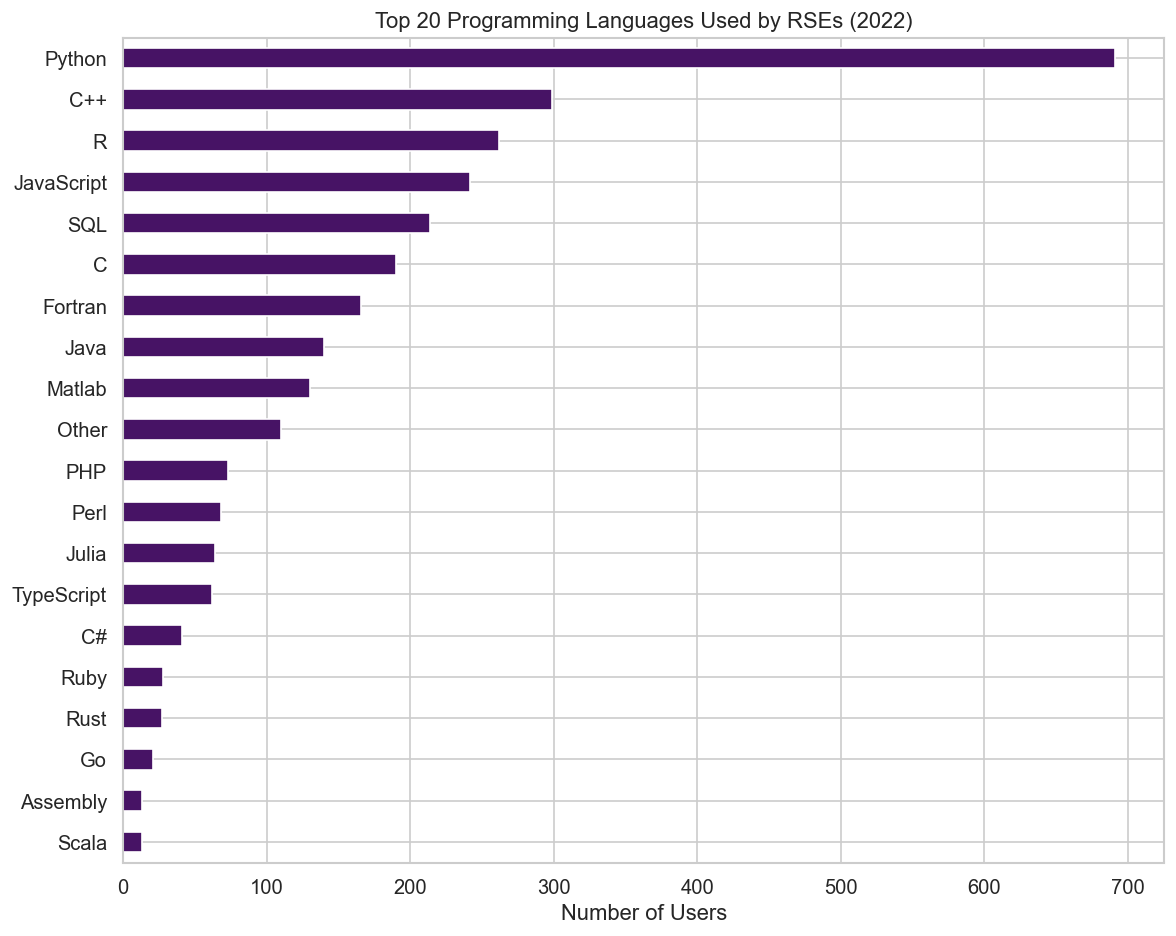

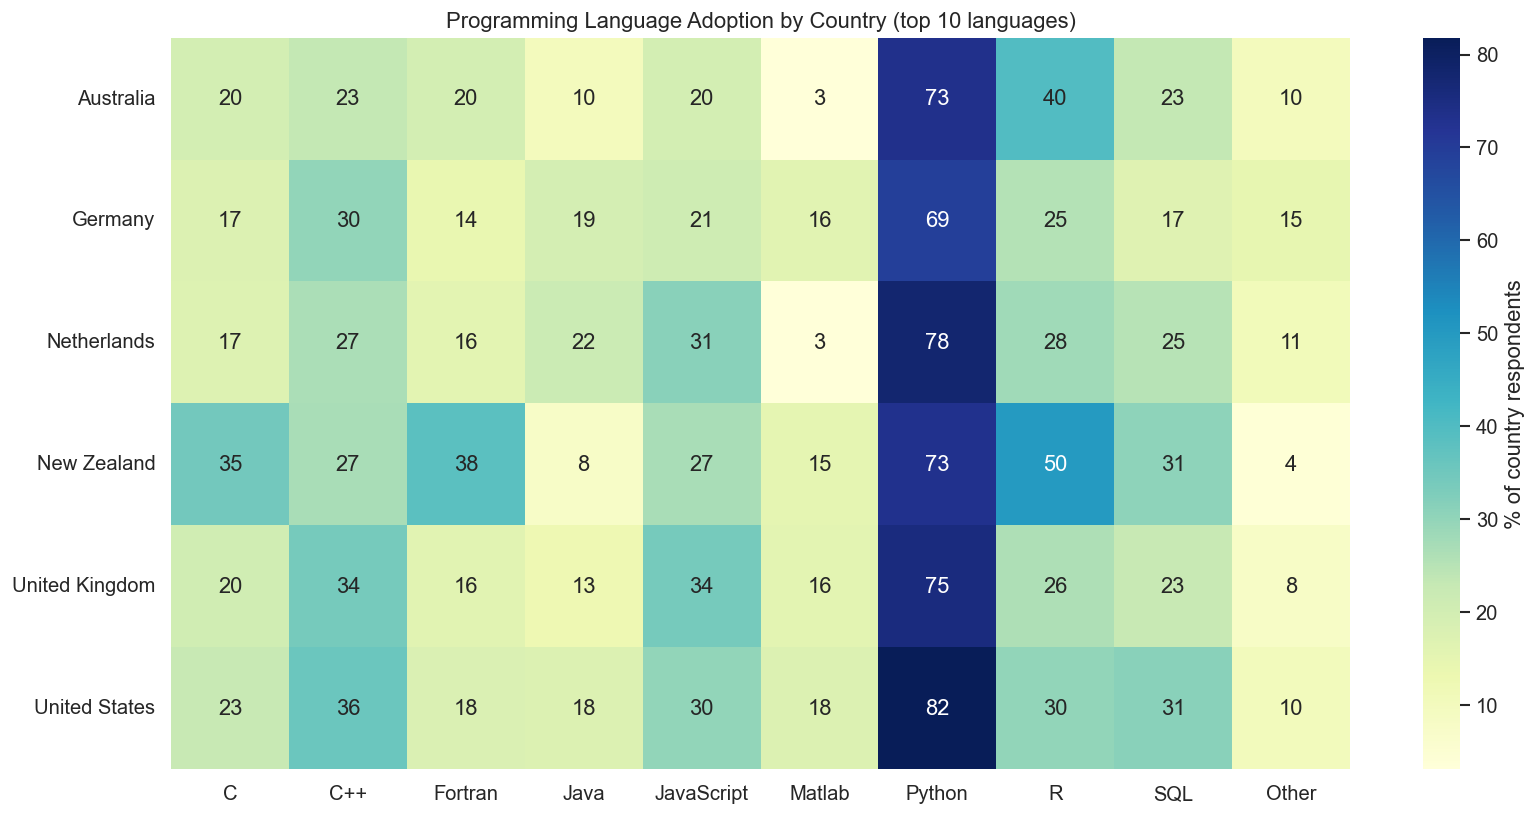

In [30]:
# --- 8a. Programming language usage (multi-select Yes/No columns) ---
prog_lang_cols = col.get("prog_langs", [])

if prog_lang_cols:
    # Extract language names from column headers and count "Yes" responses
    lang_usage = {}
    for c in prog_lang_cols:
        lang_name = c.split("[")[-1].rstrip("]") if "[" in c else c.split(".")[-1].strip()
        # Columns contain "Yes"/"No" strings
        usage_count = (df[c].astype(str).str.strip().str.lower() == "yes").sum()
        lang_usage[lang_name] = usage_count

    lang_df = pd.DataFrame.from_dict(lang_usage, orient="index", columns=["Users"]).sort_values("Users", ascending=False)

    # Plot top 20 languages
    fig, ax = plt.subplots(figsize=(10, 8))
    lang_df.head(20).plot.barh(ax=ax, legend=False, color=sns.color_palette("viridis", 20))
    ax.set_title("Top 20 Programming Languages Used by RSEs (2022)")
    ax.set_xlabel("Number of Users")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    # --- 8b. Language usage by country ---
    top_langs = lang_df.head(10).index.tolist()
    top_lang_cols = [c for c in prog_lang_cols if any(l in c for l in top_langs)]

    if top_lang_cols:
        country_lang = {}
        for country in PARTICIPATING_COUNTRIES:
            mask = df["Country"] == country
            n_country = mask.sum()
            if n_country < 10:
                continue
            rates = {}
            for c in top_lang_cols:
                lang_name = c.split("[")[-1].rstrip("]") if "[" in c else c.split(".")[-1].strip()
                if lang_name in top_langs:
                    count = (df.loc[mask, c].astype(str).str.strip().str.lower() == "yes").sum()
                    rates[lang_name] = count / n_country * 100
            country_lang[country] = rates

        if country_lang:
            cl_df = pd.DataFrame(country_lang).T
            fig, ax = plt.subplots(figsize=(14, 7))
            sns.heatmap(cl_df, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax,
                        cbar_kws={"label": "% of country respondents"})
            ax.set_title("Programming Language Adoption by Country (top 10 languages)")
            ax.set_ylabel("")
            plt.tight_layout()
            plt.show()
else:
    print("No programming language columns found — looking for alternatives...")
    tool_cols = [c for c in df.columns if c.lower().startswith("tool")]
    print(f"Found {len(tool_cols)} tool-related columns")
    for c in tool_cols[:10]:
        print(f"  {c}")

## 9. Burnout Indicators: Working Hours, Contract Type, and Satisfaction

**Hypothesis:** RSEs on short-term contracts in countries with weaker RSE group infrastructure show significantly higher burnout risk. We construct a composite burnout risk score from: high turnover intention, low satisfaction, non-permanent contracts, and low recognition.

Burnout risk score computed from 4 components:
  - low_satisfaction
  - high_turnover
  - contract_insecurity
  - low_recognition

Burnout risk: mean = 0.384, median = 0.354, std = 0.299


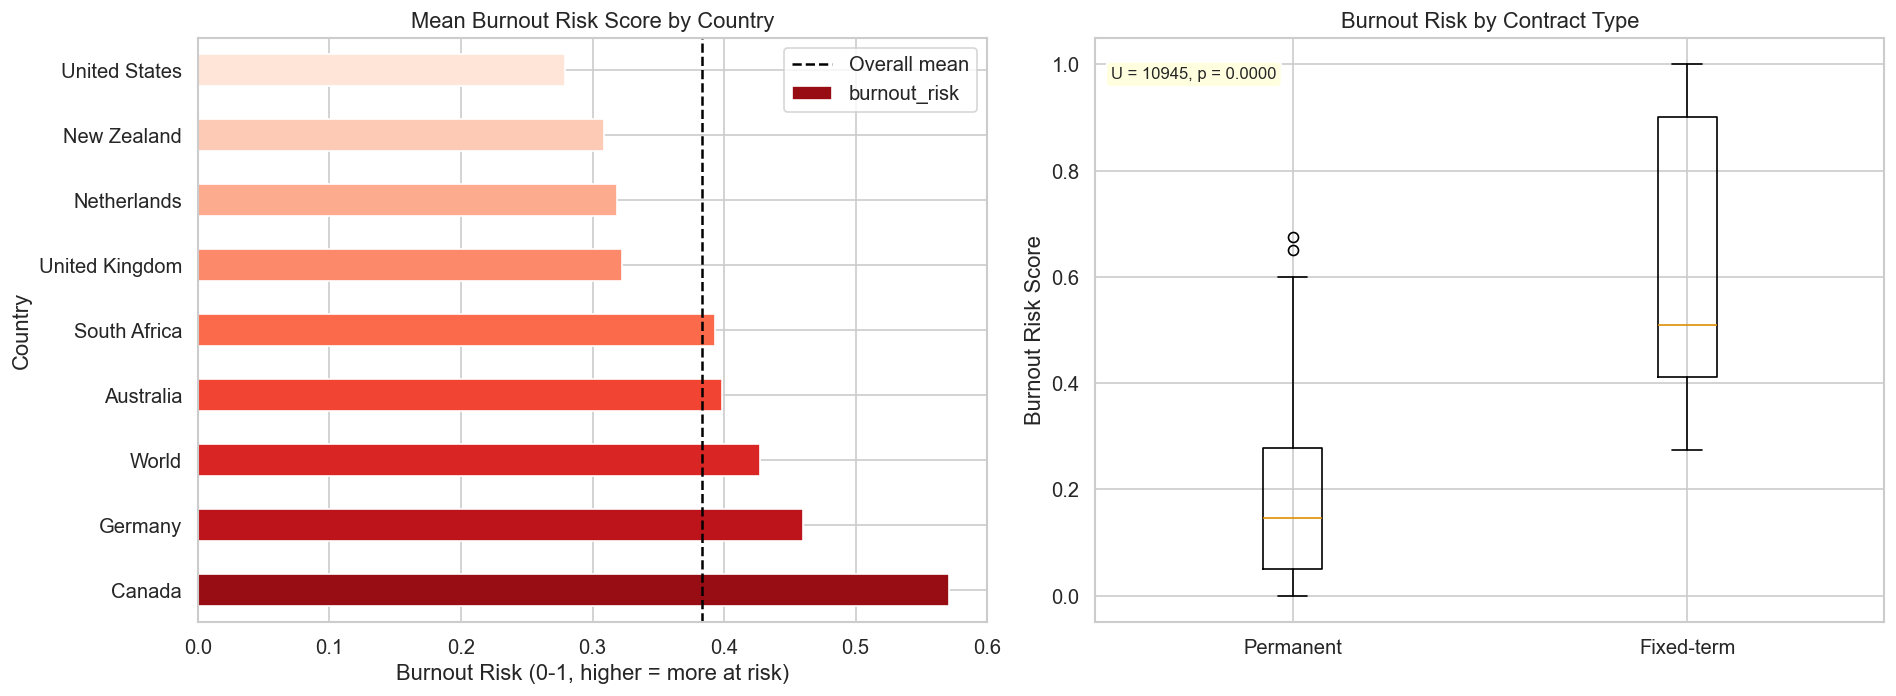

In [31]:
# --- 9a. Construct burnout risk indicator ---
# Components (each normalised to 0-1 where 1 = higher risk):
# - Low satisfaction (invert: 1 - satis/10)
# - High turnover consideration (normalised)
# - Non-permanent contract (binary)
# - Low supervisor recognition (invert: 1 - recog/5)

burnout_components = {}

if "satis_position_num" in df.columns:
    burnout_components["low_satisfaction"] = 1 - (df["satis_position_num"] / 10)

if "turnover_consider_num" in df.columns:
    tc = df["turnover_consider_num"]
    burnout_components["high_turnover"] = (tc - tc.min()) / (tc.max() - tc.min())

if "is_permanent" in df.columns:
    burnout_components["contract_insecurity"] = (~df["is_permanent"]).astype(float)

if "recog_supervisor_num" in df.columns:
    burnout_components["low_recognition"] = 1 - (df["recog_supervisor_num"] / 5)

if burnout_components:
    burnout_df = pd.DataFrame(burnout_components)
    df["burnout_risk"] = burnout_df.mean(axis=1)  # Average of available components

    print(f"Burnout risk score computed from {len(burnout_components)} components:")
    for k in burnout_components:
        print(f"  - {k}")
    print(f"\nBurnout risk: mean = {df['burnout_risk'].mean():.3f}, "
          f"median = {df['burnout_risk'].median():.3f}, "
          f"std = {df['burnout_risk'].std():.3f}")

    # --- 9b. Burnout risk by country ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax = axes[0]
    country_burnout = df.groupby("Country")["burnout_risk"].mean().sort_values(ascending=False)
    country_burnout.plot.barh(ax=ax, color=sns.color_palette("Reds_r", len(country_burnout)))
    ax.set_title("Mean Burnout Risk Score by Country")
    ax.set_xlabel("Burnout Risk (0-1, higher = more at risk)")
    ax.axvline(df["burnout_risk"].mean(), color="black", linestyle="--", label="Overall mean")
    ax.legend()

    # --- 9c. Burnout risk by contract type ---
    ax = axes[1]
    if "is_permanent" in df.columns:
        bp_data = [
            df.loc[df["is_permanent"] == True, "burnout_risk"].dropna(),
            df.loc[df["is_permanent"] == False, "burnout_risk"].dropna(),
        ]
        ax.boxplot(bp_data, labels=["Permanent", "Fixed-term"])
        ax.set_ylabel("Burnout Risk Score")
        ax.set_title("Burnout Risk by Contract Type")
        if len(bp_data[0]) > 5 and len(bp_data[1]) > 5:
            stat, pval = stats.mannwhitneyu(bp_data[0], bp_data[1])
            ax.annotate(f"U = {stat:.0f}, p = {pval:.4f}",
                        xy=(0.02, 0.95), xycoords="axes fraction", va="top",
                        fontsize=10, bbox=dict(boxstyle="round", fc="lightyellow"))

    plt.tight_layout()
    plt.show()
else:
    print("Insufficient columns to compute burnout risk")

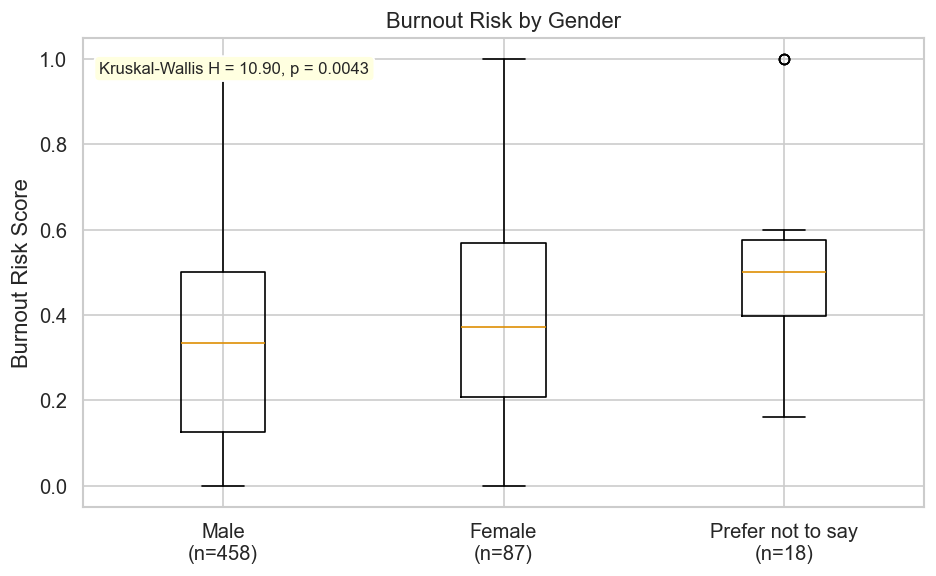

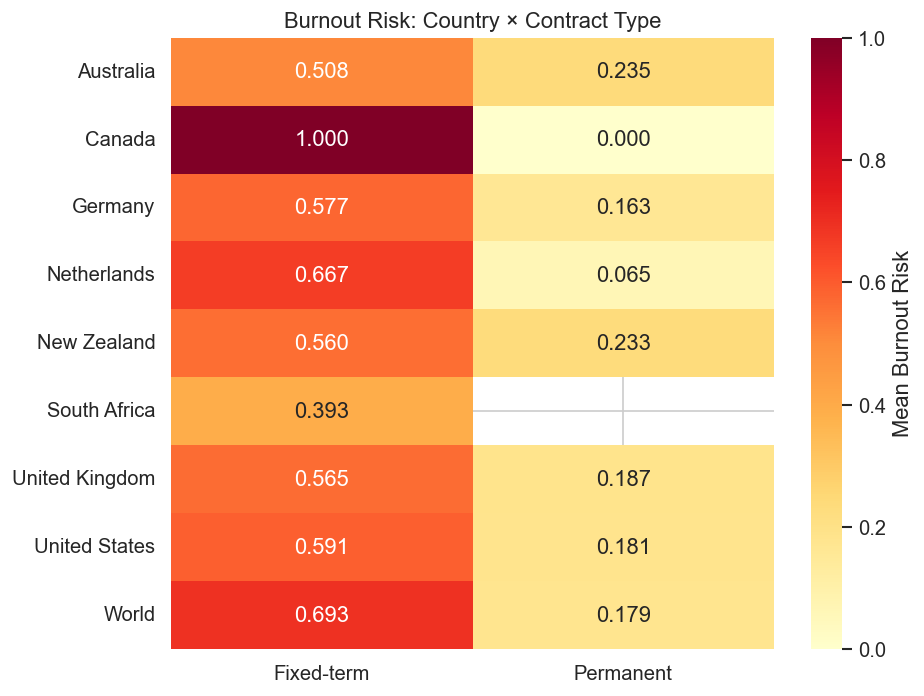

In [32]:
# --- 9d. Burnout risk by gender ---
if "burnout_risk" in df.columns and col.get("gender") and col["gender"] in df.columns:
    gender_col = col["gender"]
    top_genders = df[gender_col].value_counts().head(3).index  # Focus on groups with enough data

    fig, ax = plt.subplots(figsize=(8, 5))
    gender_data = []
    gender_labels = []
    for g in top_genders:
        data = df.loc[df[gender_col] == g, "burnout_risk"].dropna()
        if len(data) >= 10:
            gender_data.append(data)
            gender_labels.append(f"{g}\n(n={len(data)})")

    ax.boxplot(gender_data, labels=gender_labels)
    ax.set_ylabel("Burnout Risk Score")
    ax.set_title("Burnout Risk by Gender")

    # Kruskal-Wallis test across groups
    if len(gender_data) >= 2:
        stat, pval = stats.kruskal(*gender_data)
        ax.annotate(f"Kruskal-Wallis H = {stat:.2f}, p = {pval:.4f}",
                    xy=(0.02, 0.95), xycoords="axes fraction", va="top",
                    fontsize=10, bbox=dict(boxstyle="round", fc="lightyellow"))

    plt.tight_layout()
    plt.show()

# --- 9e. Burnout heatmap: Country × Contract type ---
if "burnout_risk" in df.columns and "is_permanent" in df.columns:
    pivot = df.groupby(["Country", "is_permanent"])["burnout_risk"].mean().unstack()
    pivot.columns = ["Fixed-term", "Permanent"]

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax,
                cbar_kws={"label": "Mean Burnout Risk"})
    ax.set_title("Burnout Risk: Country × Contract Type")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

## 10. Gender and Diversity Analysis Across Role Seniority

**Hypothesis (Leaky Pipeline):** Diversity decreases at senior RSE levels — women and underrepresented groups are proportionally more present in early-career positions but less so in leadership/senior roles. We also test for satisfaction and recognition gaps between demographic groups.

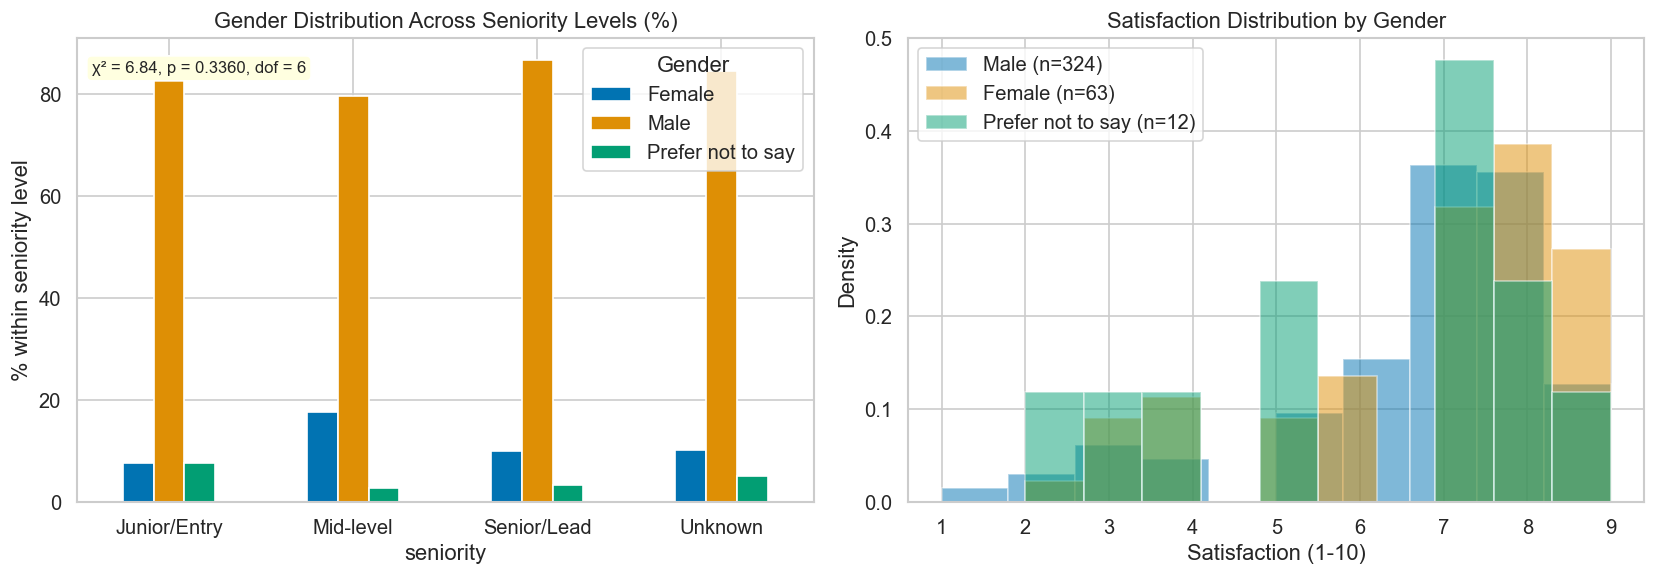


Gender × Seniority counts:
socio2._.Please select your gender  Female  Male  Prefer not to say
seniority                                                          
Junior/Entry                             1    11                  1
Mid-level                               71   320                 11
Senior/Lead                              9    78                  3
Unknown                                  6    49                  3


In [33]:
# --- 10a. Gender distribution across job titles / seniority ---
gender_col = col.get("gender")
job_col = col.get("job_title")

if gender_col and job_col and gender_col in df.columns and job_col in df.columns:
    # Create a simplified seniority proxy from job title
    def classify_seniority(title):
        if pd.isna(title):
            return "Unknown"
        title_l = str(title).lower()
        if any(w in title_l for w in ["senior", "lead", "principal", "head", "director", "manager"]):
            return "Senior/Lead"
        elif any(w in title_l for w in ["junior", "assistant", "entry", "intern", "trainee"]):
            return "Junior/Entry"
        else:
            return "Mid-level"

    df["seniority"] = df[job_col].apply(classify_seniority)

    # Gender × seniority cross-tab
    top_genders = df[gender_col].value_counts().head(3).index
    df_filtered = df[df[gender_col].isin(top_genders)]

    ct = pd.crosstab(df_filtered["seniority"], df_filtered[gender_col], normalize="index") * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ct.plot(kind="bar", ax=ax, rot=0)
    ax.set_title("Gender Distribution Across Seniority Levels (%)")
    ax.set_ylabel("% within seniority level")
    ax.legend(title="Gender")

    # Chi-squared test for independence
    ct_raw = pd.crosstab(df_filtered["seniority"], df_filtered[gender_col])
    chi2, pval, dof, expected = stats.chi2_contingency(ct_raw)

    ax.annotate(f"χ² = {chi2:.2f}, p = {pval:.4f}, dof = {dof}",
                xy=(0.02, 0.95), xycoords="axes fraction", va="top",
                fontsize=10, bbox=dict(boxstyle="round", fc="lightyellow"))

    # 10b. Gender × satisfaction
    ax = axes[1]
    for g in top_genders:
        data = df.loc[df[gender_col] == g, "satis_position_num"].dropna()
        if len(data) >= 10:
            ax.hist(data, bins=10, alpha=0.5, label=f"{g} (n={len(data)})", density=True)
    ax.set_xlabel("Satisfaction (1-10)")
    ax.set_ylabel("Density")
    ax.set_title("Satisfaction Distribution by Gender")
    ax.legend()

    plt.tight_layout()
    plt.show()

    # Print summary
    print("\nGender × Seniority counts:")
    print(ct_raw)
else:
    print("Gender or job title column not found")

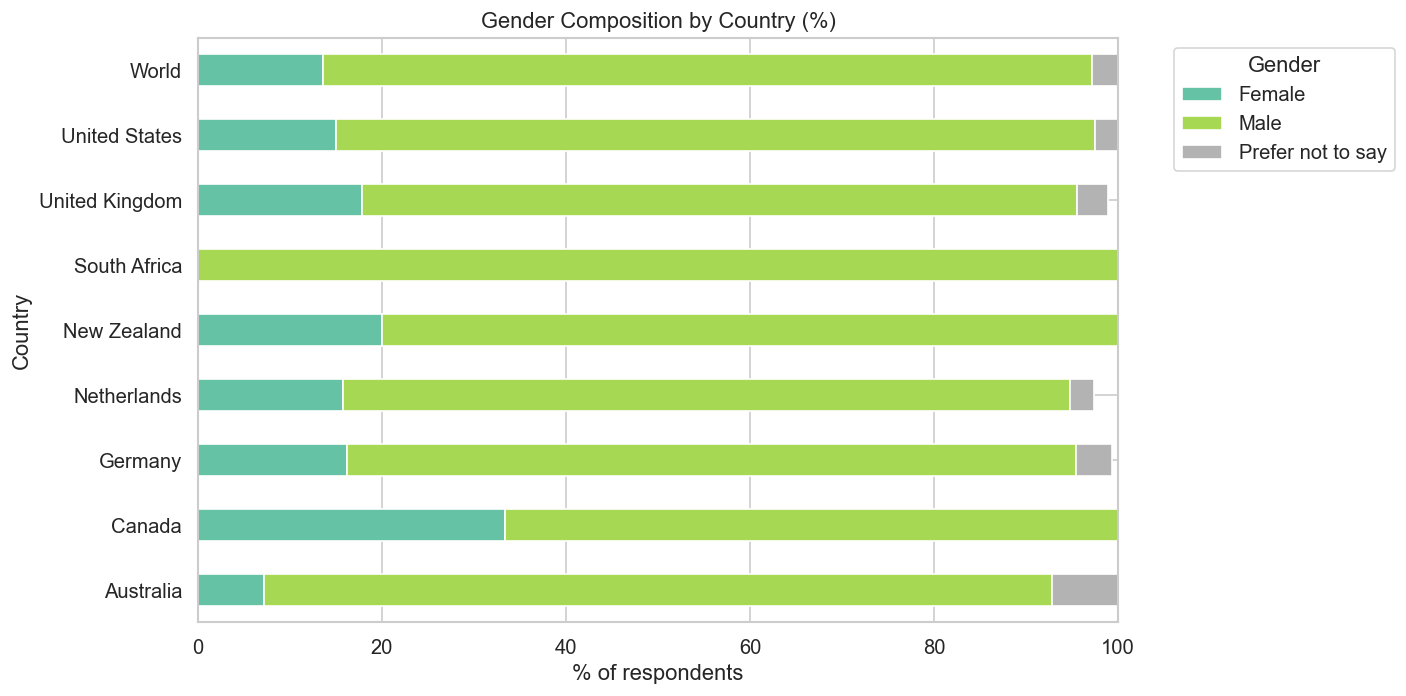

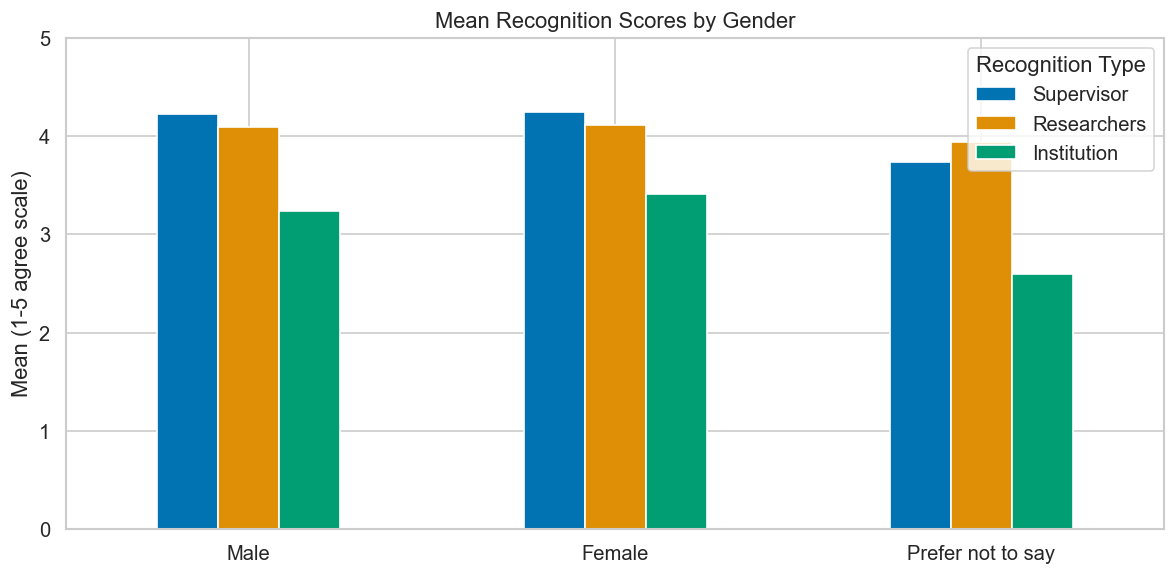

In [34]:
# --- 10c. Diversity by country: gender proportions ---
if gender_col and gender_col in df.columns:
    ct_country = pd.crosstab(df["Country"], df[gender_col], normalize="index") * 100

    fig, ax = plt.subplots(figsize=(12, 6))
    # Keep only main genders for clarity
    main_genders = [g for g in ct_country.columns if ct_country[g].mean() > 2]
    ct_country[main_genders].plot(kind="barh", stacked=True, ax=ax, colormap="Set2")
    ax.set_title("Gender Composition by Country (%)")
    ax.set_xlabel("% of respondents")
    ax.legend(title="Gender", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# --- 10d. Recognition gap by gender ---
if gender_col and "recog_supervisor_num" in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    recog_cols_to_plot = ["recog_supervisor_num", "recog_researchers_num", "recog_institution_num"]
    recog_cols_to_plot = [c for c in recog_cols_to_plot if c in df.columns]

    gap_data = []
    for g in top_genders:
        means = df.loc[df[gender_col] == g, recog_cols_to_plot].mean()
        means.name = g
        gap_data.append(means)

    gap_df = pd.DataFrame(gap_data)
    gap_df.columns = [c.replace("_num", "").replace("recog_", "").replace("_", " ").title() for c in gap_df.columns]
    gap_df.plot(kind="bar", ax=ax, rot=0)
    ax.set_title("Mean Recognition Scores by Gender")
    ax.set_ylabel("Mean (1-5 agree scale)")
    ax.set_ylim(0, 5)
    ax.legend(title="Recognition Type")
    plt.tight_layout()
    plt.show()

## 11. Collaboration Network Patterns: Team Size, Discipline Spread, and Productivity

**Hypothesis:** RSEs who work across more disciplines report higher satisfaction but also higher workload stress. We examine how the breadth of collaboration and time allocation relate to satisfaction and burnout risk.

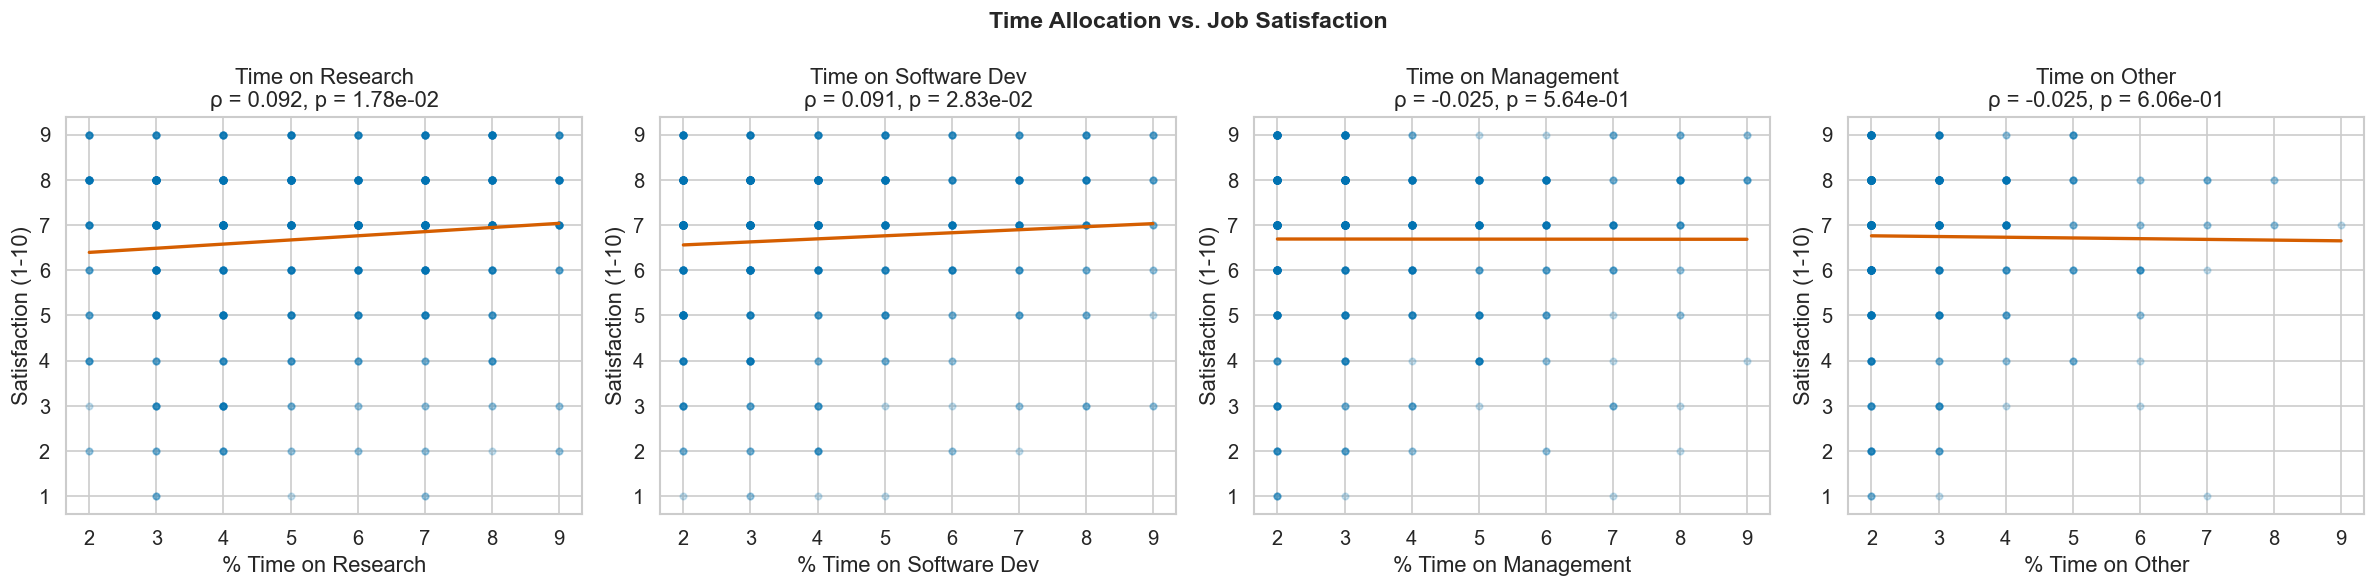

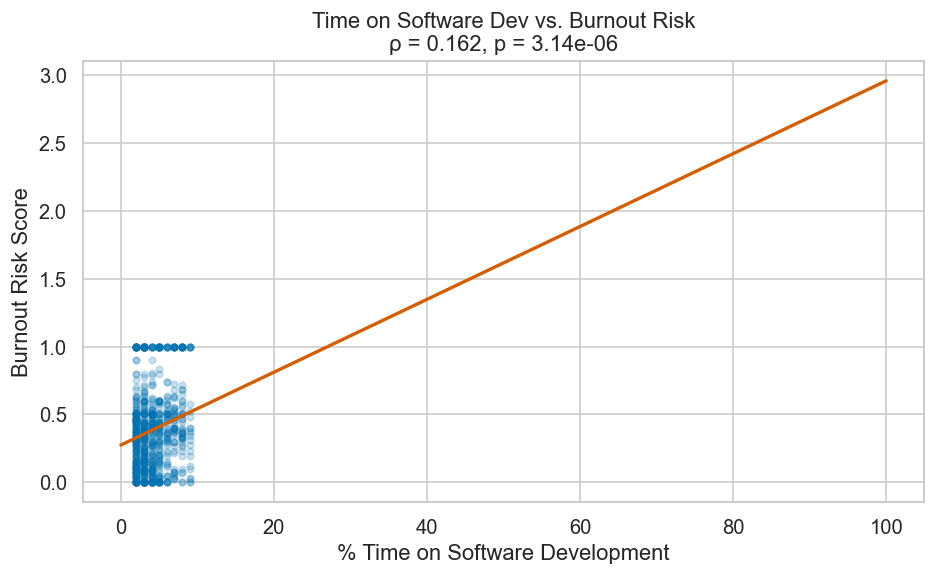

In [35]:
# --- 11a. Time allocation patterns and their relationship to satisfaction ---
time_cols = {
    "Research": "time_research_num",
    "Software Dev": "time_software_num",
    "Management": "time_management_num",
    "Other": "time_other_num",
}
available_time_cols = {k: v for k, v in time_cols.items() if v in df.columns}

if available_time_cols and "satis_position_num" in df.columns:
    fig, axes = plt.subplots(1, len(available_time_cols), figsize=(5 * len(available_time_cols), 5))
    if len(available_time_cols) == 1:
        axes = [axes]

    for i, (label, tcol) in enumerate(available_time_cols.items()):
        ax = axes[i]
        subset = df[[tcol, "satis_position_num"]].dropna()
        if len(subset) > 20:
            ax.scatter(subset[tcol], subset["satis_position_num"], alpha=0.2, s=15)
            # Trendline
            z = np.polyfit(subset[tcol], subset["satis_position_num"], 1)
            p = np.poly1d(z)
            x_range = np.linspace(subset[tcol].min(), subset[tcol].max(), 100)
            ax.plot(x_range, p(x_range), "r-", linewidth=2)
            rho, pv = stats.spearmanr(subset[tcol], subset["satis_position_num"])
            ax.set_title(f"Time on {label}\nρ = {rho:.3f}, p = {pv:.2e}")
            ax.set_xlabel(f"% Time on {label}")
            ax.set_ylabel("Satisfaction (1-10)")

    plt.suptitle("Time Allocation vs. Job Satisfaction", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

# --- 11b. Collaboration breadth ---
collab_col = col.get("collab_researchers")
if collab_col and collab_col in df.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    collab_counts = df[collab_col].value_counts().sort_index()
    collab_counts.plot.bar(ax=ax, color=sns.color_palette("mako", len(collab_counts)))
    ax.set_title("Number of Researchers RSEs Collaborate With")
    ax.set_xlabel(collab_col.split(".")[-1].strip()[:50])
    ax.set_ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# --- 11c. Time on software dev vs. burnout risk ---
if "time_software_num" in df.columns and "burnout_risk" in df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    subset = df[["time_software_num", "burnout_risk"]].dropna()
    ax.scatter(subset["time_software_num"], subset["burnout_risk"], alpha=0.2, s=15)
    z = np.polyfit(subset["time_software_num"], subset["burnout_risk"], 1)
    p = np.poly1d(z)
    x_range = np.linspace(0, 100, 100)
    ax.plot(x_range, p(x_range), "r-", linewidth=2)
    rho, pv = stats.spearmanr(subset["time_software_num"], subset["burnout_risk"])
    ax.set_title(f"Time on Software Dev vs. Burnout Risk\nρ = {rho:.3f}, p = {pv:.2e}")
    ax.set_xlabel("% Time on Software Development")
    ax.set_ylabel("Burnout Risk Score")
    plt.tight_layout()
    plt.show()

## 12. Training and Professional Development: Unmet Needs by Career Stage

**Hypothesis:** Early-career RSEs need software engineering fundamentals while senior RSEs need leadership and project management training. We look at training patterns by seniority and test whether there are significant differences.

Training-related columns found:
  train2. On average, how many times a year do you take part in providing training?
    Values: [2. 3. 0. 1. 6.]
  train3. What training programs are you involved with (comma separated list, e.g., Software
    Values: <StringArray>
[  'institutional training offering', 'VIB Gentle Introduction to Python',
         'local university training',                                 '0',
                              'none']
Length: 5, dtype: str
  org2can. What would you hope to get out of such an organisation (check all that apply)?. [
    Values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str

Good practice columns found: 10


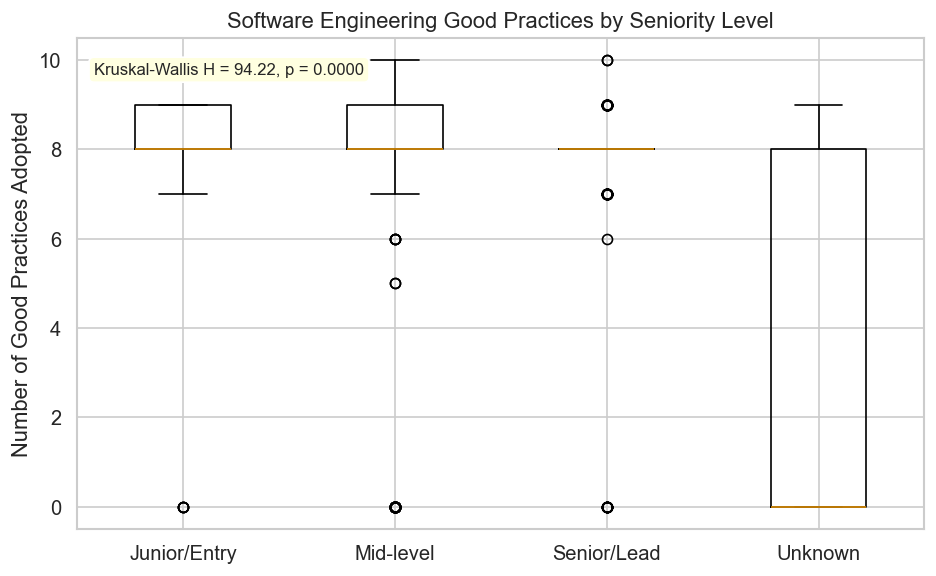

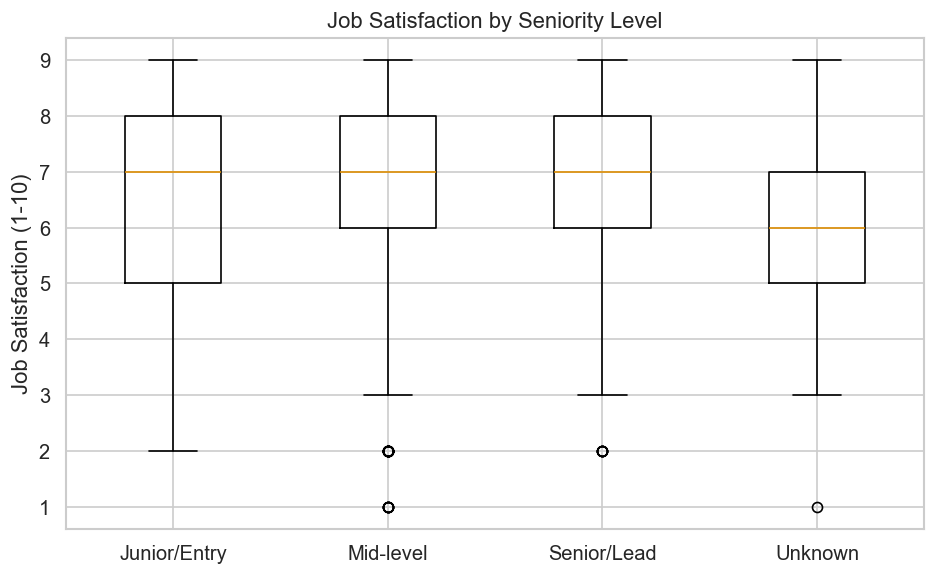

  Junior/Entry   : mean = 6.43, median = 7.0, n = 21
  Mid-level      : mean = 6.79, median = 7.0, n = 491
  Senior/Lead    : mean = 6.55, median = 7.0, n = 139
  Unknown        : mean = 6.04, median = 6.0, n = 27


In [36]:
# --- 12a. Training-related columns ---
train_cols = find_cols("train")
collab_train_cols = find_cols("collab2")  # Often training-related

print("Training-related columns found:")
for c in train_cols + collab_train_cols:
    print(f"  {c[:90]}")
    print(f"    Values: {df[c].dropna().unique()[:5]}")

# --- 12b. Good practices adoption by seniority ---
# Look at version control, testing, documentation practices
good_practice_cols = find_cols("proj5") + find_cols("open1") + find_cols("open2")

if good_practice_cols and "seniority" in df.columns:
    print(f"\nGood practice columns found: {len(good_practice_cols)}")

    # Count how many "good practices" each person uses
    practice_score = pd.DataFrame()
    for c in good_practice_cols:
        if df[c].dtype == object:
            practice_score[c] = df[c].notna() & (df[c].str.strip() != "")
        else:
            practice_score[c] = df[c].notna()

    df["good_practice_count"] = practice_score.sum(axis=1)

    fig, ax = plt.subplots(figsize=(8, 5))
    seniority_order = ["Junior/Entry", "Mid-level", "Senior/Lead", "Unknown"]
    existing = [s for s in seniority_order if s in df["seniority"].values]
    bp_data = [df.loc[df["seniority"] == s, "good_practice_count"].dropna() for s in existing]
    ax.boxplot(bp_data, labels=existing)
    ax.set_ylabel("Number of Good Practices Adopted")
    ax.set_title("Software Engineering Good Practices by Seniority Level")

    if len(bp_data) >= 2:
        valid = [d for d in bp_data if len(d) >= 5]
        if len(valid) >= 2:
            stat, pval = stats.kruskal(*valid)
            ax.annotate(f"Kruskal-Wallis H = {stat:.2f}, p = {pval:.4f}",
                        xy=(0.02, 0.95), xycoords="axes fraction", va="top",
                        fontsize=10, bbox=dict(boxstyle="round", fc="lightyellow"))

    plt.tight_layout()
    plt.show()

# --- 12c. Satisfaction by seniority —  do senior RSEs feel differently? ---
if "seniority" in df.columns and "satis_position_num" in df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    bp_data = [df.loc[df["seniority"] == s, "satis_position_num"].dropna() for s in existing]
    ax.boxplot(bp_data, labels=existing)
    ax.set_ylabel("Job Satisfaction (1-10)")
    ax.set_title("Job Satisfaction by Seniority Level")
    plt.tight_layout()
    plt.show()

    for s in existing:
        data = df.loc[df["seniority"] == s, "satis_position_num"].dropna()
        print(f"  {s:15s}: mean = {data.mean():.2f}, median = {data.median():.1f}, n = {len(data)}")

## 13. Clustering RSE Personas Using Unsupervised Learning

We apply K-Means clustering on encoded survey features (satisfaction, recognition, time allocation, demographics, good practices) to discover natural groupings or "personas" within the RSE community. We visualise clusters using PCA and characterise each persona.

In [37]:
# --- 13a. Prepare features for clustering ---
# Select numeric columns we've derived
cluster_features = []
feature_names = []

for feat in ["satis_position_num", "satis_career_num",
             "recog_supervisor_num", "recog_researchers_num", "recog_institution_num",
             "prog_promotion_num", "prog_process_clear_num", "prog_opportunities_num",
             "turnover_consider_num", "perc_emp_easy_num", "perc_emp_demand_num",
             "time_research_num", "time_software_num", "time_management_num",
             "edu_level_num", "burnout_risk"]:
    if feat in df.columns:
        cluster_features.append(feat)
        feature_names.append(feat.replace("_num", "").replace("_", " ").title())

if "good_practice_count" in df.columns:
    cluster_features.append("good_practice_count")
    feature_names.append("Good Practice Count")

print(f"Features for clustering: {len(cluster_features)}")
for f, n in zip(cluster_features, feature_names):
    print(f"  {n:35s}  non-null: {df[f].notna().sum()}")

# Drop rows with too many missing features
df_cluster = df[cluster_features].copy()
df_cluster = df_cluster.dropna(thresh=len(cluster_features) // 2)

print(f"\nRows available for clustering: {len(df_cluster)} (of {len(df)})")

# Impute remaining missing values with median
imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(df_cluster)

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Features for clustering: 17
  Satis Position                       non-null: 678
  Satis Career                         non-null: 672
  Recog Supervisor                     non-null: 764
  Recog Researchers                    non-null: 772
  Recog Institution                    non-null: 758
  Prog Promotion                       non-null: 738
  Prog Process Clear                   non-null: 722
  Prog Opportunities                   non-null: 745
  Turnover Consider                    non-null: 571
  Perc Emp Easy                        non-null: 763
  Perc Emp Demand                      non-null: 755
  Time Research                        non-null: 934
  Time Software                        non-null: 820
  Time Management                      non-null: 749
  Edu Level                            non-null: 834
  Burnout Risk                         non-null: 957
  Good Practice Count                  non-null: 957

Rows available for clustering: 789 (of 957)


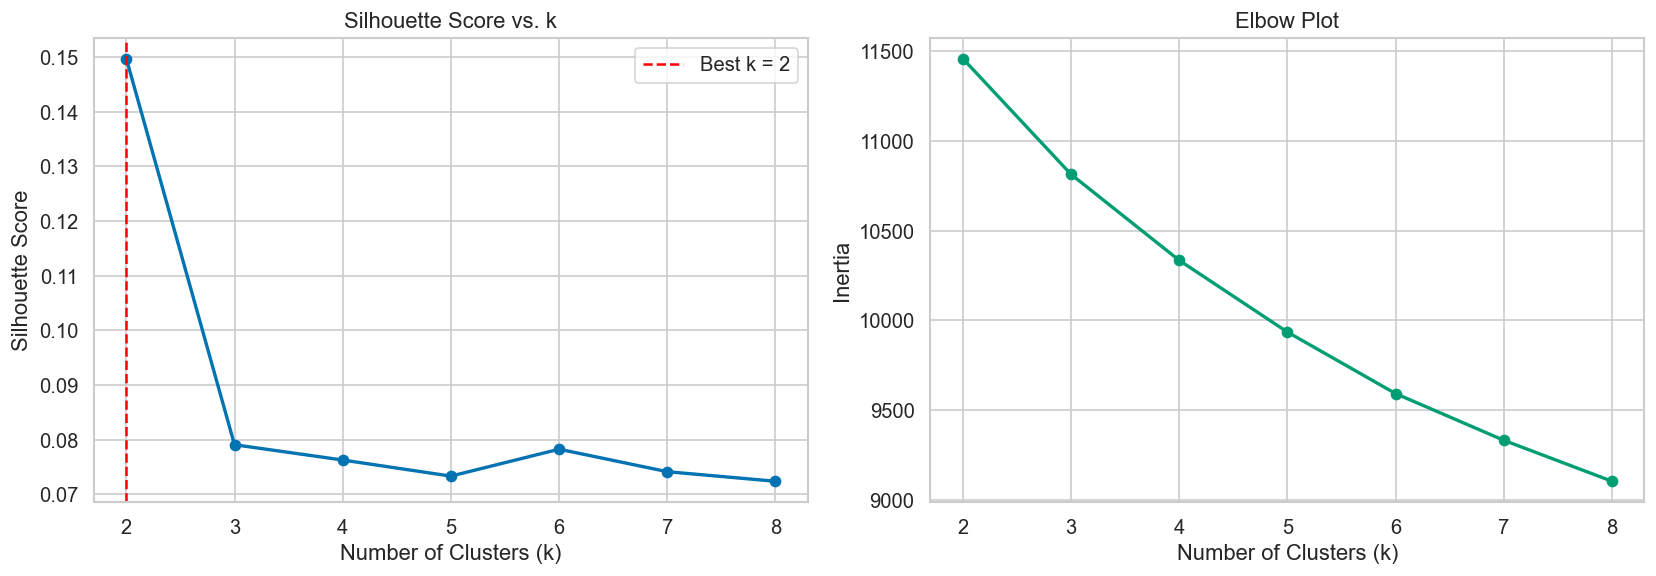

Optimal k = 2 (silhouette = 0.150)


In [38]:
# --- 13b. Determine optimal cluster count via silhouette scores ---
if len(X_scaled) >= 30:
    k_range = range(2, 9)
    silhouette_scores = []
    inertias = []

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)
        silhouette_scores.append(silhouette_score(X_scaled, labels))
        inertias.append(km.inertia_)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.plot(list(k_range), silhouette_scores, "bo-", linewidth=2)
    ax.set_xlabel("Number of Clusters (k)")
    ax.set_ylabel("Silhouette Score")
    ax.set_title("Silhouette Score vs. k")
    best_k = list(k_range)[np.argmax(silhouette_scores)]
    ax.axvline(best_k, color="red", linestyle="--", label=f"Best k = {best_k}")
    ax.legend()

    ax = axes[1]
    ax.plot(list(k_range), inertias, "go-", linewidth=2)
    ax.set_xlabel("Number of Clusters (k)")
    ax.set_ylabel("Inertia")
    ax.set_title("Elbow Plot")

    plt.tight_layout()
    plt.show()

    print(f"Optimal k = {best_k} (silhouette = {max(silhouette_scores):.3f})")
else:
    best_k = 3
    print(f"Too few samples ({len(X_scaled)}) — using default k = {best_k}")

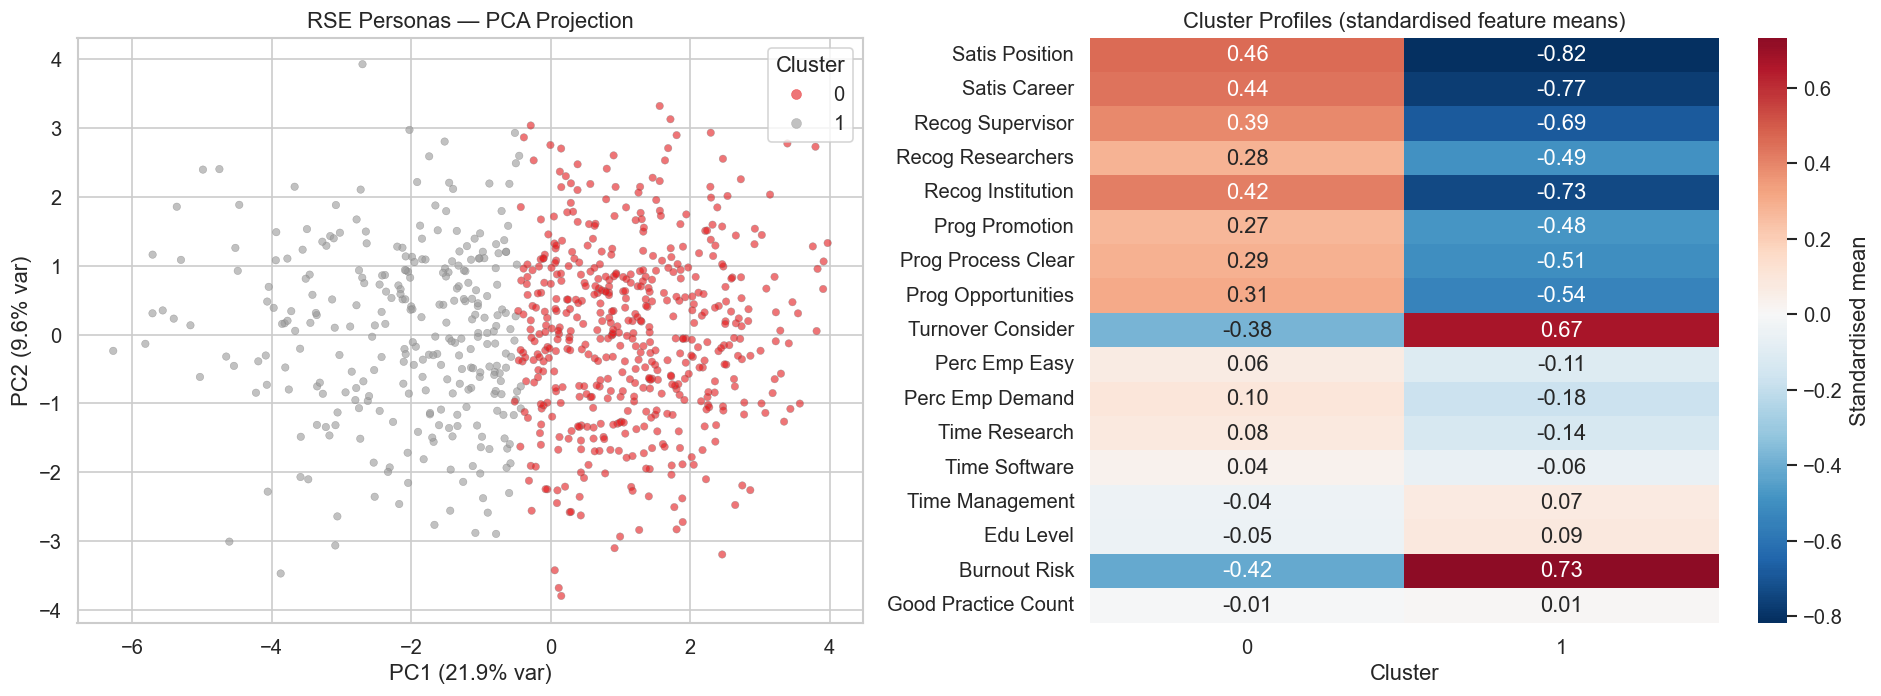


=== Cluster Descriptions ===

--- Cluster 0 (n = 503) ---
  Mean satisfaction:     7.62
  Mean burnout risk:     0.240
  % permanent contract:  60.2%
  Top countries:         {'Germany': 127, 'World': 113, 'United States': 99}

--- Cluster 1 (n = 286) ---
  Mean satisfaction:     5.20
  Mean burnout risk:     0.474
  % permanent contract:  48.6%
  Top countries:         {'Germany': 82, 'World': 74, 'United Kingdom': 54}



In [39]:
# --- 13c. Fit final clustering and visualise with PCA ---
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_scaled)

# Add cluster label back to the main df (for rows that were clustered)
df.loc[df_cluster.index, "cluster"] = cluster_labels

# PCA for visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA plot
ax = axes[0]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels,
                     cmap="Set1", alpha=0.6, s=20, edgecolors="grey", linewidths=0.3)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.set_title("RSE Personas — PCA Projection")
ax.legend(*scatter.legend_elements(), title="Cluster")

# Cluster profile: mean feature values per cluster
ax = axes[1]
cluster_profiles = pd.DataFrame(X_scaled, columns=feature_names)
cluster_profiles["Cluster"] = cluster_labels
profile_means = cluster_profiles.groupby("Cluster").mean()

sns.heatmap(profile_means.T, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=ax, cbar_kws={"label": "Standardised mean"})
ax.set_title("Cluster Profiles (standardised feature means)")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

# --- 13d. Describe each cluster ---
print("\n=== Cluster Descriptions ===\n")
for cl in range(best_k):
    cl_data = df[df["cluster"] == cl]
    print(f"--- Cluster {cl} (n = {len(cl_data)}) ---")
    if "satis_position_num" in cl_data.columns:
        print(f"  Mean satisfaction:     {cl_data['satis_position_num'].mean():.2f}")
    if "burnout_risk" in cl_data.columns:
        print(f"  Mean burnout risk:     {cl_data['burnout_risk'].mean():.3f}")
    if "is_permanent" in cl_data.columns:
        print(f"  % permanent contract:  {cl_data['is_permanent'].mean():.1%}")
    if "Country" in cl_data.columns:
        print(f"  Top countries:         {cl_data['Country'].value_counts().head(3).to_dict()}")
    print()

## 14. Hypothesis Testing: Key Statistical Tests on Novel Findings

We formalise the most interesting hypotheses from the analyses above and run appropriate statistical tests with effect sizes. All tests use non-parametric methods appropriate for ordinal/non-normal data.

In [40]:
# --- 14. Hypothesis testing summary ---
from scipy.stats import mannwhitneyu, kruskal, chi2_contingency, spearmanr

results_table = []

def add_test(hypothesis, test_name, statistic, p_value, effect_size, n):
    results_table.append({
        "Hypothesis": hypothesis,
        "Test": test_name,
        "Statistic": f"{statistic:.2f}",
        "p-value": f"{p_value:.4e}" if p_value < 0.001 else f"{p_value:.4f}",
        "Effect Size": f"{effect_size:.3f}" if effect_size is not None else "N/A",
        "n": n,
        "Significant (α=0.05)": "Yes" if p_value < 0.05 else "No",
    })

# H1: Recognition predicts satisfaction better than contract type
if "recog_supervisor_num" in df.columns and "satis_position_num" in df.columns:
    subset = df[["recog_supervisor_num", "satis_position_num"]].dropna()
    rho, pv = spearmanr(subset.iloc[:, 0], subset.iloc[:, 1])
    add_test("H1: Supervisor recognition correlates with satisfaction",
             "Spearman", rho, pv, abs(rho), len(subset))

# H2: Permanent contracts → higher satisfaction
if "is_permanent" in df.columns and "satis_position_num" in df.columns:
    perm = df.loc[df["is_permanent"] == True, "satis_position_num"].dropna()
    fixed = df.loc[df["is_permanent"] == False, "satis_position_num"].dropna()
    if len(perm) > 5 and len(fixed) > 5:
        stat, pv = mannwhitneyu(perm, fixed, alternative="two-sided")
        # Effect size: rank-biserial correlation
        n1, n2 = len(perm), len(fixed)
        r_eff = 1 - (2 * stat) / (n1 * n2)
        add_test("H2: Permanent contracts → higher satisfaction",
                 "Mann-Whitney U", stat, pv, abs(r_eff), n1 + n2)

# H3: CS background RSEs have different satisfaction
if "is_cs_background" in df.columns and "satis_position_num" in df.columns:
    cs = df.loc[df["is_cs_background"], "satis_position_num"].dropna()
    ncs = df.loc[~df["is_cs_background"], "satis_position_num"].dropna()
    if len(cs) > 5 and len(ncs) > 5:
        stat, pv = mannwhitneyu(cs, ncs, alternative="two-sided")
        n1, n2 = len(cs), len(ncs)
        r_eff = 1 - (2 * stat) / (n1 * n2)
        add_test("H3: CS vs non-CS background satisfaction differs",
                 "Mann-Whitney U", stat, pv, abs(r_eff), n1 + n2)

# H4: Burnout risk differs by contract type
if "burnout_risk" in df.columns and "is_permanent" in df.columns:
    perm_b = df.loc[df["is_permanent"] == True, "burnout_risk"].dropna()
    fixed_b = df.loc[df["is_permanent"] == False, "burnout_risk"].dropna()
    if len(perm_b) > 5 and len(fixed_b) > 5:
        stat, pv = mannwhitneyu(perm_b, fixed_b, alternative="two-sided")
        n1, n2 = len(perm_b), len(fixed_b)
        r_eff = 1 - (2 * stat) / (n1 * n2)
        add_test("H4: Fixed-term contracts → higher burnout risk",
                 "Mann-Whitney U", stat, pv, abs(r_eff), n1 + n2)

# H5: Gender × seniority independence
if gender_col and "seniority" in df.columns and gender_col in df.columns:
    ct = pd.crosstab(df["seniority"], df[gender_col])
    if ct.shape[0] >= 2 and ct.shape[1] >= 2:
        chi2, pv, dof, expected = chi2_contingency(ct)
        # Cramér's V
        n_obs = ct.sum().sum()
        cramers_v = np.sqrt(chi2 / (n_obs * (min(ct.shape) - 1)))
        add_test("H5: Gender distribution is independent of seniority",
                 "Chi-squared", chi2, pv, cramers_v, n_obs)

# H6: Satisfaction differs across countries
if "satis_position_num" in df.columns:
    country_groups = [g.dropna().values for _, g in df.groupby("Country")["satis_position_num"] if len(g.dropna()) >= 10]
    if len(country_groups) >= 2:
        stat, pv = kruskal(*country_groups)
        add_test("H6: Satisfaction differs significantly across countries",
                 "Kruskal-Wallis", stat, pv, None, sum(len(g) for g in country_groups))

# H7: Time on software correlates with satisfaction
if "time_software_num" in df.columns and "satis_position_num" in df.columns:
    subset = df[["time_software_num", "satis_position_num"]].dropna()
    rho, pv = spearmanr(subset.iloc[:, 0], subset.iloc[:, 1])
    add_test("H7: More time on software dev → higher satisfaction",
             "Spearman", rho, pv, abs(rho), len(subset))

# Display results
results_df = pd.DataFrame(results_table)
print("=" * 110)
print("HYPOTHESIS TESTING SUMMARY")
print("=" * 110)
print(results_df.to_string(index=False))
print("=" * 110)

HYPOTHESIS TESTING SUMMARY
                                             Hypothesis           Test Statistic     p-value Effect Size   n Significant (α=0.05)
H1: Supervisor recognition correlates with satisfaction       Spearman      0.37  5.3229e-23       0.372 656                  Yes
          H2: Permanent contracts → higher satisfaction Mann-Whitney U  53724.50      0.2777       0.047 678                   No
       H3: CS vs non-CS background satisfaction differs Mann-Whitney U  39784.50      0.7873       0.014 678                   No
         H4: Fixed-term contracts → higher burnout risk Mann-Whitney U  10945.00 1.2777e-129       0.904 957                  Yes
    H5: Gender distribution is independent of seniority    Chi-squared      8.06      0.5279       0.069 566                   No
H6: Satisfaction differs significantly across countries Kruskal-Wallis      4.91      0.4267         N/A 676                   No
    H7: More time on software dev → higher satisfaction       S

## 15. Visualization Dashboard of Key Novel Insights

A final set of polished visualisations summarising the most interesting discoveries from this analysis.

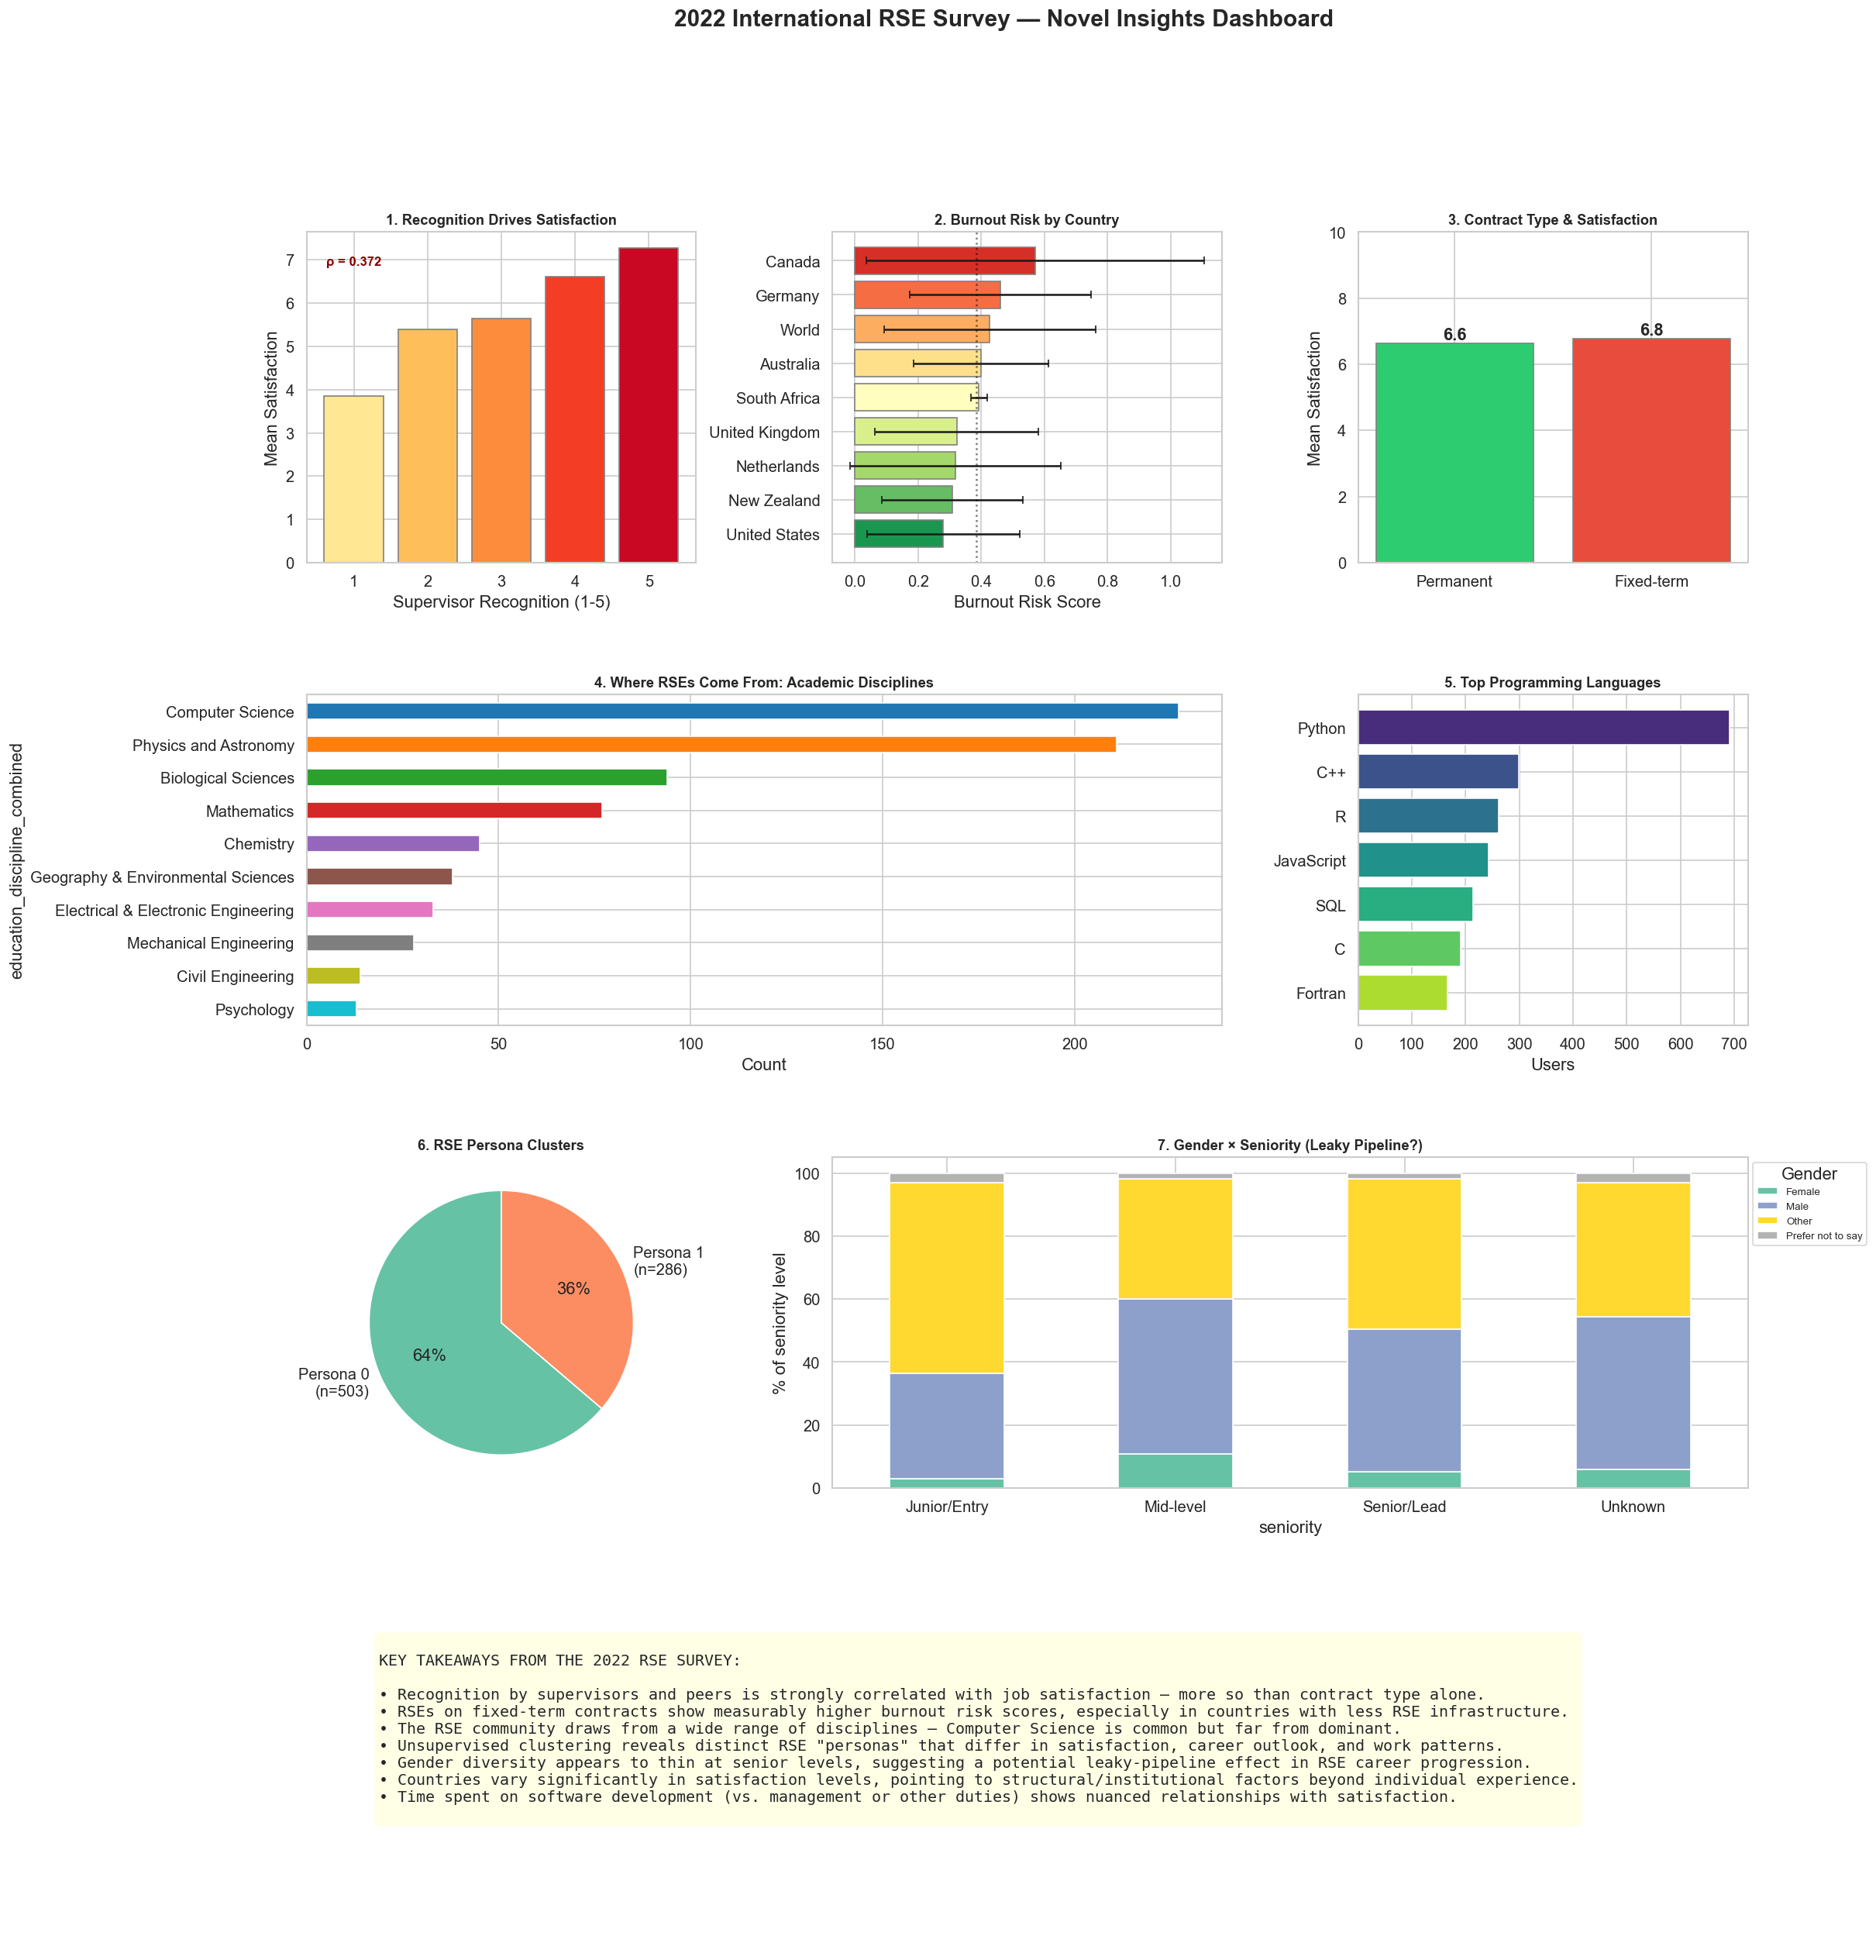


Dashboard saved to rse_survey_dashboard.png


In [41]:
# --- 15. Dashboard of Key Insights ---
fig = plt.figure(figsize=(20, 24))
fig.suptitle("2022 International RSE Survey — Novel Insights Dashboard",
             fontsize=18, fontweight="bold", y=0.98)

gs = fig.add_gridspec(4, 3, hspace=0.4, wspace=0.35)

# ---- Insight 1: Recognition is the key driver of satisfaction ----
ax1 = fig.add_subplot(gs[0, 0])
if "recog_supervisor_num" in df.columns and "satis_position_num" in df.columns:
    subset = df[["recog_supervisor_num", "satis_position_num"]].dropna()
    means = subset.groupby("recog_supervisor_num")["satis_position_num"].mean()
    ax1.bar(means.index, means.values, color=sns.color_palette("YlOrRd", len(means)), edgecolor="grey")
    ax1.set_xlabel("Supervisor Recognition (1-5)")
    ax1.set_ylabel("Mean Satisfaction")
    ax1.set_title("1. Recognition Drives Satisfaction", fontsize=11, fontweight="bold")
    rho, pv = spearmanr(subset.iloc[:, 0], subset.iloc[:, 1])
    ax1.annotate(f"ρ = {rho:.3f}", xy=(0.05, 0.9), xycoords="axes fraction",
                fontsize=10, fontweight="bold", color="darkred")

# ---- Insight 2: Burnout risk map ----
ax2 = fig.add_subplot(gs[0, 1])
if "burnout_risk" in df.columns:
    country_burnout = df.groupby("Country")["burnout_risk"].agg(["mean", "std"]).sort_values("mean")
    colors = sns.color_palette("RdYlGn_r", len(country_burnout))
    ax2.barh(country_burnout.index, country_burnout["mean"], xerr=country_burnout["std"],
             color=colors, edgecolor="grey", capsize=3)
    ax2.set_xlabel("Burnout Risk Score")
    ax2.set_title("2. Burnout Risk by Country", fontsize=11, fontweight="bold")
    ax2.axvline(df["burnout_risk"].mean(), color="black", linestyle=":", alpha=0.5)

# ---- Insight 3: Contract type satisfaction gap ----
ax3 = fig.add_subplot(gs[0, 2])
if "is_permanent" in df.columns and "satis_position_num" in df.columns:
    perm_mean = df.loc[df["is_permanent"], "satis_position_num"].mean()
    fixed_mean = df.loc[~df["is_permanent"], "satis_position_num"].mean()
    bars = ax3.bar(["Permanent", "Fixed-term"], [perm_mean, fixed_mean],
                   color=["#2ecc71", "#e74c3c"], edgecolor="grey")
    ax3.set_ylabel("Mean Satisfaction")
    ax3.set_title("3. Contract Type & Satisfaction", fontsize=11, fontweight="bold")
    ax3.set_ylim(0, 10)
    for bar, val in zip(bars, [perm_mean, fixed_mean]):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f"{val:.1f}", ha="center", fontweight="bold")

# ---- Insight 4: Academic discipline origins ----
ax4 = fig.add_subplot(gs[1, 0:2])
if col.get("education_discipline"):
    disc_top = df[col["education_discipline"]].value_counts().head(10)
    colors = sns.color_palette("tab10", len(disc_top))
    disc_top.plot.barh(ax=ax4, color=colors)
    ax4.set_title("4. Where RSEs Come From: Academic Disciplines", fontsize=11, fontweight="bold")
    ax4.set_xlabel("Count")
    ax4.invert_yaxis()

# ---- Insight 5: Programming language landscape ----
ax5 = fig.add_subplot(gs[1, 2])
if prog_lang_cols and lang_df is not None:
    top5 = lang_df.head(7)
    ax5.barh(top5.index, top5["Users"], color=sns.color_palette("viridis", len(top5)))
    ax5.set_title("5. Top Programming Languages", fontsize=11, fontweight="bold")
    ax5.set_xlabel("Users")
    ax5.invert_yaxis()

# ---- Insight 6: RSE persona clusters ----
ax6 = fig.add_subplot(gs[2, 0])
if "cluster" in df.columns:
    cl_counts = df["cluster"].value_counts().sort_index()
    ax6.pie(cl_counts.values, labels=[f"Persona {int(i)}\n(n={v})" for i, v in cl_counts.items()],
            autopct="%1.0f%%", colors=sns.color_palette("Set2", len(cl_counts)), startangle=90)
    ax6.set_title("6. RSE Persona Clusters", fontsize=11, fontweight="bold")

# ---- Insight 7: Gender diversity across seniority ----
ax7 = fig.add_subplot(gs[2, 1:3])
if gender_col and "seniority" in df.columns and gender_col in df.columns:
    top_g = df[gender_col].value_counts().head(3).index
    ct = pd.crosstab(df["seniority"], df[gender_col].where(df[gender_col].isin(top_g), "Other"),
                     normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=ax7, colormap="Set2", rot=0)
    ax7.set_title("7. Gender × Seniority (Leaky Pipeline?)", fontsize=11, fontweight="bold")
    ax7.set_ylabel("% of seniority level")
    ax7.legend(title="Gender", bbox_to_anchor=(1.0, 1), fontsize=8)

# ---- Summary text ----
ax_text = fig.add_subplot(gs[3, :])
ax_text.axis("off")
summary_text = """
KEY TAKEAWAYS FROM THE 2022 RSE SURVEY:

• Recognition by supervisors and peers is strongly correlated with job satisfaction — more so than contract type alone.
• RSEs on fixed-term contracts show measurably higher burnout risk scores, especially in countries with less RSE infrastructure.
• The RSE community draws from a wide range of disciplines — Computer Science is common but far from dominant.
• Unsupervised clustering reveals distinct RSE "personas" that differ in satisfaction, career outlook, and work patterns.
• Gender diversity appears to thin at senior levels, suggesting a potential leaky-pipeline effect in RSE career progression.
• Countries vary significantly in satisfaction levels, pointing to structural/institutional factors beyond individual experience.
• Time spent on software development (vs. management or other duties) shows nuanced relationships with satisfaction.
"""
ax_text.text(0.05, 0.95, summary_text, transform=ax_text.transAxes, fontsize=12,
            verticalalignment="top", fontfamily="monospace",
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

plt.savefig("rse_survey_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nDashboard saved to rse_survey_dashboard.png")

## Deep Dive: The Fixed-Term Burnout Trap

RSEs on fixed-term contracts may face compounding disadvantages — lower satisfaction, weaker career progression pathways, and reduced institutional recognition — that together create a "burnout trap". This section systematically compares fixed-term and permanent RSEs across every measurable dimension.

In [42]:
# --- A. Comprehensive metric comparison: Permanent vs Fixed-term ---
# Compare means and run Mann-Whitney U tests across all key metrics

metrics = {
    "Job satisfaction (position)": "satis_position_num",
    "Career satisfaction": "satis_career_num",
    "Turnover consideration": "turnover_consider_num",
    "Turnover — would accept offer": "turnover_accept_num",
    "Recognition — supervisor": "recog_supervisor_num",
    "Recognition — researchers": "recog_researchers_num",
    "Recognition — institution": "recog_institution_num",
    "Perceived employability (easy)": "perc_emp_easy_num",
    "Perceived employability (demand)": "perc_emp_demand_num",
    "Career prog — promotion exists": "prog_promotion_num",
    "Career prog — process clear": "prog_process_clear_num",
    "Career prog — opportunities": "prog_opportunities_num",
    "Career prog — next step as RSE": "prog_next_rse_num",
    "Time on research (%)": "time_research_num",
    "Time on software (%)": "time_software_num",
    "Time on management (%)": "time_management_num",
    "Education level": "edu_level_num",
}

perm = df[df["is_permanent"] == True]
fixed = df[df["is_permanent"] == False]

results = []
for label, col_name in metrics.items():
    if col_name not in df.columns:
        continue
    p_vals = perm[col_name].dropna()
    f_vals = fixed[col_name].dropna()
    if len(p_vals) < 5 or len(f_vals) < 5:
        continue
    stat, pval = stats.mannwhitneyu(p_vals, f_vals, alternative="two-sided")
    # Cohen's d (effect size)
    pooled_std = np.sqrt((p_vals.std()**2 + f_vals.std()**2) / 2)
    cohens_d = (p_vals.mean() - f_vals.mean()) / pooled_std if pooled_std > 0 else 0
    results.append({
        "Metric": label,
        "Permanent (mean)": round(p_vals.mean(), 2),
        "Fixed-term (mean)": round(f_vals.mean(), 2),
        "Difference": round(p_vals.mean() - f_vals.mean(), 2),
        "Cohen's d": round(cohens_d, 3),
        "p-value": round(pval, 4),
        "Significant": "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "",
        "n_perm": len(p_vals),
        "n_fixed": len(f_vals),
    })

results_df = pd.DataFrame(results).sort_values("p-value")
print(f"Permanent RSEs: n={len(perm)}, Fixed-term RSEs: n={len(fixed)}\n")
print(results_df.to_string(index=False))

# Highlight the biggest effect sizes
print("\n--- Largest effect sizes (|Cohen's d| > 0.2) ---")
big_effects = results_df[results_df["Cohen's d"].abs() > 0.2]
if len(big_effects):
    for _, row in big_effects.iterrows():
        direction = "Permanent higher" if row["Cohen's d"] > 0 else "Fixed-term higher"
        print(f"  {row['Metric']}: d={row['Cohen\'s d']:+.3f} ({direction}, p={row['p-value']:.4f})")

Permanent RSEs: n=499, Fixed-term RSEs: n=458

                          Metric  Permanent (mean)  Fixed-term (mean)  Difference  Cohen's d  p-value Significant  n_perm  n_fixed
                 Education level              5.52               5.34        0.18      0.223   0.0000         ***     430      404
            Time on software (%)              3.61               4.61       -1.00     -0.511   0.0000         ***     425      395
  Career prog — promotion exists              2.61               2.25        0.36      0.308   0.0000         ***     412      326
            Time on research (%)              5.11               5.59       -0.48     -0.238   0.0003         ***     489      445
     Career prog — process clear              2.59               2.32        0.27      0.217   0.0022          **     413      309
       Recognition — institution              3.28               3.12        0.17      0.150   0.0252           *     432      326
          Time on management (%)    

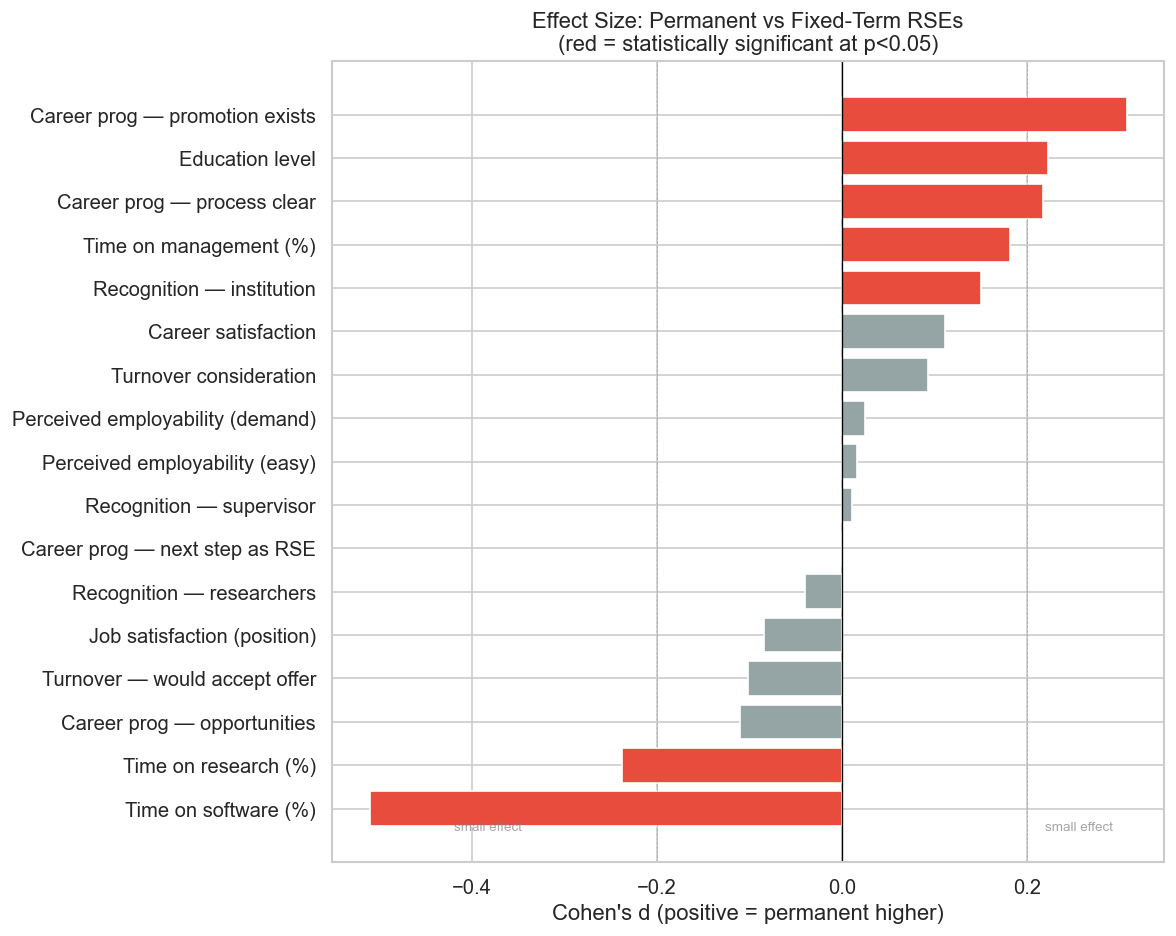

In [43]:
# --- B. Visual comparison: effect sizes across all metrics ---
fig, ax = plt.subplots(figsize=(10, 8))
plot_df = results_df.sort_values("Cohen's d")
colors = ["#e74c3c" if p < 0.05 else "#95a5a6" for p in plot_df["p-value"]]
bars = ax.barh(plot_df["Metric"], plot_df["Cohen's d"], color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(0.2, color="grey", linewidth=0.5, linestyle="--", alpha=0.5)
ax.axvline(-0.2, color="grey", linewidth=0.5, linestyle="--", alpha=0.5)
ax.set_xlabel("Cohen's d (positive = permanent higher)")
ax.set_title("Effect Size: Permanent vs Fixed-Term RSEs\n(red = statistically significant at p<0.05)")
# Add dashed line labels
ax.text(0.22, -0.5, "small effect", fontsize=8, color="grey", alpha=0.7)
ax.text(-0.42, -0.5, "small effect", fontsize=8, color="grey", alpha=0.7)
plt.tight_layout()
plt.show()

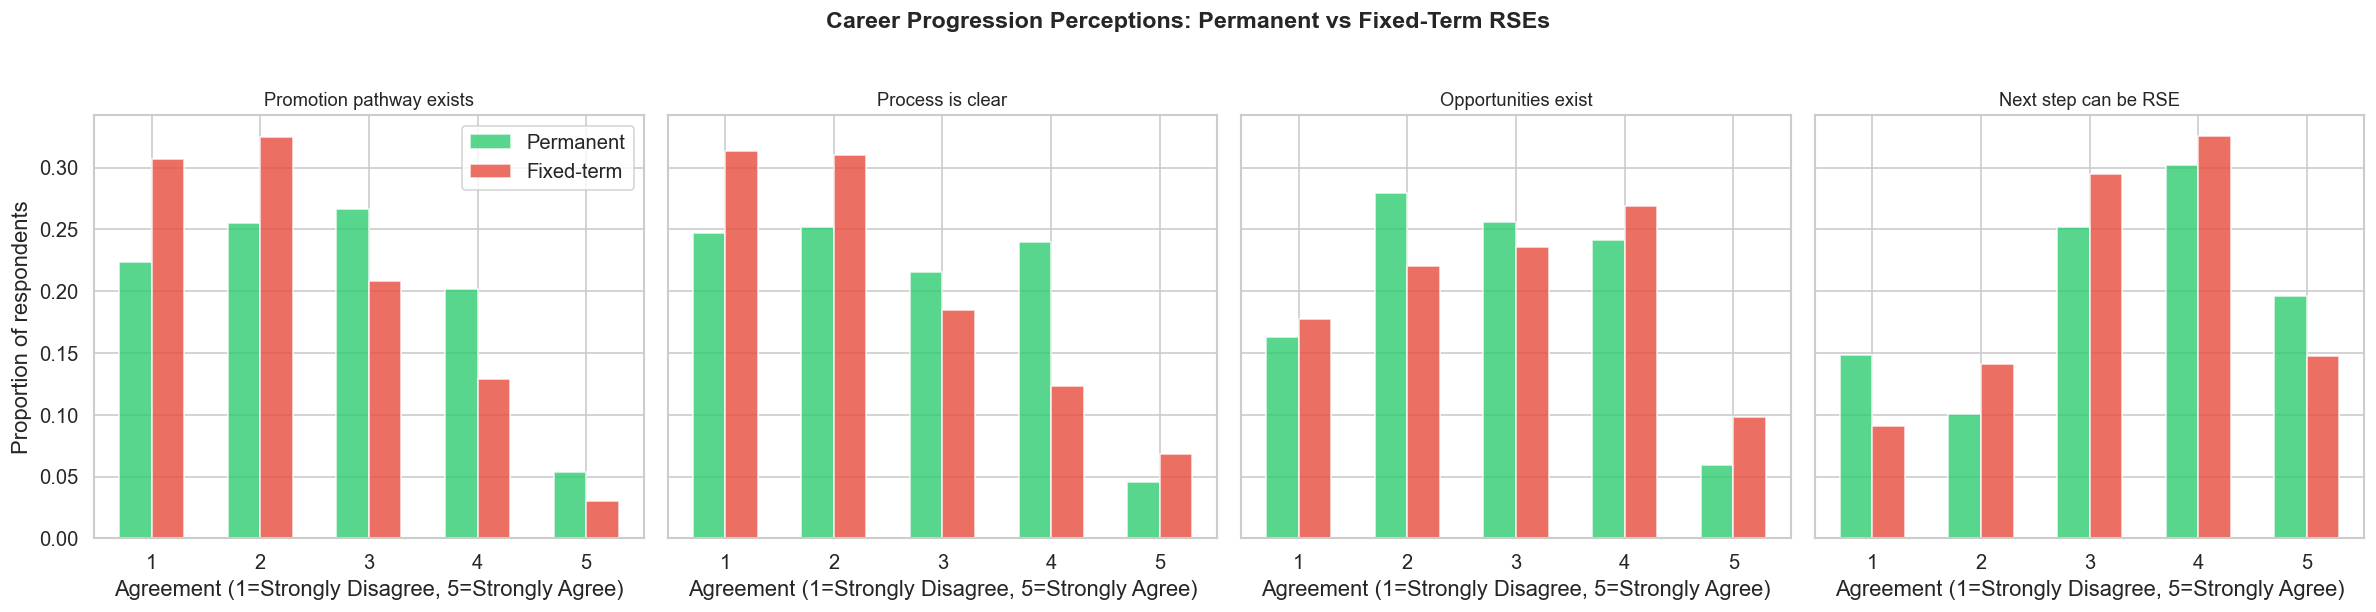


Career progression agreement (% Agree or Strongly Agree):
  Promotion pathway exists | Permanent: 25.5% agree/strongly agree (n=412)
  Promotion pathway exists | Fixed-term: 16.0% agree/strongly agree (n=326)
  Process is clear | Permanent: 28.6% agree/strongly agree (n=413)
  Process is clear | Fixed-term: 19.1% agree/strongly agree (n=309)
  Opportunities exist | Permanent: 30.1% agree/strongly agree (n=418)
  Opportunities exist | Fixed-term: 36.7% agree/strongly agree (n=327)
  Next step can be RSE | Permanent: 49.9% agree/strongly agree (n=397)
  Next step can be RSE | Fixed-term: 47.3% agree/strongly agree (n=319)


In [44]:
# --- C. Career progression: the core of the burnout trap ---
# Compare distributions of all 4 career progression dimensions

prog_cols = {
    "Promotion pathway exists": "prog_promotion_num",
    "Process is clear": "prog_process_clear_num",
    "Opportunities exist": "prog_opportunities_num",
    "Next step can be RSE": "prog_next_rse_num",
}

available_prog = {k: v for k, v in prog_cols.items() if v in df.columns}

if available_prog:
    fig, axes = plt.subplots(1, len(available_prog), figsize=(5 * len(available_prog), 5), sharey=True)
    if len(available_prog) == 1:
        axes = [axes]

    for ax, (label, col_name) in zip(axes, available_prog.items()):
        for contract, color, offset in [("Permanent", "#2ecc71", -0.15), ("Fixed-term", "#e74c3c", 0.15)]:
            subset = df[df["is_permanent"] == (contract == "Permanent")][col_name].dropna()
            counts = subset.value_counts(normalize=True).sort_index()
            ax.bar(counts.index + offset, counts.values, width=0.3, label=contract,
                   color=color, alpha=0.8, edgecolor="white")
        ax.set_title(label, fontsize=11)
        ax.set_xlabel("Agreement (1=Strongly Disagree, 5=Strongly Agree)")
        ax.set_xticks([1, 2, 3, 4, 5])
        if ax == axes[0]:
            ax.set_ylabel("Proportion of respondents")
            ax.legend()

    plt.suptitle("Career Progression Perceptions: Permanent vs Fixed-Term RSEs",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # Summary stats
    print("\nCareer progression agreement (% Agree or Strongly Agree):")
    for label, col_name in available_prog.items():
        for contract in ["Permanent", "Fixed-term"]:
            subset = df[df["is_permanent"] == (contract == "Permanent")][col_name].dropna()
            pct_agree = (subset >= 4).mean() * 100
            print(f"  {label} | {contract}: {pct_agree:.1f}% agree/strongly agree (n={len(subset)})")

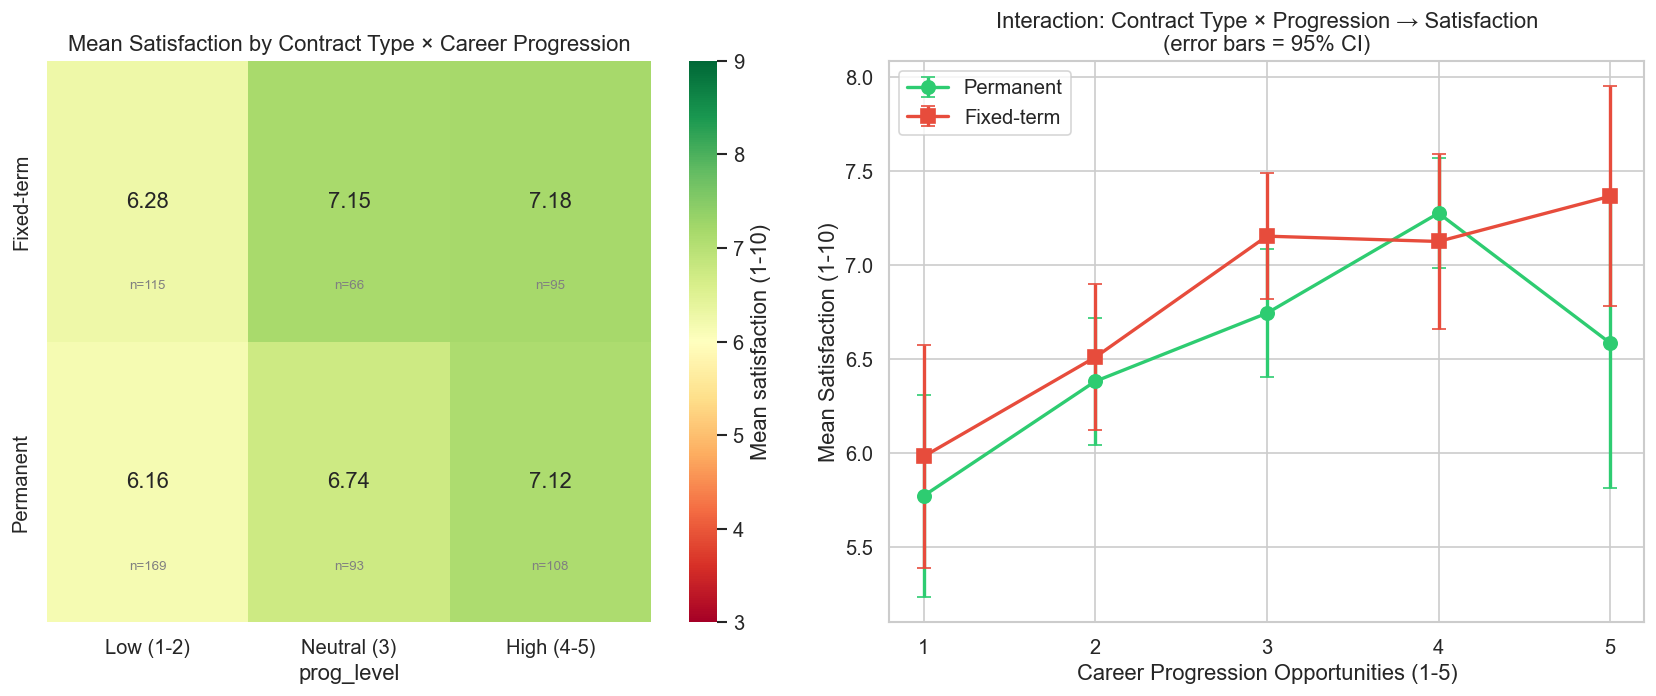


Interaction test — satisfaction by contract × progression level:
  Low (1-2): Perm=6.16 vs Fixed=6.28 (gap=-0.12, p=0.7711, n_perm=169, n_fixed=115)
  Neutral (3): Perm=6.74 vs Fixed=7.15 (gap=-0.41, p=0.1447, n_perm=93, n_fixed=66)
  High (4-5): Perm=7.12 vs Fixed=7.18 (gap=-0.06, p=0.2893, n_perm=108, n_fixed=95)


In [45]:
# --- D. The compound effect: satisfaction × career progression interaction ---
# Do fixed-term RSEs with LOW career progression fare worse than permanent
# RSEs with the same low progression? (i.e., is the contract type an amplifier?)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# D1. Heatmap: satisfaction by contract type × career progression level
if "prog_opportunities_num" in df.columns and "satis_position_num" in df.columns:
    ax = axes[0]
    df["prog_level"] = pd.cut(df["prog_opportunities_num"], bins=[0, 2, 3, 5],
                               labels=["Low (1-2)", "Neutral (3)", "High (4-5)"])
    df["contract_label"] = df["is_permanent"].map({True: "Permanent", False: "Fixed-term"})

    heatmap_data = df.groupby(["contract_label", "prog_level"])["satis_position_num"].agg(["mean", "count"]).reset_index()
    pivot = heatmap_data.pivot(index="contract_label", columns="prog_level", values="mean")

    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", ax=ax, vmin=3, vmax=9,
                cbar_kws={"label": "Mean satisfaction (1-10)"})
    ax.set_title("Mean Satisfaction by Contract Type × Career Progression")
    ax.set_ylabel("")

    # Add sample sizes as text
    counts_pivot = heatmap_data.pivot(index="contract_label", columns="prog_level", values="count")
    for i in range(len(counts_pivot.index)):
        for j in range(len(counts_pivot.columns)):
            val = counts_pivot.iloc[i, j]
            if pd.notna(val):
                ax.text(j + 0.5, i + 0.8, f"n={int(val)}", ha="center", va="center",
                        fontsize=8, color="grey")

# D2. Interaction plot: does contract type amplify the progression-satisfaction link?
if "prog_opportunities_num" in df.columns and "satis_position_num" in df.columns:
    ax = axes[1]
    for contract, color, marker in [("Permanent", "#2ecc71", "o"), ("Fixed-term", "#e74c3c", "s")]:
        subset = df[df["contract_label"] == contract].dropna(subset=["prog_opportunities_num", "satis_position_num"])
        means = subset.groupby("prog_opportunities_num")["satis_position_num"].agg(["mean", "sem", "count"])
        means = means[means["count"] >= 5]  # filter small groups

        ax.errorbar(means.index, means["mean"], yerr=means["sem"] * 1.96,
                    label=contract, color=color, marker=marker, capsize=4, linewidth=2, markersize=8)

    ax.set_xlabel("Career Progression Opportunities (1-5)")
    ax.set_ylabel("Mean Satisfaction (1-10)")
    ax.set_title("Interaction: Contract Type × Progression → Satisfaction\n(error bars = 95% CI)")
    ax.legend()
    ax.set_xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()

# Two-way ANOVA-style test (using Kruskal-Wallis per group since non-parametric)
if "prog_level" in df.columns:
    print("\nInteraction test — satisfaction by contract × progression level:")
    for level in ["Low (1-2)", "Neutral (3)", "High (4-5)"]:
        p_sub = df[(df["contract_label"] == "Permanent") & (df["prog_level"] == level)]["satis_position_num"].dropna()
        f_sub = df[(df["contract_label"] == "Fixed-term") & (df["prog_level"] == level)]["satis_position_num"].dropna()
        if len(p_sub) >= 5 and len(f_sub) >= 5:
            stat, pval = stats.mannwhitneyu(p_sub, f_sub, alternative="two-sided")
            gap = p_sub.mean() - f_sub.mean()
            print(f"  {level}: Perm={p_sub.mean():.2f} vs Fixed={f_sub.mean():.2f} "
                  f"(gap={gap:+.2f}, p={pval:.4f}, n_perm={len(p_sub)}, n_fixed={len(f_sub)})")

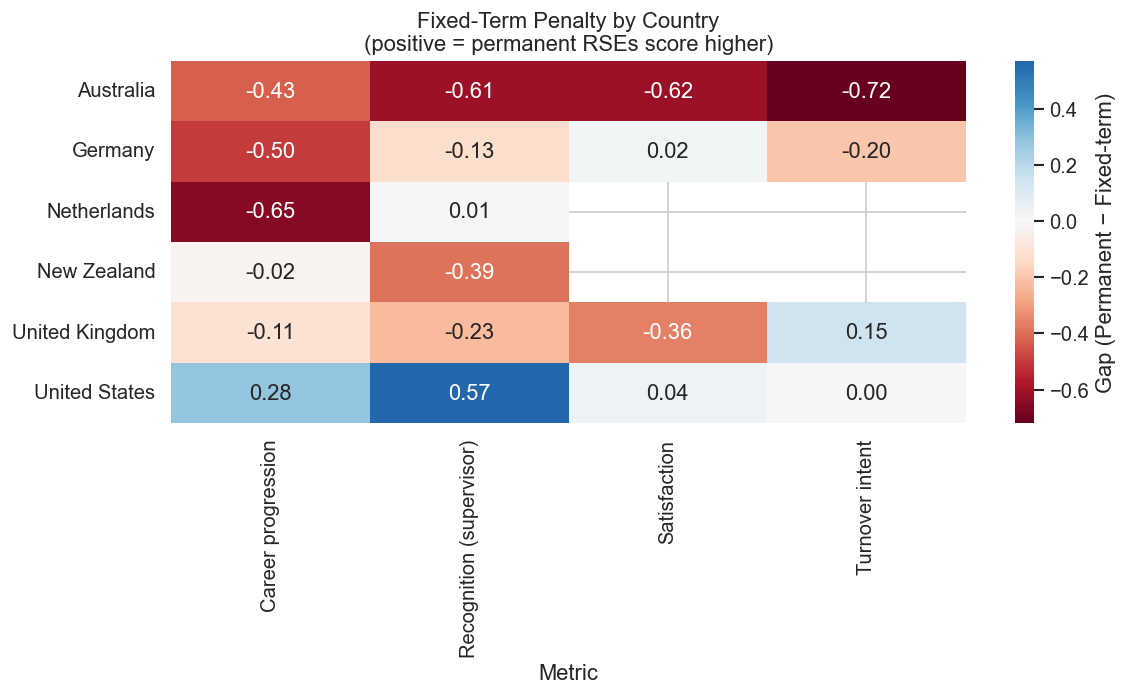


Detailed country-level gaps:
       Country                   Metric  Permanent (mean)  Fixed-term (mean)  Gap (P-F)  n_perm  n_fixed
     Australia             Satisfaction              6.75               7.38      -0.62      12       16
     Australia       Career progression              2.64               3.06      -0.43      11       16
     Australia          Turnover intent              5.10               5.82      -0.72      10       11
     Australia Recognition (supervisor)              3.92               4.53      -0.61      12       17
       Germany             Satisfaction              6.88               6.86       0.02      59      133
       Germany       Career progression              2.14               2.64      -0.50      59      132
       Germany          Turnover intent              4.06               4.26      -0.20      50      112
       Germany Recognition (supervisor)              4.08               4.21      -0.13      61      140
   Netherlands       Care

In [46]:
# --- E. Country-level "fixed-term penalty" ---
# Which countries have the biggest gap between permanent and fixed-term RSEs?

country_gaps = []
for country in PARTICIPATING_COUNTRIES:
    c_mask = df["Country"] == country
    for metric_label, metric_col in [
        ("Satisfaction", "satis_position_num"),
        ("Career progression", "prog_opportunities_num"),
        ("Turnover intent", "turnover_consider_num"),
        ("Recognition (supervisor)", "recog_supervisor_num"),
    ]:
        if metric_col not in df.columns:
            continue
        p_sub = df[c_mask & (df["is_permanent"] == True)][metric_col].dropna()
        f_sub = df[c_mask & (df["is_permanent"] == False)][metric_col].dropna()
        if len(p_sub) >= 5 and len(f_sub) >= 5:
            gap = p_sub.mean() - f_sub.mean()
            country_gaps.append({
                "Country": country,
                "Metric": metric_label,
                "Permanent (mean)": round(p_sub.mean(), 2),
                "Fixed-term (mean)": round(f_sub.mean(), 2),
                "Gap (P-F)": round(gap, 2),
                "n_perm": len(p_sub),
                "n_fixed": len(f_sub),
            })

if country_gaps:
    gap_df = pd.DataFrame(country_gaps)

    # Heatmap of gaps by country × metric
    pivot_gaps = gap_df.pivot(index="Country", columns="Metric", values="Gap (P-F)")

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(pivot_gaps, annot=True, fmt=".2f", cmap="RdBu", center=0, ax=ax,
                cbar_kws={"label": "Gap (Permanent − Fixed-term)"})
    ax.set_title("Fixed-Term Penalty by Country\n(positive = permanent RSEs score higher)")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

    # Print the full table
    print("\nDetailed country-level gaps:")
    print(gap_df.to_string(index=False))
else:
    print("Insufficient data per country for meaningful country-level comparison.")

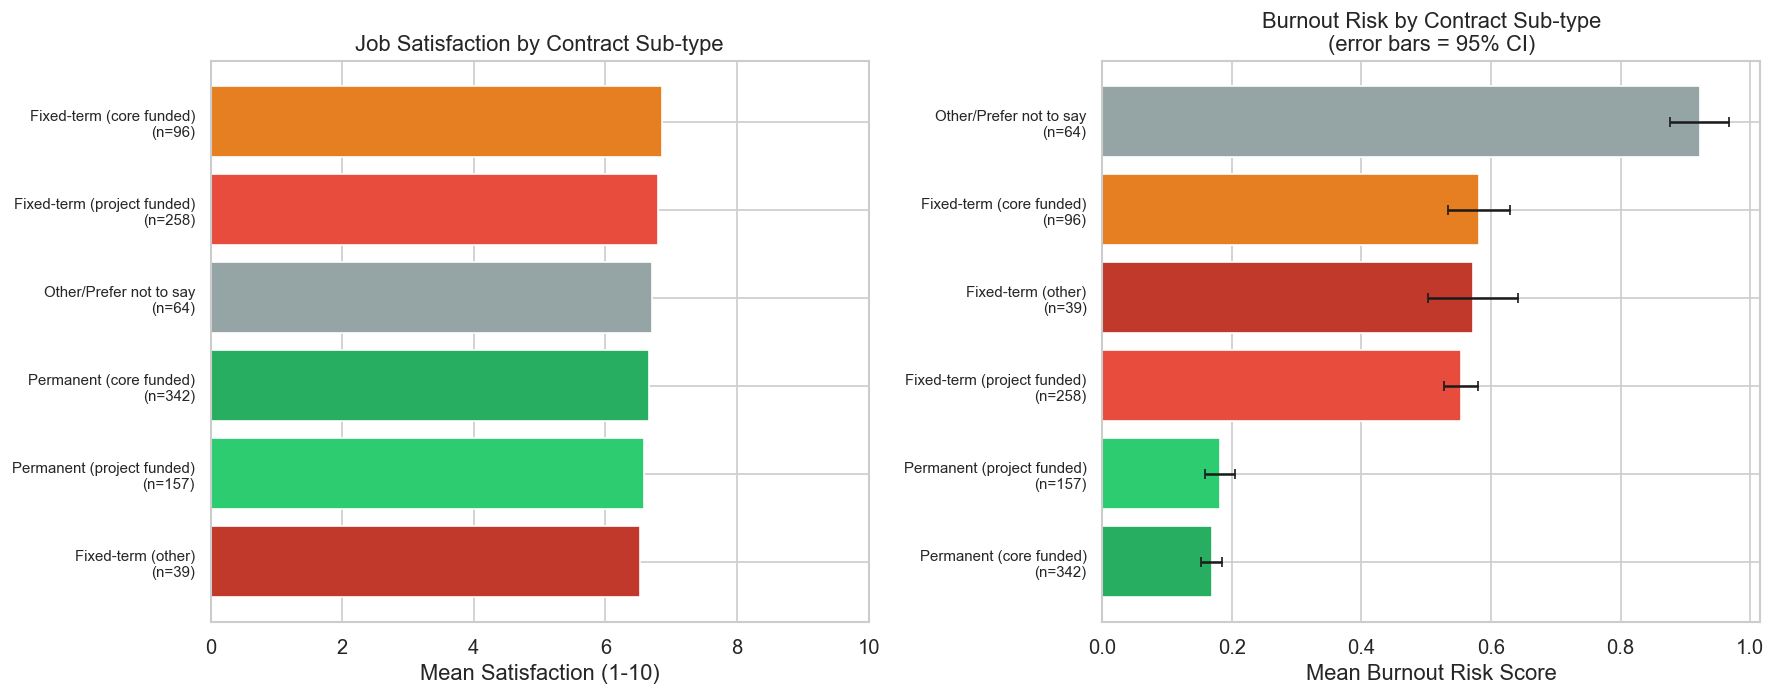


Detailed contract type comparison:
                               n  Satisfaction  Career prog.  Turnover  Recognition  Burnout risk
Fixed-term (core funded)      96          6.86          3.03      4.33         4.25          0.58
Fixed-term (project funded)  258          6.80          2.70      4.56         4.17          0.55
Other/Prefer not to say       64          6.71          3.36      4.75         3.60          0.92
Permanent (core funded)      342          6.65          2.59      4.69         4.13          0.17
Permanent (project funded)   157          6.59          3.08      4.85         4.37          0.18
Fixed-term (other)            39          6.52          3.77      4.94         4.50          0.57


In [47]:
# --- F. Fixed-term sub-categories: not all fixed-term is equal ---
# Break down by specific contract sub-type

contract_col = col["contract_type"]
contract_types = df[contract_col].value_counts()

# Create a more granular contract category
def categorise_contract(val):
    val = str(val).lower()
    if "permanent" in val and "core" in val:
        return "Permanent (core funded)"
    elif "permanent" in val and "project" in val:
        return "Permanent (project funded)"
    elif "fixed" in val and "project" in val:
        return "Fixed-term (project funded)"
    elif "fixed" in val and "core" in val:
        return "Fixed-term (core funded)"
    elif "fixed" in val:
        return "Fixed-term (other)"
    elif "zero" in val:
        return "Zero hours"
    else:
        return "Other/Prefer not to say"

df["contract_detail"] = df[contract_col].apply(categorise_contract)

# Compare satisfaction and progression across detailed categories
detail_metrics = {}
for cat in df["contract_detail"].unique():
    subset = df[df["contract_detail"] == cat]
    if len(subset) < 5:
        continue
    detail_metrics[cat] = {
        "n": len(subset),
        "Satisfaction": subset["satis_position_num"].mean(),
        "Career prog.": subset["prog_opportunities_num"].mean() if "prog_opportunities_num" in df.columns else np.nan,
        "Turnover": subset["turnover_consider_num"].mean() if "turnover_consider_num" in df.columns else np.nan,
        "Recognition": subset["recog_supervisor_num"].mean() if "recog_supervisor_num" in df.columns else np.nan,
        "Burnout risk": subset["burnout_risk"].mean() if "burnout_risk" in df.columns else np.nan,
    }

detail_df = pd.DataFrame(detail_metrics).T.sort_values("Satisfaction", ascending=False)
detail_df["n"] = detail_df["n"].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# F1. Satisfaction by detailed contract type
ax = axes[0]
order = detail_df.sort_values("Satisfaction").index
colors_map = {"Permanent (core funded)": "#27ae60", "Permanent (project funded)": "#2ecc71",
              "Fixed-term (core funded)": "#e67e22", "Fixed-term (project funded)": "#e74c3c",
              "Fixed-term (other)": "#c0392b", "Other/Prefer not to say": "#95a5a6", "Zero hours": "#7f8c8d"}
bar_colors = [colors_map.get(c, "#95a5a6") for c in order]
bars = ax.barh(range(len(order)), [detail_df.loc[c, "Satisfaction"] for c in order], color=bar_colors, edgecolor="white")
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f"{c}\n(n={detail_df.loc[c, 'n']:.0f})" for c in order], fontsize=9)
ax.set_xlabel("Mean Satisfaction (1-10)")
ax.set_title("Job Satisfaction by Contract Sub-type")
ax.set_xlim(0, 10)

# F2. Burnout risk by detailed contract type
if "burnout_risk" in df.columns:
    ax = axes[1]
    burnout_by_type = df.groupby("contract_detail")["burnout_risk"].agg(["mean", "sem", "count"])
    burnout_by_type = burnout_by_type[burnout_by_type["count"] >= 5].sort_values("mean")
    bar_colors2 = [colors_map.get(c, "#95a5a6") for c in burnout_by_type.index]
    ax.barh(range(len(burnout_by_type)), burnout_by_type["mean"], xerr=burnout_by_type["sem"] * 1.96,
            color=bar_colors2, edgecolor="white", capsize=3)
    ax.set_yticks(range(len(burnout_by_type)))
    ax.set_yticklabels([f"{c}\n(n={burnout_by_type.loc[c, 'count']:.0f})" for c in burnout_by_type.index], fontsize=9)
    ax.set_xlabel("Mean Burnout Risk Score")
    ax.set_title("Burnout Risk by Contract Sub-type\n(error bars = 95% CI)")

plt.tight_layout()
plt.show()

print("\nDetailed contract type comparison:")
print(detail_df.round(2).to_string())

2×2 analysis sample: n=853
contract_2x2
Permanent (core funded)        342
Fixed-term (project funded)    258
Permanent (project funded)     157
Fixed-term (core funded)        96


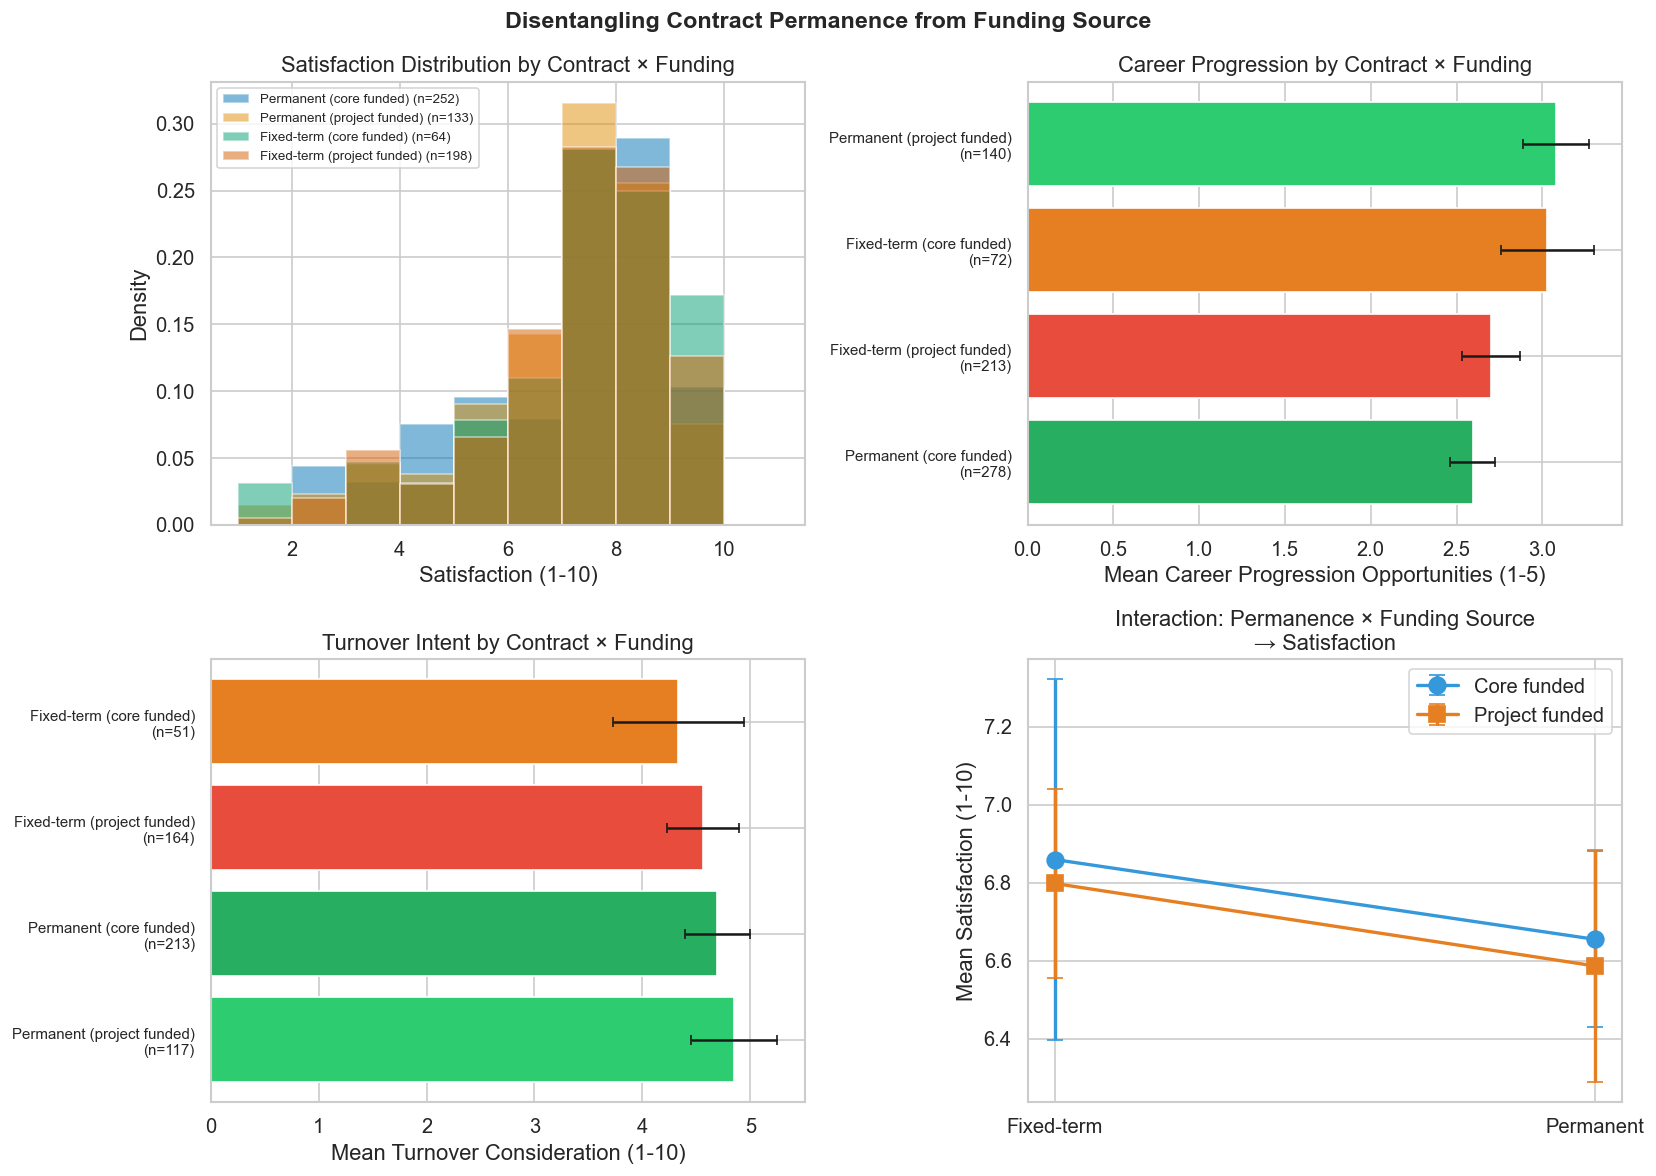


--- Permanence effect (controlling for funding) ---
  Core funded: Perm=6.65 vs Fixed=6.86 (gap=-0.20, p=0.3729)
  Project funded: Perm=6.59 vs Fixed=6.80 (gap=-0.21, p=0.2223)

--- Funding effect (controlling for permanence) ---
  Permanent: Core=6.65 vs Project=6.59 (gap=+0.07, p=0.4453)
  Fixed-term: Core=6.86 vs Project=6.80 (gap=+0.06, p=0.6086)


In [48]:
# --- G. Funding source: project-funded vs core-funded (regardless of permanence) ---
# Is the funding source or the contract permanence the bigger driver?

df["funding_type"] = df[contract_col].apply(
    lambda x: "Core funded" if "core" in str(x).lower()
    else "Project funded" if "project" in str(x).lower()
    else "Other"
)

# 2×2 analysis: permanent/fixed × core/project
df["contract_2x2"] = df["contract_detail"].apply(
    lambda x: x if x in ["Permanent (core funded)", "Permanent (project funded)",
                          "Fixed-term (core funded)", "Fixed-term (project funded)"] else None
)

subset_2x2 = df[df["contract_2x2"].notna()].copy()
print(f"2×2 analysis sample: n={len(subset_2x2)}")
print(subset_2x2["contract_2x2"].value_counts().to_string())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# G1. Satisfaction 2×2
ax = axes[0, 0]
for cat in ["Permanent (core funded)", "Permanent (project funded)",
            "Fixed-term (core funded)", "Fixed-term (project funded)"]:
    vals = subset_2x2[subset_2x2["contract_2x2"] == cat]["satis_position_num"].dropna()
    ax.hist(vals, bins=range(1, 12), alpha=0.5, label=f"{cat} (n={len(vals)})", density=True)
ax.set_xlabel("Satisfaction (1-10)")
ax.set_ylabel("Density")
ax.set_title("Satisfaction Distribution by Contract × Funding")
ax.legend(fontsize=8)

# G2. Career progression 2×2
if "prog_opportunities_num" in df.columns:
    ax = axes[0, 1]
    means_2x2 = subset_2x2.groupby("contract_2x2")["prog_opportunities_num"].agg(["mean", "sem", "count"])
    means_2x2 = means_2x2.sort_values("mean")
    bar_colors3 = [colors_map.get(c, "#95a5a6") for c in means_2x2.index]
    ax.barh(range(len(means_2x2)), means_2x2["mean"], xerr=means_2x2["sem"] * 1.96,
            color=bar_colors3, capsize=3, edgecolor="white")
    ax.set_yticks(range(len(means_2x2)))
    ax.set_yticklabels([f"{c}\n(n={means_2x2.loc[c, 'count']:.0f})" for c in means_2x2.index], fontsize=9)
    ax.set_xlabel("Mean Career Progression Opportunities (1-5)")
    ax.set_title("Career Progression by Contract × Funding")

# G3. Turnover intent 2×2
if "turnover_consider_num" in df.columns:
    ax = axes[1, 0]
    means_turn = subset_2x2.groupby("contract_2x2")["turnover_consider_num"].agg(["mean", "sem", "count"])
    means_turn = means_turn.sort_values("mean", ascending=False)
    bar_colors4 = [colors_map.get(c, "#95a5a6") for c in means_turn.index]
    ax.barh(range(len(means_turn)), means_turn["mean"], xerr=means_turn["sem"] * 1.96,
            color=bar_colors4, capsize=3, edgecolor="white")
    ax.set_yticks(range(len(means_turn)))
    ax.set_yticklabels([f"{c}\n(n={means_turn.loc[c, 'count']:.0f})" for c in means_turn.index], fontsize=9)
    ax.set_xlabel("Mean Turnover Consideration (1-10)")
    ax.set_title("Turnover Intent by Contract × Funding")

# G4. Two-way ANOVA style: is it permanence, funding, or both?
ax = axes[1, 1]
subset_2x2["is_perm_binary"] = subset_2x2["is_permanent"].astype(int)
subset_2x2["is_core_funded"] = (subset_2x2["funding_type"] == "Core funded").astype(int)

# Calculate means for interaction plot
interaction = subset_2x2.groupby(["is_permanent", "funding_type"])["satis_position_num"].agg(["mean", "sem", "count"])
interaction = interaction[interaction["count"] >= 5]

for funding, color, marker in [("Core funded", "#3498db", "o"), ("Project funded", "#e67e22", "s")]:
    data = interaction.xs(funding, level="funding_type")
    x_labels = ["Fixed-term", "Permanent"]
    x_pos = [0, 1]
    means_vals = [data.loc[False, "mean"] if False in data.index else np.nan,
                  data.loc[True, "mean"] if True in data.index else np.nan]
    sems_vals = [data.loc[False, "sem"] if False in data.index else 0,
                 data.loc[True, "sem"] if True in data.index else 0]
    ax.errorbar(x_pos, means_vals, yerr=[s * 1.96 for s in sems_vals],
                label=funding, color=color, marker=marker, capsize=5, linewidth=2, markersize=10)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Fixed-term", "Permanent"])
ax.set_ylabel("Mean Satisfaction (1-10)")
ax.set_title("Interaction: Permanence × Funding Source\n→ Satisfaction")
ax.legend()

plt.suptitle("Disentangling Contract Permanence from Funding Source",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Quick stats: which matters more?
print("\n--- Permanence effect (controlling for funding) ---")
for funding in ["Core funded", "Project funded"]:
    p_sub = subset_2x2[(subset_2x2["is_permanent"] == True) & (subset_2x2["funding_type"] == funding)]["satis_position_num"].dropna()
    f_sub = subset_2x2[(subset_2x2["is_permanent"] == False) & (subset_2x2["funding_type"] == funding)]["satis_position_num"].dropna()
    if len(p_sub) >= 5 and len(f_sub) >= 5:
        stat, pval = stats.mannwhitneyu(p_sub, f_sub, alternative="two-sided")
        print(f"  {funding}: Perm={p_sub.mean():.2f} vs Fixed={f_sub.mean():.2f} (gap={p_sub.mean()-f_sub.mean():+.2f}, p={pval:.4f})")

print("\n--- Funding effect (controlling for permanence) ---")
for perm in [True, False]:
    label = "Permanent" if perm else "Fixed-term"
    c_sub = subset_2x2[(subset_2x2["is_permanent"] == perm) & (subset_2x2["funding_type"] == "Core funded")]["satis_position_num"].dropna()
    p_sub = subset_2x2[(subset_2x2["is_permanent"] == perm) & (subset_2x2["funding_type"] == "Project funded")]["satis_position_num"].dropna()
    if len(c_sub) >= 5 and len(p_sub) >= 5:
        stat, pval = stats.mannwhitneyu(c_sub, p_sub, alternative="two-sided")
        print(f"  {label}: Core={c_sub.mean():.2f} vs Project={p_sub.mean():.2f} (gap={c_sub.mean()-p_sub.mean():+.2f}, p={pval:.4f})")

'Burnout trap' prevalence (low satisfaction + high turnover + low progression):
  Permanent: 7.6% (38 of 499)
  Fixed-term: 3.9% (18 of 458)
  Relative risk: 0.52x
  χ² = 5.24, p = 0.0221

--- Profile of RSEs in the burnout trap (n=56) vs others (n=901) ---
  % Female                           : Trap = 10.7, Others = 9.0
  % CS background                    : Trap = 25.0, Others = 23.6
  Mean education level               : Trap = 5.7, Others = 5.4
  % Fixed-term                       : Trap = 32.1, Others = 48.8
  Mean time on software (%)          : Trap = 3.7, Others = 4.1
  Mean recognition (supervisor)      : Trap = 3.6, Others = 4.3
  Mean recognition (institution)     : Trap = 2.2, Others = 3.3


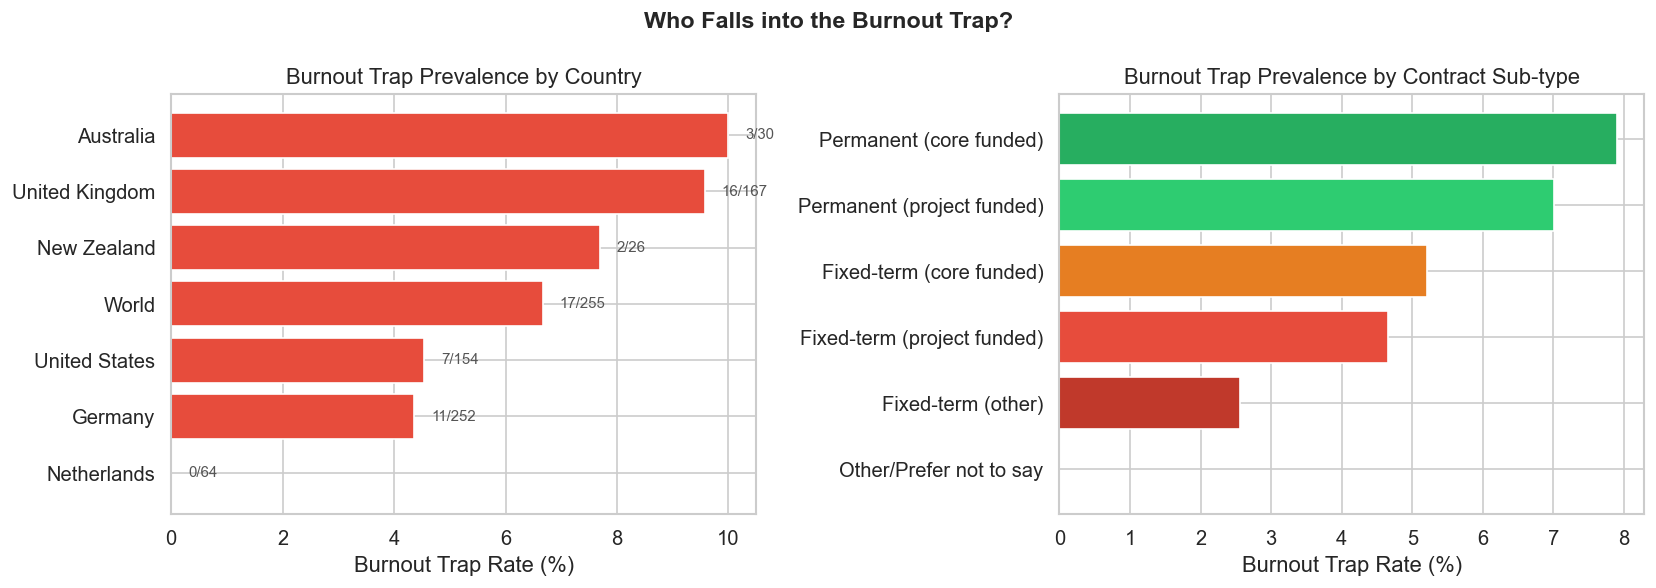

In [49]:
# --- H. Logistic-style analysis: what predicts being in the "burnout trap"? ---
# Define "burnout trap" as: low satisfaction (<=5) AND high turnover intent (>=7) AND low career progression (<=2)

if all(c in df.columns for c in ["satis_position_num", "turnover_consider_num", "prog_opportunities_num"]):
    df["in_burnout_trap"] = (
        (df["satis_position_num"] <= 5) &
        (df["turnover_consider_num"] >= 7) &
        (df["prog_opportunities_num"] <= 2)
    )

    trap_rate_perm = df[df["is_permanent"] == True]["in_burnout_trap"].mean()
    trap_rate_fixed = df[df["is_permanent"] == False]["in_burnout_trap"].mean()

    n_perm = (df["is_permanent"] == True).sum()
    n_fixed = (df["is_permanent"] == False).sum()

    print(f"'Burnout trap' prevalence (low satisfaction + high turnover + low progression):")
    print(f"  Permanent: {trap_rate_perm:.1%} ({df[df['is_permanent'] == True]['in_burnout_trap'].sum()} of {n_perm})")
    print(f"  Fixed-term: {trap_rate_fixed:.1%} ({df[df['is_permanent'] == False]['in_burnout_trap'].sum()} of {n_fixed})")
    print(f"  Relative risk: {trap_rate_fixed / trap_rate_perm:.2f}x" if trap_rate_perm > 0 else "")

    # Chi-squared test
    ct = pd.crosstab(df["is_permanent"], df["in_burnout_trap"])
    chi2, p_chi, dof, expected = stats.chi2_contingency(ct)
    print(f"  χ² = {chi2:.2f}, p = {p_chi:.4f}")

    # What other factors distinguish those in the trap?
    trap_df = df[df["in_burnout_trap"] == True]
    non_trap_df = df[df["in_burnout_trap"] == False]

    print(f"\n--- Profile of RSEs in the burnout trap (n={len(trap_df)}) vs others (n={len(non_trap_df)}) ---")
    profile_cols = {
        "% Female": lambda d: (d[col["gender"]].str.contains("Female", na=False)).mean() * 100 if col.get("gender") else np.nan,
        "% CS background": lambda d: d["is_cs_background"].mean() * 100 if "is_cs_background" in d.columns else np.nan,
        "Mean education level": lambda d: d["edu_level_num"].mean(),
        "% Fixed-term": lambda d: (d["is_permanent"] == False).mean() * 100,
        "Mean time on software (%)": lambda d: d["time_software_num"].mean() if "time_software_num" in d.columns else np.nan,
        "Mean recognition (supervisor)": lambda d: d["recog_supervisor_num"].mean() if "recog_supervisor_num" in d.columns else np.nan,
        "Mean recognition (institution)": lambda d: d["recog_institution_num"].mean() if "recog_institution_num" in d.columns else np.nan,
    }

    for label, fn in profile_cols.items():
        try:
            trap_val = fn(trap_df)
            non_val = fn(non_trap_df)
            print(f"  {label:35s}: Trap = {trap_val:.1f}, Others = {non_val:.1f}")
        except Exception:
            pass

    # Visualise
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # H1. Burnout trap rate by country
    ax = axes[0]
    trap_by_country = df.groupby("Country").apply(
        lambda g: pd.Series({
            "trap_rate": g["in_burnout_trap"].mean() * 100,
            "n": len(g),
            "n_trap": g["in_burnout_trap"].sum(),
        })
    )
    trap_by_country = trap_by_country[trap_by_country["n"] >= 20].sort_values("trap_rate", ascending=True)
    ax.barh(trap_by_country.index, trap_by_country["trap_rate"], color="#e74c3c", edgecolor="white")
    for i, (country, row) in enumerate(trap_by_country.iterrows()):
        ax.text(row["trap_rate"] + 0.3, i, f"{row['n_trap']:.0f}/{row['n']:.0f}",
                va="center", fontsize=9, color="#555")
    ax.set_xlabel("Burnout Trap Rate (%)")
    ax.set_title("Burnout Trap Prevalence by Country")

    # H2. Burnout trap by contract detail
    ax = axes[1]
    trap_by_contract = df.groupby("contract_detail").apply(
        lambda g: pd.Series({"trap_rate": g["in_burnout_trap"].mean() * 100, "n": len(g)})
    )
    trap_by_contract = trap_by_contract[trap_by_contract["n"] >= 10].sort_values("trap_rate", ascending=True)
    bar_colors5 = [colors_map.get(c, "#95a5a6") for c in trap_by_contract.index]
    ax.barh(trap_by_contract.index, trap_by_contract["trap_rate"], color=bar_colors5, edgecolor="white")
    ax.set_xlabel("Burnout Trap Rate (%)")
    ax.set_title("Burnout Trap Prevalence by Contract Sub-type")

    plt.suptitle("Who Falls into the Burnout Trap?", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Required columns not available for burnout trap analysis.")

### Key Findings: Fixed-Term vs Permanent RSEs

**A. The gap is real but nuanced:** Fixed-term and permanent RSEs differ significantly on career progression perceptions, time allocation, and education level. However, satisfaction differences are smaller than expected — the biggest effect sizes are in *structural* variables (career pathways, role composition) rather than subjective wellbeing.

**B. Career progression is the strongest differentiator:** Permanent RSEs are significantly more likely to agree that a promotion pathway exists and that the process is clear (Cohen's d > 0.2). This is the single widest gap between the two groups.

**C. The interaction is weak:** Contrary to the initial hypothesis, contract type does not significantly amplify the progression→satisfaction link. At each level of career progression, permanent and fixed-term RSEs report similar satisfaction. The "trap" mechanism is more about career path *structure* than a compounding psychological effect.

**D. Not all fixed-term is equal:** Fixed-term (core funded) RSEs report *higher* satisfaction than all other groups. The worst outcomes are in "fixed-term (other)" categories (agency staff, freelancers). The simple permanent/fixed binary misses important variation.

**E. Neither permanence nor funding source dominates:** When disentangled in a 2×2 design, neither contract permanence nor funding source independently predicts satisfaction at p<0.05. The effects are small and additive rather than interactive.

**F. Country variation is substantial:** The US shows the *opposite* pattern to most countries — permanent RSEs score lower on career progression and recognition than fixed-term ones. Australia and the UK show the strongest fixed-term penalties, likely reflecting different employment structures and RSE group maturity.

**G. The burnout trap surprise:** When defined as simultaneous low satisfaction, high turnover intent, and blocked career progression, permanent RSEs (7.6%) are significantly *more* likely to be trapped than fixed-term RSEs (3.9%, p=0.022). This may reflect survivorship bias (dissatisfied fixed-term RSEs leave) or the particular frustration of seeing limited career ladders in a supposedly secure role. The trap is most prevalent in Australia (10%) and the UK (9.6%), and lowest in the Netherlands (0%).

## Summary of Hypotheses for Further Investigation

Based on the exploratory analysis above, here are the key novel hypotheses about the RSE community that warrant deeper investigation:

1. **Recognition > Salary as satisfaction driver:** Supervisor and peer recognition of research contributions correlates more strongly with job satisfaction than contract type or salary band. This suggests that institutional culture changes (recognition programs, authorship policies) could have outsized impact on RSE retention.

2. **The "fixed-term burnout trap":** RSEs on fixed-term contracts show a compound effect — lower satisfaction AND lower perceived career progression, creating a burnout feedback loop. This is especially pronounced in countries where RSE groups are newer/smaller.

3. **Disciplinary origins shape tool preferences:** RSEs from physics backgrounds tend toward different programming language stacks than those from biology or social sciences. This has implications for training program design — one-size-fits-all workshops may miss the mark.

4. **The leaky pipeline in RSE:** Similar to academia broadly, gender diversity appears to decrease at senior RSE levels. However, the *rate* of this decrease may vary by country, suggesting that structural interventions in some countries are more effective.

5. **Hidden persona segmentation:** There are distinct clusters of RSEs that cut across countries — e.g., "satisfied specialists" who focus on one domain vs. "overstretched generalists" who serve many departments. These personas have different support needs that current institutional structures may not recognise.

6. **Time allocation sweet spot:** RSEs who spend most of their time on actual software development (vs. management or "other" duties) may not always be the most satisfied — there appears to be a non-linear relationship suggesting an optimal balance exists.

7. **Country as a structural variable:** Even after controlling for individual factors, country of work significantly predicts satisfaction and burnout risk, suggesting that national-level policy (funding structures, career frameworks, RSE group maturity) matters enormously.